# **Smart Airport Passenger Assistance Multimodal Chatbot**


---

# **Step 0. Runtime preparation**



In [ ]:
%%capture install_log
%pip install -q \
    "numpy>=1.26" \
    "pandas>=2.2" \
    "pillow>=10" \
    "scikit-learn>=1.4" \
    "matplotlib>=3.8" \
    "seaborn>=0.13" \
    "transformers>=4.45" \
    "sentence-transformers>=3.0" \
    "faiss-cpu>=1.9" \
    "openai-whisper>=20231117" \
    "tiktoken>=0.7" \
    "gTTS>=2.5" \
    "librosa>=0.10.2" \
    "soundfile>=0.12" \
    "jiwer>=3.0" \
    "opencv-python-headless>=4.10" \
    "streamlit>=1.35" \
    "pyngrok>=7"

### **0.2 Confirm the installation succeeded**



In [ ]:

failures = [line for line in (install_log.stdout + install_log.stderr).splitlines()
            if line.startswith("ERROR:") and "dependency resolver" not in line]

# Stop the notebook if the installation actually failed
if failures:
    print("\n".join(failures))
    raise RuntimeError("Installation failed; see the errors above.")

# Confirm the installation succeeded
print("Installation completed.")

Installation completed.


### **0.3 Verify every version**



In [ ]:

import importlib
import importlib.metadata
import re

# Declare the minimum version of every dependency, with the reason each floor exists
MINIMUM_VERSIONS = {
    "numpy":                 ("1.26",   "array API used throughout"),
    "pandas":                ("2.2",    "DataFrame.groupby(group_keys=) behaviour"),
    "torch":                 ("2.2",    "torch.inference_mode and modern DataLoader"),
    "transformers":          ("4.45",   "CLIPModel and CLIPProcessor stable API"),
    "sentence_transformers": ("3.0",    "encode(normalize_embeddings=) argument"),
    "faiss":                 ("1.9",    "NumPy 2 compatible wheels"),
    "sklearn":               ("1.4",    "classification_report(zero_division=) argument"),
    "matplotlib":            ("3.8",    "current pyplot API"),
    "seaborn":               ("0.13",   "barplot(hue=, legend=False) used by the plots below"),
    "librosa":               ("0.10.2", "keyword-only feature.mfcc signature"),
    "jiwer":                 ("3.0",    "word error rate transforms, no __version__ attribute"),
    "PIL":                   ("10.0",   "ImageDraw.rounded_rectangle and textbbox"),
    "whisper":               ("0",      "speech to text, dated release numbering"),
    "gtts":                  ("2.5",    "voice dataset synthesis"),
}

# Map each import name onto the distribution name pip knows it by, where the two differ
IMPORT_TO_DISTRIBUTION = {
    "sklearn": "scikit-learn", "PIL": "pillow", "faiss": "faiss-cpu",
    "sentence_transformers": "sentence-transformers", "gtts": "gTTS", "whisper": "openai-whisper",
}


# Compare two dotted version strings numerically
def version_at_least(found: str, required: str) -> bool:
    # Convert a version string into a tuple of integers, ignoring suffixes such as +cu121
    def parts(value):
        cleaned = re.split(r"[^0-9.]", value)[0]
        return tuple(int(piece) for piece in cleaned.split(".") if piece.isdigit())
    # Pad the shorter tuple so the comparison is well defined
    found_parts, required_parts = parts(found), parts(required)
    length = max(len(found_parts), len(required_parts))
    found_parts += (0,) * (length - len(found_parts))
    required_parts += (0,) * (length - len(required_parts))
    return found_parts >= required_parts


# Find a package version by the most reliable route available
def resolve_version(module, import_name: str) -> str:
    # Prefer the installed distribution metadata, which is authoritative and always present
      ## Reading module.__version__ first would be wrong: several packages, jiwer among them,
      ## publish no __version__ attribute and would be misreported as missing
    try:
        return importlib.metadata.version(IMPORT_TO_DISTRIBUTION.get(import_name, import_name))
    except importlib.metadata.PackageNotFoundError:
        return getattr(module, "__version__", "unknown")


# Import every dependency and record the version that was actually resolved
environment_rows, failures = [], []
for module_name, (minimum, reason) in MINIMUM_VERSIONS.items():
    try:
        module = importlib.import_module(module_name)
        found = resolve_version(module, module_name)
        # A floor of "0" means the package only has to import, not report a version
        ok = minimum == "0" or (found != "unknown" and version_at_least(found, minimum))
        environment_rows.append((module_name, found, minimum, "OK" if ok else "TOO OLD", reason))
        if not ok:
            failures.append(f"{module_name} {found} is below the required {minimum} ({reason})")
    except Exception as error:
        # Catch ImportError and the ValueError raised by a NumPy ABI mismatch
        environment_rows.append((module_name, "NOT IMPORTABLE", minimum, "FAILED", reason))
        failures.append(f"{module_name} could not be imported: {type(error).__name__}: {error}")

# Print the resolved environment as a plain table, since pandas may itself be broken
print(f"{'package':24s} {'installed':22s} {'minimum':9s} {'status':9s} reason")
print("-" * 104)
for name, found, minimum, status, reason in environment_rows:
    print(f"{name:24s} {found:22s} {minimum:9s} {status:9s} {reason}")
print("-" * 104)

# Stop the notebook immediately if the environment cannot support it
if failures:
    raise RuntimeError(
        "The environment does not meet the declared requirements:\n  - " + "\n  - ".join(failures)
        + "\n\nRe-run the install cell, then use Runtime -> Restart session and run every cell again."
    )
print(f"Environment verified: {len(environment_rows)} packages meet their minimum versions.")

package                  installed              minimum   status    reason
--------------------------------------------------------------------------------------------------------
numpy                    2.0.2                  1.26      OK        array API used throughout
pandas                   2.2.3                  2.2       OK        DataFrame.groupby(group_keys=) behaviour
torch                    2.11.0+cu128           2.2       OK        torch.inference_mode and modern DataLoader
transformers             5.15.0                 4.45      OK        CLIPModel and CLIPProcessor stable API
sentence_transformers    5.7.0                  3.0       OK        encode(normalize_embeddings=) argument
faiss                    1.15.0                 1.9       OK        NumPy 2 compatible wheels
sklearn                  1.6.1                  1.4       OK        classification_report(zero_division=) argument
matplotlib               3.10.0                 3.8       OK        current pyplot 

### **0.4 Record the environment for reproducibility**



In [ ]:
# Import PyTorch here only to record the runtime's build; Section 1 uses it properly
import torch

# Write the exact resolved versions to a requirements file
with open("requirements.txt", "w", encoding="utf-8") as handle:
    # Record the PyTorch build separately, since the runtime provides it rather than pip
    handle.write(f"# torch=={torch.__version__}  (provided by the Colab runtime, do not pip install)\n")
    # Record every checked dependency at the version actually resolved
    for name, found, _minimum, _status, _reason in environment_rows:
        if found in ("unknown", "NOT IMPORTABLE"):
            continue
        handle.write(f"{IMPORT_TO_DISTRIBUTION.get(name, name)}=={found}\n")
    # Record the remaining packages, installed but never imported directly here
    for extra in ["streamlit", "pyngrok", "soundfile", "opencv-python-headless", "tiktoken"]:
        try:
            handle.write(f"{extra}=={importlib.metadata.version(extra)}\n")
        except importlib.metadata.PackageNotFoundError:
            handle.write(f"{extra}\n")

# Show the file that was written
print(open("requirements.txt", encoding="utf-8").read())

# torch==2.11.0+cu128  (provided by the Colab runtime, do not pip install)
numpy==2.0.2
pandas==2.2.3
torch==2.11.0+cu128
transformers==5.15.0
sentence-transformers==5.7.0
faiss-cpu==1.15.0
scikit-learn==1.6.1
matplotlib==3.10.0
seaborn==0.13.2
librosa==0.11.0
jiwer==4.0.0
pillow==11.3.0
openai-whisper==20250625
gTTS==2.5.4
streamlit==1.62.0
pyngrok==8.1.2
soundfile==0.14.0
opencv-python-headless==5.0.0.93
tiktoken==0.13.0



---

# **1. Environment Setup (10%)**



### **1.1 Import the libraries**

The libraries used are: FAISS is used for searching, CLIP and the sentence encoder is used to convert images and questions into similar numbers, Pillow is used for the signage dataset, and scikit-learn is used to evaluate. PyTorch is already installed in Colab.

In [ ]:
# Enable modern type hinting syntax on older Python versions
from __future__ import annotations

# Import tool to handle JSON data for the knowledge base
import json
# Import tool for operating system and file path interactions
import os
# Import tool for random number generation
import random
# Import tool for measuring execution time
import time
# Import specialised container for counting class occurrences
from collections import Counter
# Import tools to create structured, immutable data containers
from dataclasses import asdict, dataclass, field, replace
# Import tool for robust cross-platform file paths
from pathlib import Path
# Import tools for defining explicit data types in function signatures
from typing import Any, Dict, List, Optional, Sequence, Tuple

# Import tool for fast vector similarity search
import faiss
# Import tool for plotting distributions and confusion matrices
import matplotlib.pyplot as plt
# Import tool for numerical array operations
import numpy as np
# Import tool for tabular data handling and display
import pandas as pd
# Import tool for attractive statistical plots
import seaborn as sns

# Import the image handling library used to synthesise the visual dataset
from PIL import Image, ImageDraw, ImageFilter, ImageFont

# Import the main deep learning library and its batching utilities
import torch
import torch.utils.data

# Import tool to display rich objects such as DataFrames inside the notebook
from IPython.display import Audio, display
# Import the sentence embedding model wrapper
from sentence_transformers import SentenceTransformer
# Import evaluation metrics for the retrieval and intent components
from sklearn.metrics import (
    accuracy_score,        # Overall proportion of correct predictions
    classification_report, # Precision, recall and F1 per class
    confusion_matrix,      # Matrix of predicted versus true labels
)
# Import the CLIP model and its matching input processor
from transformers import CLIPModel, CLIPProcessor, set_seed

# Confirm the imports completed successfully
print("All libraries imported successfully.")

All libraries imported successfully.


### **1.2 Configuration and reproducibility**

All thresholds and model names are contained in the one settings file and can be changed and the system retested from the same location. There are two thresholds, as text scores are within a different range than image scores and one size would not work for both. All random number generators begin at the same number; therefore results can be reproduced.

In [ ]:
# Define an immutable settings container for the entire system
@dataclass(frozen=True)
class AirportConfig:
    # Vision-language model that embeds images and short texts into one shared space
    clip_model_name: str = "openai/clip-vit-base-patch32"

    # Sentence embedding model used for full natural-language passenger questions
    text_model_name: str = "sentence-transformers/all-MiniLM-L6-v2"

    # Size of the Whisper speech-to-text model ("tiny", "base", "small")
    speech_model_name: str = "base"

    # Number used to keep every random result reproducible
    seed: int = 42

    # Square pixel size that all images are resized to before encoding
    image_size: int = 224

    # Number of knowledge base records returned by a retrieval call
    top_k: int = 3

    # Minimum RAW cosine similarity below which the chatbot refuses to answer a text query
      ## Thresholds are per-modality because the two encoders produce different score ranges:
      ## sentence-transformer text-to-text similarity spreads widely, whereas CLIP image-to-text
      ## similarity is compressed into a narrow band. A single global threshold would be
      ## either far too strict for images or far too permissive for text.
    text_confidence_threshold: float = 0.35

    # Minimum raw cosine similarity below which the chatbot refuses to answer an image query
    image_confidence_threshold: float = 0.22

    # Relative contribution of the image evidence during multimodal fusion
    image_weight: float = 0.5

    # Relative contribution of the text evidence during multimodal fusion
    text_weight: float = 0.5

    # Sample rate that all audio is resampled to before transcription
    audio_sample_rate: int = 16000

    # Number of MFCC coefficients extracted for audio quality analysis
    n_mfcc: int = 13

    # Folder where the synthesised visual dataset is written
    dataset_root: str = "airport_dataset"

    # Folder where the synthesised voice dataset is written
    audio_root: str = "airport_audio"

    # File name of the structured airport knowledge base
    kb_path: str = "airport_kb.json"


# Create the single global configuration instance
CONFIG = AirportConfig()

# Seed every random number generator from the same value
random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)
torch.manual_seed(CONFIG.seed)
set_seed(CONFIG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG.seed)

# Determine whether the work is done on the GPU or the CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Convert that choice into the integer identifier expected by Transformers pipelines
PIPELINE_DEVICE = 0 if DEVICE.type == "cuda" else -1

# Display the configuration as a readable table for the report appendix
display(pd.Series(asdict(CONFIG), name="Value").to_frame())

,Value
clip_model_name,openai/clip-vit-base-patch32
text_model_name,sentence-transformers/all-MiniLM-L6-v2
speech_model_name,base
seed,42
image_size,224
top_k,3
text_confidence_threshold,0.35
image_confidence_threshold,0.22
image_weight,0.5
text_weight,0.5


### **1.3 Confirm the compute device**

The runtime was checked before loading a model, which confirmed that the NVIDIA Tesla T4 with 15.6GB.

In [ ]:
# Report the PyTorch build and whether it can see a GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"Execution device: {DEVICE}")

# Report the GPU model and memory when one is present
if torch.cuda.is_available():
    print(f"GPU device:      {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    # Warn clearly rather than letting the notebook run far slower without explanation
    print("\n[WARNING] No GPU detected. The notebook will still run correctly on CPU, but")
    print("Whisper transcription and CLIP encoding will be substantially slower.")
    print("Select Runtime -> Change runtime type -> T4 GPU and run the notebook again.")

PyTorch version: 2.11.0+cu128
CUDA available:  True
Execution device: cuda
GPU device:      Tesla T4
GPU memory:      15.6 GB


### **1.4 Fixed response templates**

The system never provides an answer of itself.The following two templates were established: (1)disclaimer on every answer: "Gate information is subject to change, the passenger is reminded; (2)refusal if the confidence is below the threshold.

In [ ]:
# Fixed response returned whenever the system is not confident enough to answer
UNCERTAIN_RESPONSE = (
    "I am not confident enough to answer that reliably. "
    "Please check the airport information screens or speak to a member of staff at the nearest "
    "information desk."
)

# Fixed reminder attached to any answer involving time-sensitive information
LIVE_DATA_DISCLAIMER = (
    "Gate, delay and opening-hour information can change at short notice. "
    "Always confirm against the live airport departure boards."
)

# Confirm that the response templates are available
print("Response templates defined.")

Response templates defined.


---

# **2. Data Acquisition & Exploration **



## **2.1 Visual data — synthetic airport signage**

Twenty-six categories take into account the entire trip for the passenger from the check-in to the arrival All signs are bilingual, and the color is from actual signs, and the pictogram is comprised of simple shapes and not from a stock library, so there is no copyright issue.

In [ ]:
# Define the visual appearance of every airport sign category
  ## Each entry stores the sign wording, the pictogram to draw, and a colour matching real signage convention
SIGN_CATALOGUE: Dict[str, Dict[str, Any]] = {
    # --- Departure process: official blue ---
    "departures":         {"text": "DEPARTURES", "text_de": "ABFLUG",      "glyph": "plane_up",     "background": (0, 82, 155)},
    "check_in":           {"text": "CHECK-IN", "text_de": "ABFERTIGUNG",        "glyph": "desk",         "background": (0, 82, 155)},
    "gate":               {"text": "GATE B12", "text_de": "FLUGSTEIG B12",        "glyph": "aeroplane",    "background": (0, 82, 155)},
    "lift":               {"text": "LIFTS", "text_de": "AUFZUG",           "glyph": "lift_arrows",  "background": (0, 82, 155)},

    # --- Control points: red ---
    "security":           {"text": "SECURITY", "text_de": "SICHERHEIT",        "glyph": "shield",       "background": (176, 32, 32)},
    "passport_control":   {"text": "PASSPORT CONTROL", "text_de": "PASSKONTROLLE","glyph": "passport",     "background": (176, 32, 32)},
    "customs":            {"text": "CUSTOMS", "text_de": "ZOLL",         "glyph": "magnifier",    "background": (176, 32, 32)},

    # --- Arrival process: amber ---
    "arrivals":           {"text": "ARRIVALS", "text_de": "ANKUNFT",        "glyph": "plane_down",   "background": (196, 145, 0)},
    "baggage_claim":      {"text": "BAGGAGE CLAIM", "text_de": "GEPÄCKAUSGABE",   "glyph": "suitcase",     "background": (196, 145, 0)},
    "left_luggage":       {"text": "LEFT LUGGAGE", "text_de": "GEPÄCKAUFBEWAHRUNG",    "glyph": "locker",       "background": (196, 145, 0)},
    "lost_and_found":     {"text": "LOST AND FOUND", "text_de": "FUNDBÜRO",  "glyph": "question",     "background": (196, 145, 0)},

    # --- Onward transport and exits: green ---
    "exit":               {"text": "EXIT", "text_de": "AUSGANG",            "glyph": "exit_door",    "background": (0, 120, 90)},
    "train_station":      {"text": "TRAINS", "text_de": "ZÜGE",          "glyph": "train",        "background": (0, 120, 90)},
    "bus_terminal":       {"text": "BUSES", "text_de": "BUSSE",           "glyph": "bus",          "background": (0, 120, 90)},
    "taxi":               {"text": "TAXIS", "text_de": "TAXI",           "glyph": "car",          "background": (0, 120, 90)},
    "car_rental":         {"text": "CAR RENTAL", "text_de": "MIETWAGEN",      "glyph": "car",          "background": (0, 120, 90)},

    # --- Passenger facilities: dark grey and accent colours ---
    "restroom":           {"text": "RESTROOMS", "text_de": "TOILETTEN",       "glyph": "person",       "background": (55, 55, 60)},
    "prayer_room":        {"text": "PRAYER ROOM", "text_de": "GEBETSRAUM",     "glyph": "arch",         "background": (55, 55, 60)},
    "information_desk":   {"text": "INFORMATION", "text_de": "INFORMATION",     "glyph": "info",         "background": (0, 82, 155)},
    "special_assistance": {"text": "ASSISTANCE", "text_de": "BETREUUNG",      "glyph": "wheelchair",   "background": (0, 82, 155)},
    "pharmacy_medical":   {"text": "PHARMACY", "text_de": "APOTHEKE",        "glyph": "cross",        "background": (0, 130, 70)},
    "atm_currency":       {"text": "ATM / EXCHANGE", "text_de": "GELDAUTOMAT",  "glyph": "banknote",     "background": (55, 55, 60)},

    # --- Retail and catering: warm tones ---
    "lounge":             {"text": "LOUNGE", "text_de": "LOUNGE",          "glyph": "armchair",     "background": (90, 60, 130)},
    "restaurant":         {"text": "RESTAURANT", "text_de": "RESTAURANT",      "glyph": "cutlery",      "background": (150, 90, 20)},
    "cafe":               {"text": "CAFE", "text_de": "CAFÉ",            "glyph": "cup",          "background": (150, 90, 20)},
    "shops":              {"text": "SHOPS", "text_de": "GESCHÄFTE",           "glyph": "shopping_bag", "background": (150, 90, 20)},
}

# Extract the ordered list of category names for later use
SIGN_CATEGORIES: List[str] = list(SIGN_CATALOGUE.keys())

# Report how many visual categories the dataset will contain
print(f"Visual categories defined: {len(SIGN_CATEGORIES)}")
# Show the categories grouped by their signage colour convention
colour_groups: Dict[Tuple[int, int, int], List[str]] = {}
for name, spec in SIGN_CATALOGUE.items():
    colour_groups.setdefault(spec["background"], []).append(name)
for colour, names in colour_groups.items():
    print(f"  RGB{colour}: {', '.join(names)}")

Visual categories defined: 26
  RGB(0, 82, 155): departures, check_in, gate, lift, information_desk, special_assistance
  RGB(176, 32, 32): security, passport_control, customs
  RGB(196, 145, 0): arrivals, baggage_claim, left_luggage, lost_and_found
  RGB(0, 120, 90): exit, train_station, bus_terminal, taxi, car_rental
  RGB(55, 55, 60): restroom, prayer_room, atm_currency
  RGB(0, 130, 70): pharmacy_medical
  RGB(90, 60, 130): lounge
  RGB(150, 90, 20): restaurant, cafe, shops


In [ ]:
# Define a helper that loads a bold font at the requested size
def load_font(size: int) -> ImageFont.FreeTypeFont:
    # List the font files that are normally present in a Colab runtime
    candidate_paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    ]
    # Use the first font file that actually exists on this machine
    for path in candidate_paths:
        if os.path.exists(path):
            return ImageFont.truetype(path, size)
    # Fall back to the bundled bitmap font if no TrueType font is available
    return ImageFont.load_default()


# Resolve the bicubic resampling constant across Pillow versions
RESAMPLE_BICUBIC = getattr(getattr(Image, "Resampling", Image), "BICUBIC")

# Placeholder read by glyphs that punch holes in the sign background colour
SIGN_CURRENT_BACKGROUND: Tuple[int, int, int] = (0, 82, 155)


# Define the helper that draws one pictogram using basic geometric shapes
def draw_glyph(draw: ImageDraw.ImageDraw, glyph: str, box: Tuple[int, int, int, int]) -> None:
    # Unpack the bounding box the pictogram must fit inside
    left, top, right, bottom = box
    # Compute the centre of that box and a convenient unit length
    cx, cy = (left + right) // 2, (top + bottom) // 2
    unit = max(4, (right - left) // 6)
    # Use white for every pictogram so it contrasts with the coloured background
    ink = (255, 255, 255)
    # Read the current sign colour, used by glyphs that cut holes out of themselves
    hole = SIGN_CURRENT_BACKGROUND

    # An aircraft in level flight, used for gates
    if glyph == "aeroplane":
        draw.polygon([(left, cy + unit), (right, cy - unit), (right - unit, cy + unit * 2)], fill=ink)
        draw.polygon([(cx - unit, cy + unit), (cx + unit, cy), (cx, cy + unit * 2)], fill=ink)

    # An aircraft climbing, used for departures
    elif glyph == "plane_up":
        draw.polygon([(left + unit, cy + unit * 2), (right - unit, cy - unit * 2), (right - unit * 2, cy + unit)], fill=ink)
        draw.rectangle([left + unit, bottom - unit, right - unit, bottom - unit + unit // 3], fill=ink)

    # An aircraft descending, used for arrivals
    elif glyph == "plane_down":
        draw.polygon([(left + unit, cy - unit * 2), (right - unit, cy + unit * 2), (right - unit * 2, cy - unit)], fill=ink)
        draw.rectangle([left + unit, bottom - unit, right - unit, bottom - unit + unit // 3], fill=ink)

    # A staffed counter, used for check-in
    elif glyph == "desk":
        draw.ellipse([cx - unit, top + unit, cx + unit, top + unit * 3], fill=ink)
        draw.rectangle([left + unit, cy, right - unit, cy + unit // 2], fill=ink)
        draw.rectangle([left + unit * 2, cy, left + unit * 2 + unit // 2, bottom - unit], fill=ink)
        draw.rectangle([right - unit * 2, cy, right - unit * 2 + unit // 2, bottom - unit], fill=ink)

    # A shield, used for security screening
    elif glyph == "shield":
        draw.polygon([(cx, top + unit), (right - unit, cy - unit), (cx, bottom - unit), (left + unit, cy - unit)], fill=ink)

    # An open passport, used for immigration control
    elif glyph == "passport":
        draw.rounded_rectangle([left + unit, top + unit, right - unit, bottom - unit], radius=unit // 3, fill=ink)
        draw.rectangle([cx - unit // 6, top + unit, cx + unit // 6, bottom - unit], fill=hole)
        draw.ellipse([left + unit * 2, cy - unit, left + unit * 3, cy], fill=hole)

    # A magnifying glass, used for customs inspection
    elif glyph == "magnifier":
        draw.ellipse([left + unit, top + unit, cx + unit, cy + unit], outline=ink, width=max(3, unit // 2))
        draw.line([(cx + unit // 2, cy + unit // 2), (right - unit, bottom - unit)], fill=ink, width=max(3, unit // 2))

    # A suitcase, used for baggage reclaim
    elif glyph == "suitcase":
        draw.rounded_rectangle([left + unit, cy - unit, right - unit, bottom - unit], radius=unit // 2, fill=ink)
        draw.rectangle([cx - unit, cy - unit * 2, cx + unit, cy - unit], outline=ink, width=max(2, unit // 3))

    # A bank of lockers, used for left luggage
    elif glyph == "locker":
        draw.rectangle([left + unit, top + unit, right - unit, bottom - unit], fill=ink)
        draw.line([(cx, top + unit), (cx, bottom - unit)], fill=hole, width=max(2, unit // 3))
        draw.line([(left + unit, cy), (right - unit, cy)], fill=hole, width=max(2, unit // 3))
        draw.ellipse([cx - unit // 2 - unit // 4, cy - unit, cx - unit // 2, cy - unit // 2], fill=hole)

    # A question mark, used for lost property
    elif glyph == "question":
        draw.arc([cx - unit * 3 // 2, top + unit, cx + unit * 3 // 2, cy], 180, 20, fill=ink, width=max(4, unit // 2))
        draw.line([(cx, cy - unit // 2), (cx, bottom - unit * 2)], fill=ink, width=max(4, unit // 2))
        draw.ellipse([cx - unit // 3, bottom - unit - unit // 3, cx + unit // 3, bottom - unit + unit // 3], fill=ink)

    # A standing figure, used for restrooms
    elif glyph == "person":
        draw.ellipse([cx - unit, top + unit, cx + unit, top + unit * 3], fill=ink)
        draw.polygon([(cx - unit * 2, bottom - unit), (cx, cy - unit), (cx + unit * 2, bottom - unit)], fill=ink)

    # An arch, used for the multi-faith prayer room
    elif glyph == "arch":
        draw.pieslice([cx - unit * 2, cy - unit * 2, cx + unit * 2, cy + unit * 2], 180, 360, fill=ink)
        draw.rectangle([cx - unit * 2, cy, cx + unit * 2, bottom - unit], fill=ink)

    # An armchair, used for lounges
    elif glyph == "armchair":
        draw.rounded_rectangle([left + unit, cy - unit, right - unit, bottom - unit], radius=unit, fill=ink)
        draw.rectangle([left + unit, cy - unit * 2, left + unit * 2, cy + unit], fill=ink)
        draw.rectangle([right - unit * 2, cy - unit * 2, right - unit, cy + unit], fill=ink)

    # A fork and knife, used for restaurants
    elif glyph == "cutlery":
        draw.rectangle([cx - unit * 2, cy - unit * 2, cx - unit * 2 + unit // 3, bottom - unit], fill=ink)
        draw.rectangle([cx - unit, cy - unit * 2, cx - unit + unit // 3, bottom - unit], fill=ink)
        draw.rectangle([cx + unit, cy - unit * 2, cx + unit + unit // 2, bottom - unit], fill=ink)

    # A cup and saucer, used for cafes
    elif glyph == "cup":
        draw.rounded_rectangle([left + unit * 2, cy - unit, right - unit * 2, cy + unit], radius=unit // 3, fill=ink)
        draw.arc([right - unit * 2 - unit // 2, cy - unit // 2, right - unit, cy + unit // 2], 270, 90, fill=ink, width=max(3, unit // 3))
        draw.rectangle([left + unit, cy + unit + unit // 3, right - unit, cy + unit + unit * 2 // 3], fill=ink)

    # A shopping bag, used for retail
    elif glyph == "shopping_bag":
        # Draw the carry handle as a semicircle above the bag
        draw.arc([cx - unit, top + unit, cx + unit, cy - unit // 2], 180, 360, fill=ink, width=max(4, unit // 3))
        # Draw the bag body wide enough to read at a glance
        draw.rectangle([left + unit + unit // 2, cy - unit, right - unit - unit // 2, bottom - unit], fill=ink)
        # Punch a fold line across the bag so it is not a plain rectangle
        draw.line([(left + unit + unit // 2, cy), (right - unit - unit // 2, cy)], fill=hole, width=max(2, unit // 4))

    # A banknote, used for cash machines and currency exchange
    elif glyph == "banknote":
        draw.rounded_rectangle([left + unit, cy - unit, right - unit, cy + unit], radius=unit // 4, fill=ink)
        draw.ellipse([cx - unit // 2, cy - unit // 2, cx + unit // 2, cy + unit // 2], fill=hole)

    # A medical cross, used for the pharmacy and first-aid point
    elif glyph == "cross":
        draw.rectangle([cx - unit // 2, cy - unit * 2, cx + unit // 2, cy + unit * 2], fill=ink)
        draw.rectangle([cx - unit * 2, cy - unit // 2, cx + unit * 2, cy + unit // 2], fill=ink)

    # The standard information symbol
    elif glyph == "info":
        draw.ellipse([cx - unit * 2, cy - unit * 2, cx + unit * 2, cy + unit * 2], fill=ink)
        draw.rectangle([cx - unit // 3, cy - unit // 2, cx + unit // 3, cy + unit + unit // 2], fill=hole)
        draw.ellipse([cx - unit // 2, cy - unit * 3 // 2, cx + unit // 2, cy - unit], fill=hole)

    # A seated figure in a wheelchair, used for special assistance
    elif glyph == "wheelchair":
        draw.ellipse([cx - unit // 2, top + unit, cx + unit // 2, top + unit * 2], fill=ink)
        draw.line([(cx, top + unit * 2), (cx - unit // 2, cy + unit // 2)], fill=ink, width=max(3, unit // 3))
        draw.line([(cx - unit // 2, cy), (cx + unit, cy)], fill=ink, width=max(3, unit // 3))
        draw.ellipse([cx - unit * 2, cy, cx + unit, bottom - unit], outline=ink, width=max(3, unit // 3))

    # A train, used for the rail connection
    elif glyph == "train":
        draw.rounded_rectangle([left + unit * 2, top + unit, right - unit * 2, bottom - unit * 2], radius=unit // 2, fill=ink)
        draw.rectangle([left + unit * 2 + unit // 2, top + unit * 2, right - unit * 2 - unit // 2, cy], fill=hole)
        draw.ellipse([left + unit * 2, bottom - unit * 2, left + unit * 3, bottom - unit], fill=ink)
        draw.ellipse([right - unit * 3, bottom - unit * 2, right - unit * 2, bottom - unit], fill=ink)

    # A bus, used for the coach terminal
    elif glyph == "bus":
        draw.rounded_rectangle([left + unit, cy - unit * 2, right - unit, cy + unit], radius=unit // 2, fill=ink)
        draw.rectangle([left + unit * 2, cy - unit + unit // 4, cx - unit // 3, cy - unit // 4], fill=hole)
        draw.rectangle([cx + unit // 3, cy - unit + unit // 4, right - unit * 2, cy - unit // 4], fill=hole)
        draw.ellipse([left + unit * 2, cy + unit // 2, left + unit * 3, cy + unit + unit // 2], fill=ink)
        draw.ellipse([right - unit * 3, cy + unit // 2, right - unit * 2, cy + unit + unit // 2], fill=ink)

    # A car, used for taxis and car rental
    elif glyph == "car":
        # Work in fractions of the box rather than multiples of unit
          ## The car needs finer proportions than the unit grid allows, otherwise the
          ## windscreen cut-out collapses to a few pixels and the shape reads as a wedge
        w, h = right - left, bottom - top
        fx = lambda f: int(left + f * w)
        fy = lambda f: int(cy + f * h)
        # Draw the cabin roof as a trapezoid sitting on the body line
        draw.polygon([(fx(0.22), fy(0.02)), (fx(0.34), fy(-0.17)),
                      (fx(0.66), fy(-0.17)), (fx(0.78), fy(0.02))], fill=ink)
        # Punch a windscreen out of the roof so the shape reads as a vehicle
        draw.rectangle([fx(0.31), fy(-0.13), fx(0.69), fy(-0.02)], fill=hole)
        # Draw the main body across the full width of the box
        draw.rounded_rectangle([fx(0.05), fy(0.00), fx(0.95), fy(0.17)], radius=h // 24, fill=ink)
        # Draw the wheels clearly below the body line
        draw.ellipse([fx(0.14), fy(0.12), fx(0.31), fy(0.29)], fill=ink)
        draw.ellipse([fx(0.69), fy(0.12), fx(0.86), fy(0.29)], fill=ink)

    # Up and down arrows in a shaft, used for lifts
    elif glyph == "lift_arrows":
        draw.rectangle([left + unit, top + unit, right - unit, bottom - unit], outline=ink, width=max(3, unit // 3))
        draw.polygon([(cx - unit, cy - unit // 2), (cx - unit * 2, cy + unit), (cx, cy + unit)], fill=ink)
        draw.polygon([(cx + unit, cy + unit // 2), (cx, cy - unit), (cx + unit * 2, cy - unit)], fill=ink)

    # A figure walking out through a doorway, used for exits
    elif glyph == "exit_door":
        # Draw the doorway on the right as an open frame
        draw.rectangle([cx + unit // 2, top + unit, right - unit, bottom - unit], outline=ink, width=max(4, unit // 3))
        # Draw the walking figure on the left, stepping towards the doorway
        draw.ellipse([left + unit, top + unit, left + unit * 2, top + unit * 2], fill=ink)
        draw.polygon([(left + unit // 2, bottom - unit), (left + unit + unit // 2, cy - unit),
                      (cx - unit, bottom - unit)], fill=ink)


# Confirm the drawing helpers are ready
print(f"Glyph drawing helper defined for {len({s['glyph'] for s in SIGN_CATALOGUE.values()})} distinct pictograms.")

Glyph drawing helper defined for 25 distinct pictograms.


### **Rendering pipeline**

Four helpers are used to render a true photo: perspective,a wall backdrop,varying lighting and lens vignetting are all random, so no two pictures are the same.

In [ ]:
# Import the buffer used to apply real JPEG compression artefacts
import io


# Compute the eight coefficients of the perspective transform mapping one quadrilateral onto another
def perspective_coefficients(
    source_corners: List[Tuple[float, float]],
    target_corners: List[Tuple[float, float]],
) -> np.ndarray:
    # Build the linear system that relates the two quadrilaterals
      ## PIL expects the transform that maps OUTPUT coordinates back to INPUT coordinates,
      ## which is why the source and target roles look reversed compared with the intuition
    rows = []
    for (source_x, source_y), (target_x, target_y) in zip(source_corners, target_corners):
        rows.append([target_x, target_y, 1, 0, 0, 0, -source_x * target_x, -source_x * target_y])
        rows.append([0, 0, 0, target_x, target_y, 1, -source_y * target_x, -source_y * target_y])

    # Solve the system for the eight unknown coefficients
    matrix = np.array(rows, dtype=np.float64)
    vector = np.array(source_corners, dtype=np.float64).reshape(8)
    return np.linalg.solve(matrix, vector)


# Build a terminal wall backdrop for the sign to be mounted on
def build_wall_background(width: int, height: int, rng: random.Random) -> Image.Image:
    # Pick a neutral wall tone within the range of real terminal interiors
    base = rng.randint(150, 205)
    wall = Image.new("RGB", (width, height), (base, base, base + rng.randint(-4, 6)))
    draw = ImageDraw.Draw(wall)

    # Draw faint horizontal panel joints, as suspended ceilings and wall cladding have
    for y in range(rng.randint(0, 60), height, rng.randint(70, 130)):
        shade = base - rng.randint(8, 22)
        draw.line([(0, y), (width, y)], fill=(shade, shade, shade), width=rng.choice([1, 2]))

    # Blur the joints so they read as background rather than as competing edges
    return wall.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.8, 2.0)))


# Apply a directional lighting gradient across the whole frame
def apply_lighting(image: Image.Image, rng: random.Random) -> Image.Image:
    # Choose which side of the frame the light comes from
    width, height = image.size
    x_axis = np.linspace(0, 1, width)[None, :]
    y_axis = np.linspace(0, 1, height)[:, None]

    # Build a linear gradient with a random direction and strength
    direction = rng.choice(["left", "right", "top", "bottom"])
    gradient = {"left": 1 - x_axis + 0 * y_axis, "right": x_axis + 0 * y_axis,
                "top": 1 - y_axis + 0 * x_axis, "bottom": y_axis + 0 * x_axis}[direction]
    strength = rng.uniform(0.12, 0.32)
    gain = (1.0 - strength / 2) + gradient * strength

    # Apply the gradient to every colour channel
    array = np.asarray(image, dtype=np.float32) * gain[:, :, None]
    return Image.fromarray(np.clip(array, 0, 255).astype(np.uint8))


# Darken the frame corners the way a camera lens does
def apply_vignette(image: Image.Image, rng: random.Random) -> Image.Image:
    # Measure the normalised distance of every pixel from the frame centre
    width, height = image.size
    x_axis = np.linspace(-1, 1, width)[None, :]
    y_axis = np.linspace(-1, 1, height)[:, None]
    radius = np.sqrt(x_axis ** 2 + y_axis ** 2) / np.sqrt(2)

    # Fall off smoothly towards the corners
    falloff = 1.0 - rng.uniform(0.15, 0.35) * radius ** 2
    array = np.asarray(image, dtype=np.float32) * falloff[:, :, None]
    return Image.fromarray(np.clip(array, 0, 255).astype(np.uint8))


# Confirm the rendering helpers are available
print("Photographic rendering helpers defined.")

Photographic rendering helpers defined.


Each image is flat drawn and then submitted to ten photographic operations under one of three layouts randomly chosen. The recognition is made difficult on purpose, because it is better to have a low, but honest grade on realistic pictures than a high grade on pictures which no passenger would put up. Eight variants exist in a category that vary in colour,framing,angle, lighting and sharpness but are still legible.

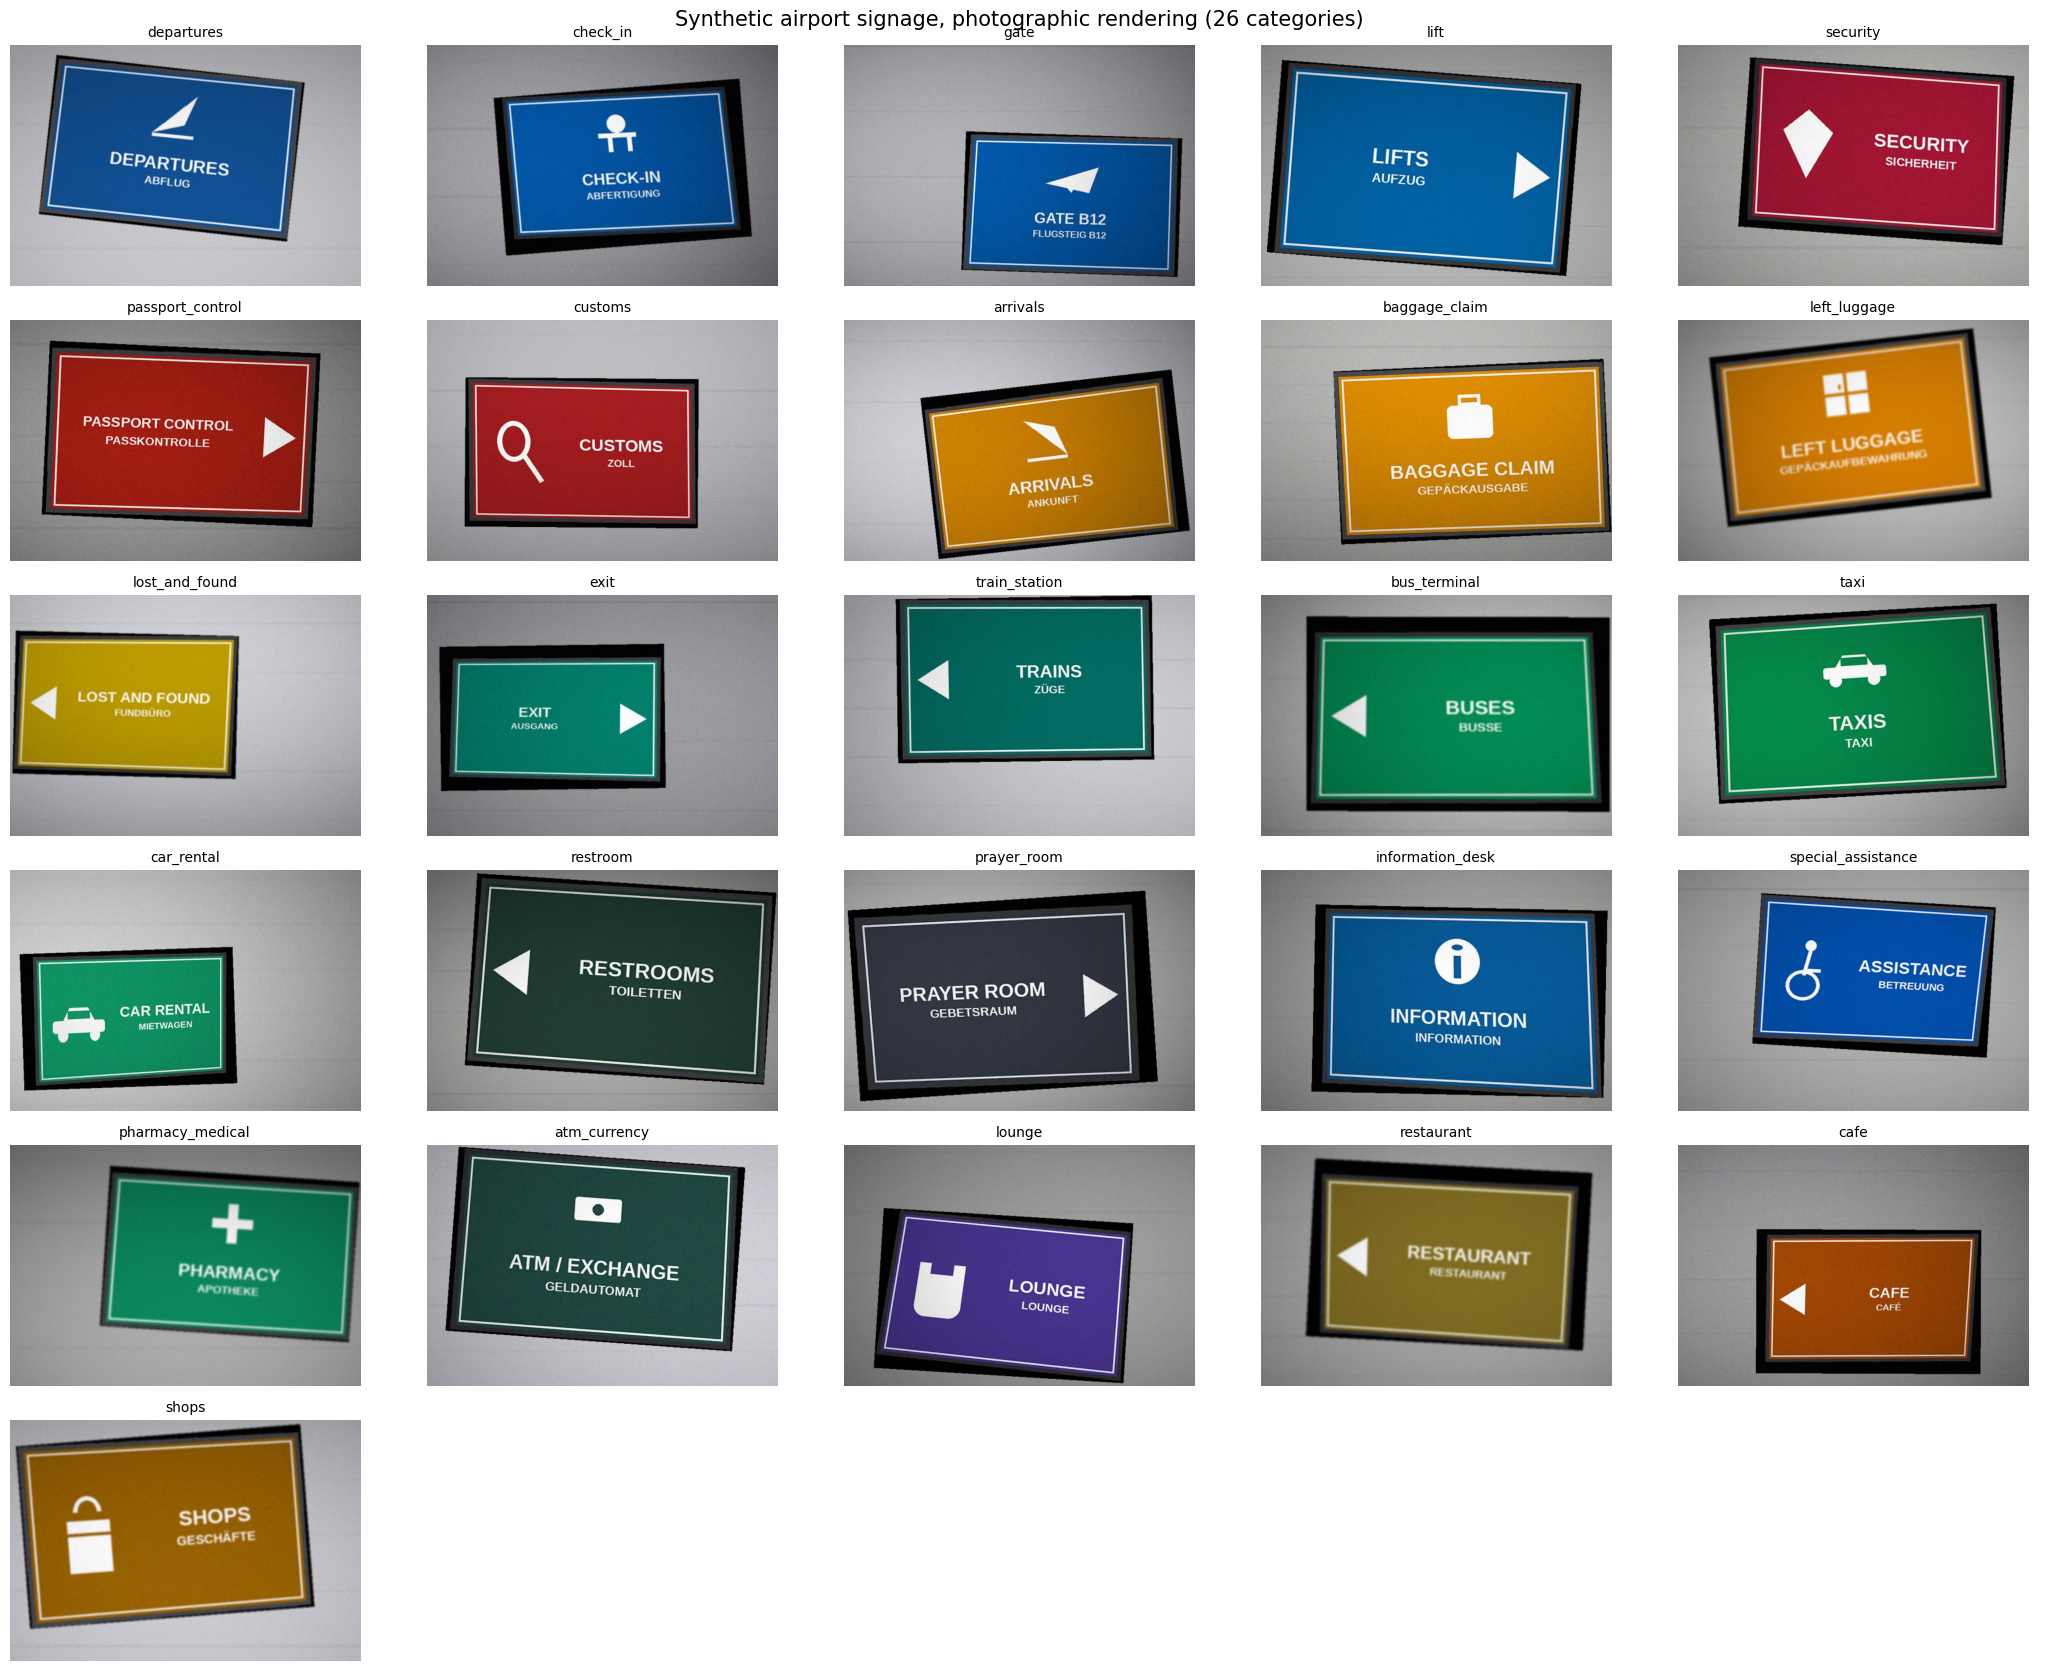

In [ ]:
# Define the three sign layouts that the generator alternates between
SIGN_LAYOUTS = ("pictogram_left", "pictogram_top", "text_with_arrow")


# Render the flat sign face, before any photographic distortion is applied
def render_sign_face(
    category: str,
    *,
    rng: random.Random,
    width: int = 560,
    height: int = 360,
) -> Image.Image:
    # Make the sign colour visible to the glyph helper so its cut-outs match
    global SIGN_CURRENT_BACKGROUND

    # Retrieve the appearance specification for this category
    specification = SIGN_CATALOGUE[category]
    # Jitter the background colour slightly to imitate print and lighting variation
    background = tuple(
        int(np.clip(channel + rng.randint(-22, 22), 0, 255)) for channel in specification["background"]
    )
    SIGN_CURRENT_BACKGROUND = background

    # Create the sign canvas and a drawing surface bound to it
    face = Image.new("RGB", (width, height), background)
    draw = ImageDraw.Draw(face)

    # Draw the dark aluminium mounting frame that real signage is held in
      ## This is also what makes the rotation clean: rotating an RGBA image interpolates the
      ## edge pixels towards the transparent black background, which would otherwise leave a
      ## dark fringe around the sign. Framing the sign in dark grey to begin with means the
      ## interpolation blends dark into dark, so the artefact becomes a deliberate feature.
    frame_shade = rng.randint(45, 75)
    draw.rectangle([0, 0, width, height], outline=(frame_shade, frame_shade, frame_shade + 4), width=10)
    # Draw the white keyline found on most airport signage, inside the frame
    draw.rectangle([16, 16, width - 16, height - 16], outline=(255, 255, 255), width=4)

    # Choose the layout for this variant
    layout = rng.choice(SIGN_LAYOUTS)
    english, german = specification["text"], specification["text_de"]

    # Define a helper that draws one line of text, shrinking it until it fits the given width
    def draw_fitted_text(text: str, centre_x: int, top_y: int, start_size: int, available: int) -> int:
        size = start_size
        font = load_font(size)
        while size > 12 and draw.textbbox((0, 0), text, font=font)[2] > available:
            size -= 2
            font = load_font(size)
        box = draw.textbbox((0, 0), text, font=font)
        draw.text((centre_x - box[2] // 2, top_y), text, font=font, fill=(255, 255, 255))
        return box[3] - box[1]

    if layout == "pictogram_left":
        # Draw the pictogram on the left and both language lines to its right
        draw_glyph(draw, specification["glyph"], (42, 78, 205, 285))
        available = width - 230 - 40
        english_height = draw_fitted_text(english, 230 + available // 2, height // 2 - 42, 42, available)
        draw_fitted_text(german, 230 + available // 2, height // 2 - 42 + english_height + 26, 26, available)

    elif layout == "pictogram_top":
        # Draw the pictogram centred above both language lines
        draw_glyph(draw, specification["glyph"], (width // 2 - 70, 34, width // 2 + 70, 174))
        english_height = draw_fitted_text(english, width // 2, 196, 40, width - 60)
        draw_fitted_text(german, width // 2, 196 + english_height + 22, 25, width - 60)

    else:
        # Draw a text-only sign with a large directional arrow, as corridor signage often is
        arrow_side = rng.choice(["left", "right"])
        arrow_x = 70 if arrow_side == "left" else width - 70
        points = ([(arrow_x + 34, height // 2 - 44), (arrow_x - 34, height // 2), (arrow_x + 34, height // 2 + 44)]
                  if arrow_side == "left"
                  else [(arrow_x - 34, height // 2 - 44), (arrow_x + 34, height // 2), (arrow_x - 34, height // 2 + 44)])
        draw.polygon(points, fill=(255, 255, 255))
        text_centre = width // 2 + (50 if arrow_side == "left" else -50)
        english_height = draw_fitted_text(english, text_centre, height // 2 - 40, 40, width - 220)
        draw_fitted_text(german, text_centre, height // 2 - 40 + english_height + 22, 25, width - 220)

    # Return the flat sign face together with the layout that was used
    face.info["layout"] = layout
    return face


# Define the function that produces one photograph-like image of a synthetic airport sign
def create_sign_image(
    category: str,
    *,
    variant: int = 0,
    width: int = 640,
    height: int = 440,
) -> Image.Image:
    # Reject any category that is not part of the defined catalogue
    if category not in SIGN_CATALOGUE:
        raise ValueError(f"Unknown sign category: {category}")

    # Create a variant-specific generator so every image is reproducible
    rng = random.Random(f"{category}-{variant}-{CONFIG.seed}")

    # 1. Render the flat sign face
    face = render_sign_face(category, rng=rng)

    # 2. Warp the face in perspective, as a photograph taken off-axis would be
    face_width, face_height = face.size
    jitter = min(face_width, face_height) * rng.uniform(0.02, 0.11)
    corners = [(0, 0), (face_width, 0), (face_width, face_height), (0, face_height)]
    warped_corners = [
        (rng.uniform(0, jitter), rng.uniform(0, jitter)),
        (face_width - rng.uniform(0, jitter), rng.uniform(0, jitter)),
        (face_width - rng.uniform(0, jitter), face_height - rng.uniform(0, jitter)),
        (rng.uniform(0, jitter), face_height - rng.uniform(0, jitter)),
    ]
    coefficients = perspective_coefficients(corners, warped_corners)
    face = face.transform((face_width, face_height), Image.PERSPECTIVE, coefficients, RESAMPLE_BICUBIC)

    # 3. Rotate slightly, keeping the corners transparent so the wall shows through
    face = face.convert("RGBA").rotate(rng.uniform(-7, 7), resample=RESAMPLE_BICUBIC, expand=True)

    # 4. Scale the sign so it occupies only part of the frame
    scale = rng.uniform(0.62, 0.90)
    target_width = int(width * scale)
    target_height = int(face.height * target_width / face.width)
    face = face.resize((target_width, target_height), RESAMPLE_BICUBIC)

    # 5. Mount the sign on a terminal wall backdrop at a random position
    scene = build_wall_background(width, height, rng)
    offset_x = rng.randint(0, max(1, width - target_width))
    offset_y = rng.randint(0, max(1, height - target_height))
    scene.paste(face, (offset_x, offset_y), face)

    # 6. Apply uneven terminal lighting across the whole frame
    scene = apply_lighting(scene, rng)

    # 7. Apply motion or focus blur on some variants
    if rng.random() < 0.45:
        scene = scene.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.5, 1.8)))

    # 8. Darken the corners the way a camera lens does
    scene = apply_vignette(scene, rng)

    # 9. Add sensor noise, seeded per image so the dataset stays byte-reproducible
    noise_generator = np.random.default_rng(rng.getrandbits(32))
    array = np.asarray(scene, dtype=np.float32) + noise_generator.normal(0, rng.uniform(2.5, 7.0), (height, width, 3))
    scene = Image.fromarray(np.clip(array, 0, 255).astype(np.uint8))

    # 10. Re-encode as JPEG so the image carries real compression artefacts
    buffer = io.BytesIO()
    scene.save(buffer, format="JPEG", quality=rng.randint(55, 92))
    buffer.seek(0)

    # Return the finished photograph-like image
    return Image.open(buffer).convert("RGB")


# Render one example of every category to verify the generator works
figure, axes = plt.subplots(6, 5, figsize=(21, 17))
for axis, category in zip(axes.flatten(), SIGN_CATEGORIES):
    axis.imshow(create_sign_image(category, variant=0))
    axis.set_title(category, fontsize=10)
    axis.axis("off")
# Hide any unused subplot in the grid
for axis in axes.flatten()[len(SIGN_CATEGORIES):]:
    axis.axis("off")
plt.suptitle(f"Synthetic airport signage, photographic rendering ({len(SIGN_CATEGORIES)} categories)", fontsize=15)
plt.tight_layout()
plt.show()

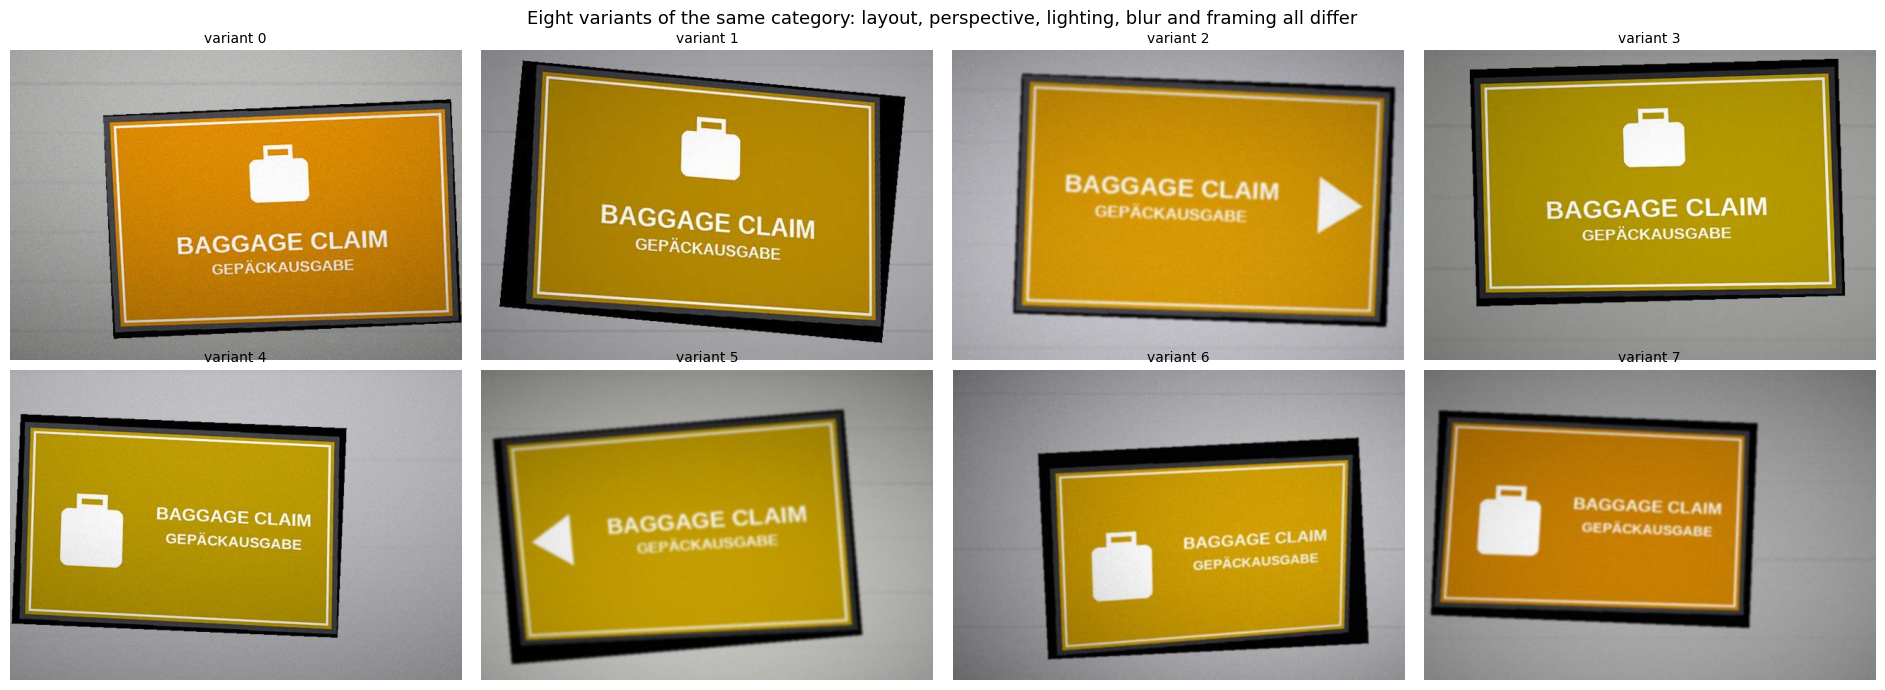

In [ ]:
# Show several variants of one category, to make the injected variation visible
figure, axes = plt.subplots(2, 4, figsize=(19, 7))
for axis, variant in zip(axes.flatten(), range(8)):
    axis.imshow(create_sign_image("baggage_claim", variant=variant))
    axis.set_title(f"variant {variant}", fontsize=10)
    axis.axis("off")
plt.suptitle("Eight variants of the same category: layout, perspective, lighting, blur and framing all differ",
             fontsize=13)
plt.tight_layout()
plt.show()




### **Build and annotate the visual dataset**

The data set consists of 172 pictures (640×440) of 26 categories (3-12 pictures per category) and the respective labels: Category,Variant,Wording and Pictogram.

In [ ]:
# Define how many image variants to generate for each category
  ## The counts are deliberately uneven, reflecting how often each sign appears in a real terminal
IMAGES_PER_CATEGORY: Dict[str, int] = {
    # Signs a passenger encounters constantly
    "gate": 12, "departures": 10, "arrivals": 10, "check_in": 9, "security": 9,
    "baggage_claim": 9, "restroom": 8, "exit": 8, "information_desk": 8,
    # Signs encountered once or twice per journey
    "passport_control": 7, "lift": 7, "train_station": 6, "bus_terminal": 6,
    "taxi": 6, "restaurant": 6, "cafe": 6, "shops": 6, "lounge": 5,
    # Signs encountered only when specifically needed
    "customs": 5, "special_assistance": 5, "atm_currency": 5, "pharmacy_medical": 4,
    "car_rental": 4, "left_luggage": 4, "lost_and_found": 4, "prayer_room": 3,
}


# Define the function that writes the whole visual dataset to disk
def build_visual_dataset(root: str = CONFIG.dataset_root) -> pd.DataFrame:
    # Create the destination folder, including any missing parents
    root_path = Path(root)
    root_path.mkdir(parents=True, exist_ok=True)

    # Collect one annotation record per generated image
    records: List[Dict[str, Any]] = []

    # Work through every category in the catalogue
    for category, count in IMAGES_PER_CATEGORY.items():
        # Create a dedicated subfolder for this category
        category_path = root_path / category
        category_path.mkdir(parents=True, exist_ok=True)

        # Generate the requested number of variants
        for variant in range(count):
            # Render the synthetic sign and write it to disk
            image = create_sign_image(category, variant=variant)
            file_path = category_path / f"{category}_{variant:02d}.png"
            image.save(file_path)

            # Record the annotation for this image
            records.append({
                "file_path": str(file_path),
                "category": category,
                "variant": variant,
                "sign_text": SIGN_CATALOGUE[category]["text"],
                "glyph": SIGN_CATALOGUE[category]["glyph"],
                "width": image.width,
                "height": image.height,
            })

    # Return the annotations as a tabular dataset
    return pd.DataFrame(records)


# Generate the visual dataset and capture its annotation table
visual_dataset = build_visual_dataset()

# Report the size of the resulting dataset
print(f"Total images generated: {len(visual_dataset)}")
print(f"Categories: {visual_dataset['category'].nunique()}")
print(f"Images per category: min={visual_dataset['category'].value_counts().min()}, "
      f"max={visual_dataset['category'].value_counts().max()}")
# Show the first few annotation rows
display(visual_dataset.head(8))

Total images generated: 172
Categories: 26
Images per category: min=3, max=12


,file_path,category,variant,sign_text,glyph,width,height
0,airport_dataset/gate/gate_00.png,gate,0,GATE B12,aeroplane,640,440
1,airport_dataset/gate/gate_01.png,gate,1,GATE B12,aeroplane,640,440
2,airport_dataset/gate/gate_02.png,gate,2,GATE B12,aeroplane,640,440
3,airport_dataset/gate/gate_03.png,gate,3,GATE B12,aeroplane,640,440
4,airport_dataset/gate/gate_04.png,gate,4,GATE B12,aeroplane,640,440
5,airport_dataset/gate/gate_05.png,gate,5,GATE B12,aeroplane,640,440
6,airport_dataset/gate/gate_06.png,gate,6,GATE B12,aeroplane,640,440
7,airport_dataset/gate/gate_07.png,gate,7,GATE B12,aeroplane,640,440


The distribution is intentional, with 12 images of the gates, and three images of the prayer rooms. Since the model is not trained as a classifier this does not introduce a learning bias; however, scores obtained across three images are too broad to be distinguished from chance.

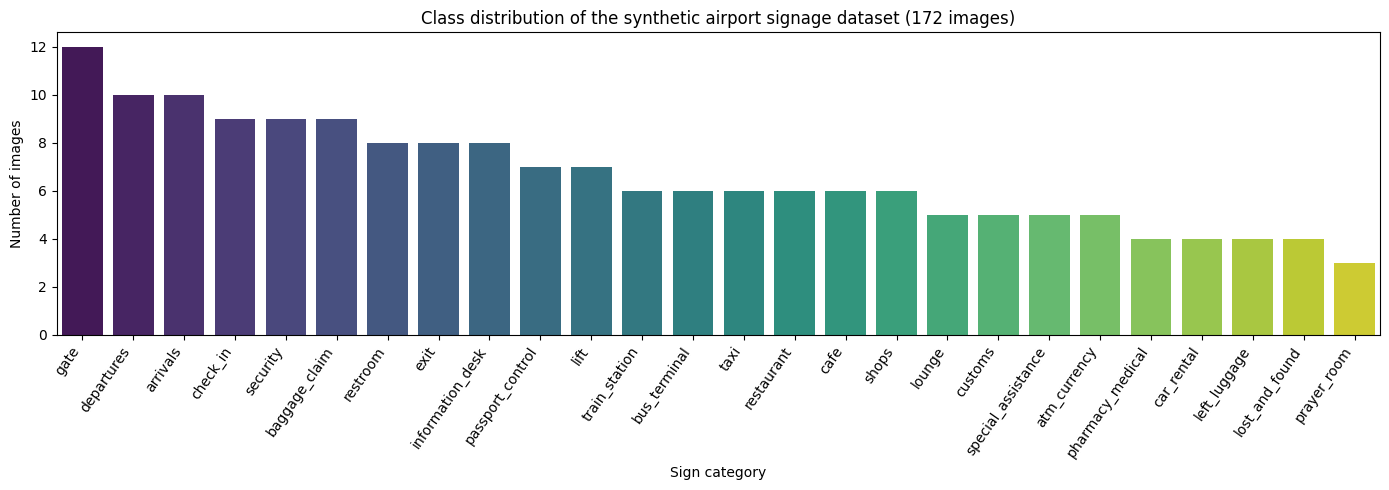

Largest class:  gate (12 images)
Smallest class: prayer_room (3 images)
Imbalance ratio: 4.00 to 1
Mean images per class: 6.6


In [ ]:
# Count how many images belong to each category
category_counts = visual_dataset["category"].value_counts().sort_values(ascending=False)

# Create the figure for the distribution plot
plt.figure(figsize=(14, 5))
sns.barplot(x=category_counts.index, y=category_counts.values,
            hue=category_counts.index, palette="viridis", legend=False)
plt.title(f"Class distribution of the synthetic airport signage dataset ({len(visual_dataset)} images)")
plt.xlabel("Sign category")
plt.ylabel("Number of images")
plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()

# Quantify the imbalance so it can be cited in the report
imbalance_ratio = category_counts.max() / category_counts.min()
print(f"Largest class:  {category_counts.idxmax()} ({category_counts.max()} images)")
print(f"Smallest class: {category_counts.idxmin()} ({category_counts.min()} images)")
print(f"Imbalance ratio: {imbalance_ratio:.2f} to 1")
print(f"Mean images per class: {category_counts.mean():.1f}")

### **Compare similar and dissimilar visual examples**

Actually there are four pairs that are confusable: Red palette for Security and Passport Control; Green and Vehicle pictograms for Trains, buses and taxi; Warm palette for Restaurant and Cafe; Mirrored pictogram for Departures and Arrival.

Pair 1: security vs passport_control — Similar: both red control points, adjacent in the terminal
Pair 2: train_station vs bus_terminal — Similar: both green transport signs, vehicle pictograms
Pair 3: restaurant vs cafe — Similar: same warm palette, both catering
Pair 4: departures vs arrivals — Similar: mirrored aircraft pictogram, opposite journey stage
Pair 5: gate vs pharmacy_medical — Dissimilar: different colour, pictogram and purpose


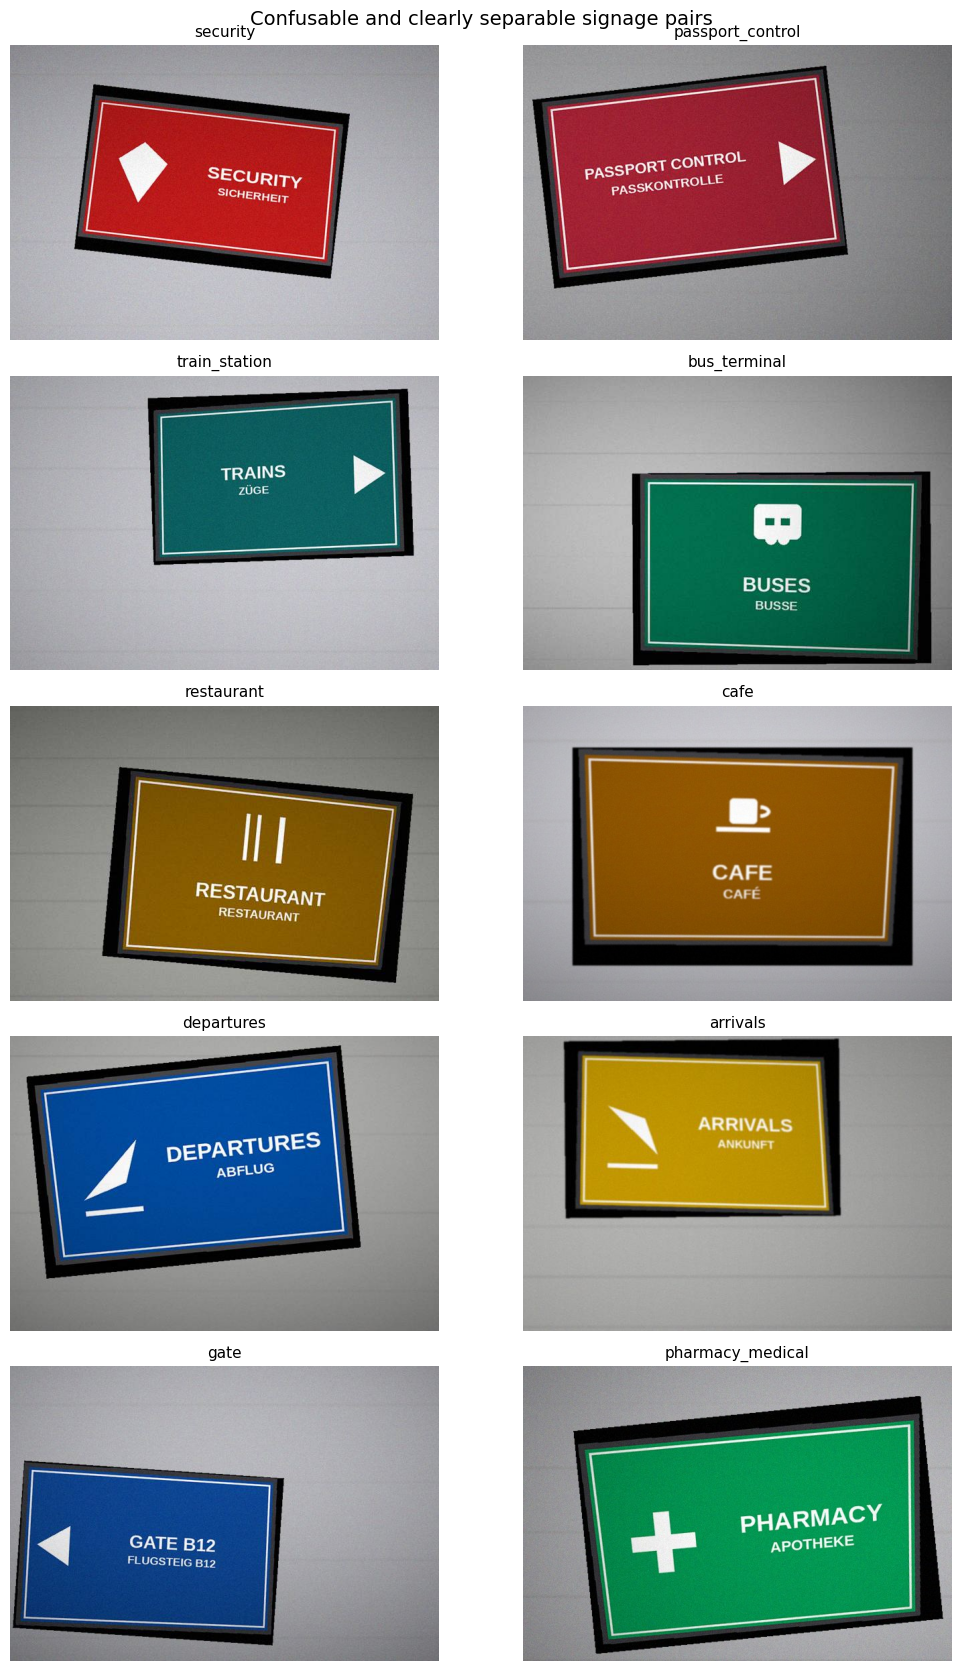

In [ ]:
# Define the pairs to be visually compared, and why each pair matters
comparison_pairs = [
    ("security", "passport_control", "Similar: both red control points, adjacent in the terminal"),
    ("train_station", "bus_terminal",  "Similar: both green transport signs, vehicle pictograms"),
    ("restaurant", "cafe",             "Similar: same warm palette, both catering"),
    ("departures", "arrivals",         "Similar: mirrored aircraft pictogram, opposite journey stage"),
    ("gate", "pharmacy_medical",       "Dissimilar: different colour, pictogram and purpose"),
]

# Render every pair in a two-column grid
figure, axes = plt.subplots(len(comparison_pairs), 2, figsize=(11, 3.4 * len(comparison_pairs)))
for row, (first, second, caption) in enumerate(comparison_pairs):
    axes[row, 0].imshow(create_sign_image(first, variant=1))
    axes[row, 0].set_title(first, fontsize=11)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(create_sign_image(second, variant=1))
    axes[row, 1].set_title(second, fontsize=11)
    axes[row, 1].axis("off")
    # Print the reason for the comparison so it can be quoted in the report
    print(f"Pair {row + 1}: {first} vs {second} — {caption}")

plt.suptitle("Confusable and clearly separable signage pairs", fontsize=14)
plt.tight_layout()
plt.show()

### **Dataset limitations**

The sizes of the categories are determined by the number of actual signs that exist, causing the smallest classes to be weakened. No sign is hidden by reflections or passengers as in real uploads, and lighting is gradient and vignetting, but not glare or backlight. The same visual style was used for all the signs; results are a maximum bound; transfer to other signage systems was not tested.

## **2.2 Voice and text data — passenger queries**

This data set includes 33 records and 60 queries, with each intents having at least one category of signage. The key difference between these is naming a service and stating a need: a passenger in distress describes their situation, not a solution.

In [ ]:
# Define the passenger query dataset
  ## Each row carries the query, its intent (identical to the signage category) and the expected record
PASSENGER_QUERIES: List[Dict[str, str]] = [
    # --- Gates ---
    {"query": "Where is gate B12?",                                   "intent": "gate",               "expected_record": "KB01"},
    {"query": "How do I get to my boarding gate in terminal 1?",      "intent": "gate",               "expected_record": "KB01"},
    {"query": "I am boarding at gate A05, which way is it?",          "intent": "gate",               "expected_record": "KB03"},

    # --- Departures and check-in ---
    {"query": "Where is the departures hall?",                        "intent": "departures",         "expected_record": "KB35"},
    {"query": "I just arrived at the airport, where do I start?",     "intent": "departures",         "expected_record": "KB35"},
    {"query": "Where is the check in desk for international flights?","intent": "check_in",           "expected_record": "KB05"},
    {"query": "Which counter do I use to drop my bag?",               "intent": "check_in",           "expected_record": "KB05"},
    {"query": "Where do I check in for a domestic flight?",           "intent": "check_in",           "expected_record": "KB06"},

    # --- Control points ---
    {"query": "Where is the security control?",                       "intent": "security",           "expected_record": "KB07"},
    {"query": "How long is the security queue right now?",            "intent": "security",           "expected_record": "KB07"},
    {"query": "Where do I get my passport stamped?",                  "intent": "passport_control",   "expected_record": "KB09"},
    {"query": "Where is immigration and border control?",             "intent": "passport_control",   "expected_record": "KB09"},
    {"query": "I have goods to declare, where do I go?",              "intent": "customs",            "expected_record": "KB10"},
    {"query": "Where is the customs green channel?",                  "intent": "customs",            "expected_record": "KB10"},

    # --- Arrivals and baggage ---
    {"query": "Where is the arrivals hall?",                          "intent": "arrivals",           "expected_record": "KB34"},
    {"query": "I am picking someone up from a landing flight",        "intent": "arrivals",           "expected_record": "KB34"},
    {"query": "How do I get to baggage claim?",                       "intent": "baggage_claim",      "expected_record": "KB11"},
    {"query": "Where do I pick up my suitcase after landing?",        "intent": "baggage_claim",      "expected_record": "KB11"},
    {"query": "Which belt has the bags from terminal 2 flights?",     "intent": "baggage_claim",      "expected_record": "KB12"},
    {"query": "Can I store my bags somewhere for a few hours?",       "intent": "left_luggage",       "expected_record": "KB13"},
    {"query": "Where is the left luggage storage?",                   "intent": "left_luggage",       "expected_record": "KB13"},
    {"query": "I lost my phone, where do I report it?",               "intent": "lost_and_found",     "expected_record": "KB14"},
    {"query": "My bag never arrived on the belt, who do I tell?",     "intent": "lost_and_found",     "expected_record": "KB14"},

    # --- Facilities ---
    {"query": "Where are the restrooms?",                             "intent": "restroom",           "expected_record": "KB15"},
    {"query": "wheres the loo",                                       "intent": "restroom",           "expected_record": "KB15"},
    {"query": "Is there an accessible toilet in terminal 2?",         "intent": "restroom",           "expected_record": "KB16"},
    {"query": "Where is the prayer room?",                            "intent": "prayer_room",        "expected_record": "KB17"},
    {"query": "Is there somewhere quiet I can pray or rest?",         "intent": "prayer_room",        "expected_record": "KB17"},
    {"query": "Is there a lounge near terminal 2?",                   "intent": "lounge",             "expected_record": "KB18"},
    {"query": "Where can I wait comfortably before my flight?",       "intent": "lounge",             "expected_record": "KB18"},
    {"query": "Is there a business lounge in terminal 1?",            "intent": "lounge",             "expected_record": "KB19"},

    # --- Catering and retail ---
    {"query": "Where can I eat something before boarding?",           "intent": "restaurant",         "expected_record": "KB20"},
    {"query": "Are there any restaurants after security?",            "intent": "restaurant",         "expected_record": "KB20"},
    {"query": "Is there a sit down restaurant in terminal 1?",        "intent": "restaurant",         "expected_record": "KB21"},
    {"query": "Where can I get a coffee?",                            "intent": "cafe",               "expected_record": "KB22"},
    {"query": "I need a quick snack and an espresso",                 "intent": "cafe",               "expected_record": "KB22"},
    {"query": "Where is the duty free shopping?",                     "intent": "shops",              "expected_record": "KB23"},
    {"query": "I want to buy a gift before I fly",                    "intent": "shops",              "expected_record": "KB23"},

    # --- Money and health ---
    {"query": "Where is the nearest cash machine?",                   "intent": "atm_currency",       "expected_record": "KB24"},
    {"query": "I need to change money into euros",                    "intent": "atm_currency",       "expected_record": "KB24"},
    {"query": "Where is the pharmacy?",                               "intent": "pharmacy_medical",   "expected_record": "KB25"},
    {"query": "I feel unwell, where can I get help?",                 "intent": "pharmacy_medical",   "expected_record": "KB25"},

    # --- Help and assistance ---
    {"query": "Where is the nearest information desk?",               "intent": "information_desk",   "expected_record": "KB26"},
    {"query": "Who can help me if I am lost in the terminal?",        "intent": "information_desk",   "expected_record": "KB26"},
    {"query": "Is there an information point in terminal 2?",         "intent": "information_desk",   "expected_record": "KB27"},
    {"query": "I need wheelchair assistance please",                  "intent": "special_assistance", "expected_record": "KB28"},
    {"query": "My mother cannot walk far, can someone help her?",     "intent": "special_assistance", "expected_record": "KB28"},
    {"query": "Where is the special assistance desk?",                "intent": "special_assistance", "expected_record": "KB28"},

    # --- Onward transport ---
    {"query": "How do I get to the train station from the airport?",  "intent": "train_station",      "expected_record": "KB29"},
    {"query": "Is there a rail connection to the city centre?",       "intent": "train_station",      "expected_record": "KB29"},
    {"query": "Where do the coaches leave from?",                     "intent": "bus_terminal",       "expected_record": "KB30"},
    {"query": "I need the shuttle bus to a nearby city",              "intent": "bus_terminal",       "expected_record": "KB30"},
    {"query": "Where can I get a taxi?",                              "intent": "taxi",               "expected_record": "KB31"},
    {"query": "Where is the official cab rank outside arrivals?",     "intent": "taxi",               "expected_record": "KB31"},
    {"query": "Where do I collect my hire car?",                      "intent": "car_rental",         "expected_record": "KB32"},
    {"query": "I booked a rental car, where is the desk?",            "intent": "car_rental",         "expected_record": "KB32"},

    # --- Getting around and leaving ---
    {"query": "Where is the lift to the upper level?",                "intent": "lift",               "expected_record": "KB33"},
    {"query": "I cannot use the escalator, is there another way up?", "intent": "lift",               "expected_record": "KB33"},
    {"query": "Where is the exit and the meeting point?",             "intent": "exit",               "expected_record": "KB36"},
    {"query": "My family is waiting for me, where do we meet?",       "intent": "exit",               "expected_record": "KB36"},
]

# Convert the query list into a table
query_dataset = pd.DataFrame(PASSENGER_QUERIES)

# Report the coverage of the query dataset
print(f"Passenger queries: {len(query_dataset)}")
print(f"Distinct intents:  {query_dataset['intent'].nunique()}")
print(f"Distinct expected records: {query_dataset['expected_record'].nunique()}")
print(f"Queries per intent: min={query_dataset['intent'].value_counts().min()}, "
      f"max={query_dataset['intent'].value_counts().max()}")

# Confirm every signage category has at least one query, so vision and text cover the same domain
uncovered = set(SIGN_CATEGORIES) - set(query_dataset["intent"])
print(f"Signage categories with no query: {uncovered if uncovered else 'none'}")

# Show the query table
display(query_dataset)

Passenger queries: 60
Distinct intents:  26
Distinct expected records: 33
Queries per intent: min=2, max=3
Signage categories with no query: none


,query,intent,expected_record
0,Where is gate B12?,gate,KB01
1,How do I get to my boarding gate in terminal 1?,gate,KB01
2,"I am boarding at gate A05, which way is it?",gate,KB03
3,Where is the departures hall?,departures,KB35
4,"I just arrived at the airport, where do I start?",departures,KB35
5,Where is the check in desk for international f...,check_in,KB05
6,Which counter do I use to drop my bag?,check_in,KB05
7,Where do I check in for a domestic flight?,check_in,KB06
8,Where is the security control?,security,KB07
9,How long is the security queue right now?,security,KB07


There are 26 voice clips created with text to speech, one for each intent in 6 accents. Using synthesis instead of recording was preferred as per GDPR a recorded voice is considered biometric data.

In [ ]:
# Import the text-to-speech library used to synthesise the voice dataset
from gtts import gTTS


# Define the function that renders a stratified sample of queries as audio files
def build_voice_dataset(
    queries: pd.DataFrame,
    *,
    root: str = CONFIG.audio_root,
    per_intent: int = 1,
    max_clips: int = 26,
) -> pd.DataFrame:
    # Create the destination folder, including any missing parents
    root_path = Path(root)
    root_path.mkdir(parents=True, exist_ok=True)

    # Take a stratified sample so every intent is represented in the voice dataset
      ## Sampling by intent avoids a voice evaluation biased toward whichever queries happen to come first
    subset = (
        queries.groupby("intent", group_keys=False)
        .head(per_intent)
        .head(max_clips)
        .reset_index(drop=True)
    )

    # Collect one record per generated clip
    records: List[Dict[str, Any]] = []

    # Work through the sampled queries
    for index, row in subset.iterrows():
        # Build the destination file name for this clip
        file_path = root_path / f"query_{index:02d}.mp3"

        # Only synthesise the clip if it does not already exist
        if not file_path.exists():
            # Vary the accent across clips to expose the system to different speech profiles
            accent = ["com", "co.uk", "com.au", "co.in", "ie", "co.za"][index % 6]
            # Create the speech object and write it to disk
            gTTS(text=row["query"], lang="en", tld=accent).save(str(file_path))

        # Record the clip alongside its reference transcript
        records.append({
            "audio_path": str(file_path),
            "reference_text": row["query"],
            "intent": row["intent"],
            "expected_record": row["expected_record"],
            "accent_profile": ["US", "UK", "AU", "IN", "IE", "ZA"][index % 6],
        })

    # Return the audio dataset as a table
    return pd.DataFrame(records)


# Generate the voice dataset, one clip per intent
voice_dataset = build_voice_dataset(query_dataset)

# Report the coverage of the voice dataset
print(f"Voice clips available: {len(voice_dataset)}")
print(f"Intents covered:       {voice_dataset['intent'].nunique()}")
print(f"Accent profiles:       {', '.join(sorted(voice_dataset['accent_profile'].unique()))}")
display(voice_dataset.head(10))

# Play the first clip so the audio can be verified by ear
display(Audio(voice_dataset.loc[0, "audio_path"]))

Voice clips available: 26
Intents covered:       26
Accent profiles:       AU, IE, IN, UK, US, ZA


,audio_path,reference_text,intent,expected_record,accent_profile
0,airport_audio/query_00.mp3,Where is gate B12?,gate,KB01,US
1,airport_audio/query_01.mp3,Where is the departures hall?,departures,KB35,UK
2,airport_audio/query_02.mp3,Where is the check in desk for international f...,check_in,KB05,AU
3,airport_audio/query_03.mp3,Where is the security control?,security,KB07,IN
4,airport_audio/query_04.mp3,Where do I get my passport stamped?,passport_control,KB09,IE
5,airport_audio/query_05.mp3,"I have goods to declare, where do I go?",customs,KB10,ZA
6,airport_audio/query_06.mp3,Where is the arrivals hall?,arrivals,KB34,US
7,airport_audio/query_07.mp3,How do I get to baggage claim?,baggage_claim,KB11,UK
8,airport_audio/query_08.mp3,Can I store my bags somewhere for a few hours?,left_luggage,KB13,AU
9,airport_audio/query_09.mp3,"I lost my phone, where do I report it?",lost_and_found,KB14,IN


### **Tokenise and explore the text queries**

The queries result in 457 tokens with 182 words in the vocabulary generating an average of 7.6 tokens per query. Since "where" and "is" are the most commonly used words, stop word removal is not done: it would remove words that contain the meaning.

Total tokens:          457
Vocabulary size:       182
Type-token ratio:      0.398
Average query length:  7.6 tokens
Longest query:         11 tokens

Most frequent tokens:


,token,count
0,i,34
1,where,33
2,the,31
3,is,29
4,do,14
5,a,13
6,my,11
7,to,10
8,can,9
9,there,9


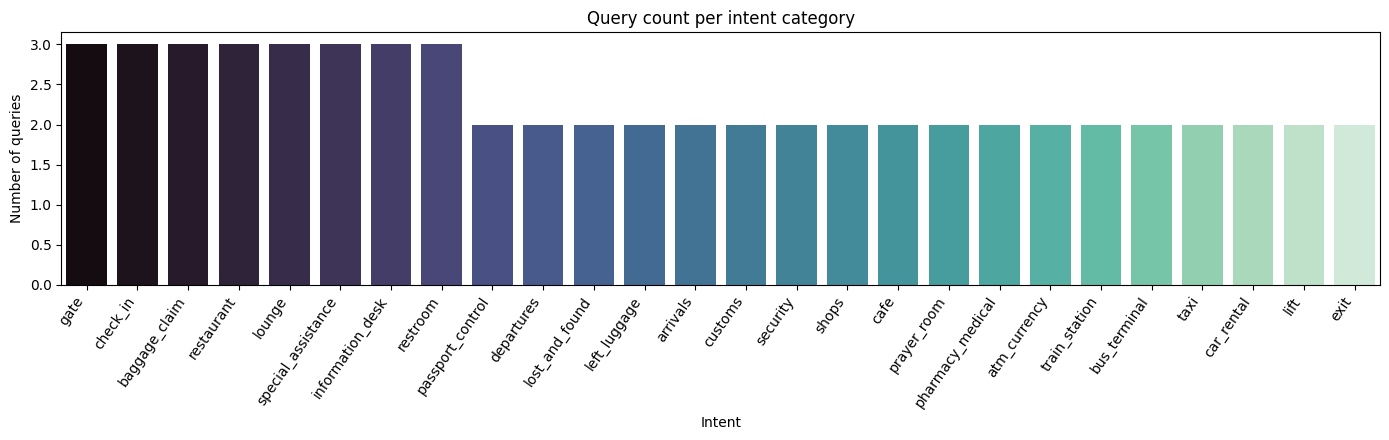

In [ ]:
# Define a simple tokeniser used for dataset exploration
def simple_tokenise(text: str) -> List[str]:
    # Reject empty or non-text input
    if not isinstance(text, str) or not text.strip():
        raise ValueError("The text must be a non-empty string.")
    # Lowercase the text and extract word-like sequences
    return re.findall(r"[a-z0-9]+", text.lower())


# Tokenise every query in the dataset
all_tokens = [token for query in query_dataset["query"] for token in simple_tokenise(query)]
# Count how often each token appears
token_counts = Counter(all_tokens)

# Report basic vocabulary statistics
print(f"Total tokens:          {len(all_tokens)}")
print(f"Vocabulary size:       {len(token_counts)}")
print(f"Type-token ratio:      {len(token_counts) / len(all_tokens):.3f}")
print(f"Average query length:  {len(all_tokens) / len(query_dataset):.1f} tokens")
print(f"Longest query:         {max(len(simple_tokenise(q)) for q in query_dataset['query'])} tokens")

# Show the most frequent tokens
print("\nMost frequent tokens:")
display(pd.DataFrame(token_counts.most_common(15), columns=["token", "count"]))

# Plot how many queries belong to each intent
intent_counts = query_dataset["intent"].value_counts()
plt.figure(figsize=(14, 4.5))
sns.barplot(x=intent_counts.index, y=intent_counts.values,
            hue=intent_counts.index, palette="mako", legend=False)
plt.title("Query count per intent category")
plt.xlabel("Intent")
plt.ylabel("Number of queries")
plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()

### **Entity extraction from passenger queries**

The following entity types are extracted by rule: gate number,terminal number. Spoken numbers are normalized to digits, so "gate B12", "gate b 12" and "gate b twelve" all resolve to the same thing, which is important as a wrong gate can result in a missed flight. Ninety out of 60 queries have an entity: retrieval is about meaning, entities disambiguate and do not retrieve.

In [ ]:
# Map spoken number words onto digits
  ## [IMPORTANT] Section 5.2 shows Whisper's single most damaging error on this dataset:
  ## it writes gate identifiers as "b twelve" or "b 12" rather than "B12". Normalising the
  ## spoken form BEFORE entity extraction is what lets a voice query resolve to the right
  ## gate, which is precisely the entity a passenger most needs answered correctly.
SPOKEN_NUMBERS: Dict[str, str] = {
    "zero": "0", "oh": "0", "one": "1", "two": "2", "three": "3", "four": "4", "five": "5",
    "six": "6", "seven": "7", "eight": "8", "nine": "9", "ten": "10", "eleven": "11",
    "twelve": "12", "thirteen": "13", "fourteen": "14", "fifteen": "15", "sixteen": "16",
    "seventeen": "17", "eighteen": "18", "nineteen": "19", "twenty": "20",
}


# Convert spoken number words in a lowercase string into digits
def normalise_spoken_numbers(text: str) -> str:
    # Replace each number word wherever it appears as a whole word
    for word, digit in SPOKEN_NUMBERS.items():
        text = re.sub(rf"\b{word}\b", digit, text)
    # Join a letter to the digits that follow it, so "b 12" and "b-12" both become "b12"
      ## This is applied only after a gate-like context word or where the pair already
      ## looks like an identifier, so ordinary phrases are left untouched
    text = re.sub(r"\b([a-z])[\s\-]+(\d{1,2})\b", r"\1\2", text)
    # Return the normalised string
    return text


# Define regular expressions for each entity type the chatbot must recognise
ENTITY_PATTERNS: Dict[str, str] = {
    # A gate identifier is a single letter followed by one or two digits
      ## The word "gate" is NOT required: passengers write "I am at B12" just as often.
      ## Candidates are validated against the real gate names in Section 4, so a stray
      ## match such as a road name cannot resolve to a gate that does not exist.
    "gate_number":     r"\b([a-z]\s?\d{1,2})\b",
    # A terminal identifier is the word terminal followed by a digit
    "terminal_number": r"\bterminal\s+(\d)\b",
    # A baggage belt identifier
    "belt_number":     r"\bbelt\s+(\d{1,2})\b",
    # A clock time in either 24-hour or 12-hour form
    "time_reference":  r"\b(\d{1,2}[:h]\d{2}\s?(?:am|pm)?|\d{1,2}\s?(?:am|pm))\b",
    # A flight number is two letters followed by three or four digits
    "flight_number":   r"\b([a-z]{2}\s?\d{3,4})\b",
}


# Define the function that extracts every recognised entity from one query
def extract_entities(text: str) -> Dict[str, List[str]]:
    # Reject empty or non-text input
    if not isinstance(text, str) or not text.strip():
        raise ValueError("The text must be a non-empty string.")

    # Work on a lowercase copy, with spoken numbers converted to digits first
    normalised = normalise_spoken_numbers(text.lower())
    # Collect the matches found for each entity type
    found: Dict[str, List[str]] = {}

    # Apply every pattern in turn
    for entity_name, pattern in ENTITY_PATTERNS.items():
        matches = re.findall(pattern, normalised)
        # Only record the entity type if at least one match was found
        if matches:
            found[entity_name] = [match.strip().upper() for match in matches]

    # Return the dictionary of recognised entities
    return found


# Test the extractor on realistic passenger sentences, typed and transcribed
entity_test_sentences = [
    "Where is gate B12?",
    "where is gate b 12",                     # how Whisper transcribes the same question
    "where is gate b twelve",                 # how Whisper sometimes writes it in full
    "I am at B12, how long to security?",     # no context word before the identifier
    "My flight LH1234 leaves from terminal 2 at 14:30",
    "Is the lounge in terminal two open at 6 am?",
    "My bag is not on belt 4",
    "Where are the toilets?",
]

# Print the entities recognised in each test sentence
for sentence in entity_test_sentences:
    print(f"{sentence}\n  -> {json.dumps(extract_entities(sentence))}")

# Measure how many queries in the dataset carry at least one entity
with_entities = sum(1 for q in query_dataset["query"] if extract_entities(q))
print(f"\nQueries containing at least one entity: {with_entities} of {len(query_dataset)} "
      f"({with_entities / len(query_dataset):.0%})")
print("Most passenger queries carry no structured entity at all, which is why retrieval")
print("is driven by semantic similarity rather than by entity matching alone.")

Where is gate B12?
  -> {"gate_number": ["B12"]}
where is gate b 12
  -> {"gate_number": ["B12"]}
where is gate b twelve
  -> {"gate_number": ["B12"]}
I am at B12, how long to security?
  -> {"gate_number": ["B12"]}
My flight LH1234 leaves from terminal 2 at 14:30
  -> {"terminal_number": ["2"], "time_reference": ["14:30"], "flight_number": ["LH1234"]}
Is the lounge in terminal two open at 6 am?
  -> {"terminal_number": ["2"], "time_reference": ["6 AM"]}
My bag is not on belt 4
  -> {"belt_number": ["4"]}
Where are the toilets?
  -> {}

Queries containing at least one entity: 9 of 60 (15%)
Most passenger queries carry no structured entity at all, which is why retrieval
is driven by semantic similarity rather than by entity matching alone.


## **2.3 Airport Knowledge Base — required component**

The knowledge base which the chatbot accesses is a 36 record JSON file, one record for each place/service. It is not used for learning, it is consulted if something is asked by a passenger.

In [ ]:
# Define the structured airport knowledge base
  ## This is a lookup resource, not a trained model
AIRPORT_KNOWLEDGE_BASE: List[Dict[str, Any]] = [
    # ---------- Gates ----------
    {"record_id": "KB01", "name": "Gate B12", "category": "gate", "terminal": "Terminal 1",
     "floor_zone": "Level 2, Zone B",
     "description": "Boarding gate serving short-haul European departures.",
     "opening_hours": "04:30-23:30",
     "direction_text": "After security, follow the signs for Gates B1 to B20, then keep right for 200 metres.",
     "accessibility": "Step-free access via lift 2B. Wheelchair assistance on request.",
     "related_facilities": ["Gate B10", "Aviator Lounge", "Level 2 Restrooms"],
     "emergency_contact": "+49 30 0000 0112",
     "synonyms": "boarding gate departure gate b12 plane door aircraft door"},

    {"record_id": "KB02", "name": "Gate B10", "category": "gate", "terminal": "Terminal 1",
     "floor_zone": "Level 2, Zone B",
     "description": "Boarding gate serving long-haul intercontinental departures.",
     "opening_hours": "04:30-23:30",
     "direction_text": "After security, follow the signs for Gates B1 to B20 and stay left at the fork.",
     "accessibility": "Step-free access via lift 2B. Priority boarding lane available.",
     "related_facilities": ["Gate B12", "Level 2 Restrooms", "Prayer and Quiet Room"],
     "emergency_contact": "+49 30 0000 0110",
     "synonyms": "gate b10 long haul intercontinental boarding gate departure"},

    {"record_id": "KB03", "name": "Gate A05", "category": "gate", "terminal": "Terminal 2",
     "floor_zone": "Level 2, Zone A",
     "description": "Boarding gate serving domestic and regional departures.",
     "opening_hours": "05:00-22:30",
     "direction_text": "After Terminal 2 security, turn left and follow the signs for Gates A1 to A12.",
     "accessibility": "Step-free access. Priority boarding lane available.",
     "related_facilities": ["Terminal 2 Restaurant Court", "Skyview Business Lounge"],
     "emergency_contact": "+49 30 0000 0105",
     "synonyms": "gate a05 a5 domestic boarding regional departure gate a"},

    {"record_id": "KB04", "name": "Gate C22", "category": "gate", "terminal": "Terminal 2",
     "floor_zone": "Level 3, Zone C",
     "description": "Boarding gate serving low-cost carrier departures, reached by shuttle bus.",
     "opening_hours": "05:00-22:30",
     "direction_text": "From Terminal 2 security, take lift C to level 3 and follow signs for the bus gates.",
     "accessibility": "Lift access to the gate. Bus boarding is not step-free, staff assistance required.",
     "related_facilities": ["Gate A05", "Terminal 2 Restaurant Court"],
     "emergency_contact": "+49 30 0000 0122",
     "synonyms": "gate c22 low cost bus gate remote stand shuttle boarding"},

    # ---------- Departures and check-in ----------
    {"record_id": "KB05", "name": "Terminal 1 Check-in Halls A and B", "category": "check_in",
     "terminal": "Terminal 1", "floor_zone": "Level 0, Halls A and B",
     "description": "Main check-in and bag drop counters for all departing international flights.",
     "opening_hours": "03:30-22:00",
     "direction_text": "From the main entrance, walk straight ahead to the counters numbered 100 to 180.",
     "accessibility": "Low-height counters at positions 101 and 102. Induction loop fitted.",
     "related_facilities": ["Terminal 1 Security Control", "Special Assistance Desk"],
     "emergency_contact": "+49 30 0000 0101",
     "synonyms": "check in desk bag drop counter luggage drop ticket desk international"},

    {"record_id": "KB06", "name": "Terminal 2 Check-in Halls C and D", "category": "check_in",
     "terminal": "Terminal 2", "floor_zone": "Level 1, Halls C and D",
     "description": "Check-in and bag drop counters for domestic and low-cost carrier flights.",
     "opening_hours": "04:00-21:30",
     "direction_text": "Enter Terminal 2 and walk to the counters numbered 200 to 260 on your left.",
     "accessibility": "Low-height counters at positions 201 and 202. Step-free throughout.",
     "related_facilities": ["Terminal 2 Security Control", "Bus and Coach Terminal"],
     "emergency_contact": "+49 30 0000 0106",
     "synonyms": "check in terminal 2 domestic bag drop counter desk low cost carrier"},

    {"record_id": "KB35", "name": "Terminal 1 Departures Hall", "category": "departures",
     "terminal": "Terminal 1", "floor_zone": "Level 0, Main Entrance",
     "description": "Departures concourse with flight information screens and access to all check-in halls.",
     "opening_hours": "24 hours",
     "direction_text": "Enter Terminal 1 from the kerbside drop-off; the departure boards are directly ahead.",
     "accessibility": "Step-free from the kerb. Tactile guidance path to the information desk.",
     "related_facilities": ["Terminal 1 Check-in Halls A and B", "Central Information Desk"],
     "emergency_contact": "+49 30 0000 0135",
     "synonyms": "departures departure hall flying out leaving departure boards concourse"},

    # ---------- Control points ----------
    {"record_id": "KB07", "name": "Terminal 1 Security Control", "category": "security",
     "terminal": "Terminal 1", "floor_zone": "Level 1, Central",
     "description": "Central passenger and hand-luggage screening checkpoint for Terminal 1.",
     "opening_hours": "04:00-23:00",
     "direction_text": "Take the escalator up one level from check-in and follow the red security signs.",
     "accessibility": "Dedicated step-free lane for reduced-mobility passengers, lane 6.",
     "related_facilities": ["Terminal 1 Check-in Halls A and B", "Gate B12"],
     "emergency_contact": "+49 30 0000 0107",
     "synonyms": "security check screening hand luggage scanner queue checkpoint terminal 1"},

    {"record_id": "KB08", "name": "Terminal 2 Security Control", "category": "security",
     "terminal": "Terminal 2", "floor_zone": "Level 1, West",
     "description": "Passenger and hand-luggage screening checkpoint for Terminal 2.",
     "opening_hours": "04:30-22:00",
     "direction_text": "From the Terminal 2 check-in halls, follow the red signs to the west end of level 1.",
     "accessibility": "Step-free lane 3 for reduced-mobility passengers, staffed at all opening hours.",
     "related_facilities": ["Terminal 2 Check-in Halls C and D", "Gate A05"],
     "emergency_contact": "+49 30 0000 0108",
     "synonyms": "security terminal 2 screening scanner checkpoint queue hand baggage"},

    {"record_id": "KB09", "name": "Passport Control", "category": "passport_control",
     "terminal": "Terminal 1", "floor_zone": "Level 1, after Security",
     "description": "Border and immigration control for departures and arrivals outside the Schengen area.",
     "opening_hours": "04:00-23:30",
     "direction_text": "Immediately after security, follow the signs marked Passport Control and Border Police.",
     "accessibility": "Step-free. Assisted lane available for passengers who cannot queue.",
     "related_facilities": ["Terminal 1 Security Control", "Customs and Green Channel"],
     "emergency_contact": "+49 30 0000 0109",
     "synonyms": "passport control immigration border police stamp visa non schengen id check"},

    {"record_id": "KB10", "name": "Customs and Green Channel", "category": "customs",
     "terminal": "Terminal 1", "floor_zone": "Level 0, after Baggage Claim",
     "description": "Customs channels for arriving passengers, including goods declaration.",
     "opening_hours": "24 hours",
     "direction_text": "After collecting your bags, walk towards the exit; the green and red channels are ahead.",
     "accessibility": "Step-free channels. Staff available to assist with declaration forms.",
     "related_facilities": ["Terminal 1 Baggage Claim Hall", "Meeting Point and Terminal Exit"],
     "emergency_contact": "+49 30 0000 0100",
     "synonyms": "customs green channel red channel declare goods duty tax import nothing to declare"},

    # ---------- Arrivals and baggage ----------
    {"record_id": "KB34", "name": "Terminal 1 Arrivals Hall", "category": "arrivals",
     "terminal": "Terminal 1", "floor_zone": "Level 0, Arrivals",
     "description": "Arrivals concourse where passengers exit after customs, with meeting areas.",
     "opening_hours": "24 hours",
     "direction_text": "Follow the arrivals corridor to level 0; the hall opens out past the customs channels.",
     "accessibility": "Fully step-free. Seating available throughout the hall.",
     "related_facilities": ["Terminal 1 Baggage Claim Hall", "Meeting Point and Terminal Exit"],
     "emergency_contact": "+49 30 0000 0134",
     "synonyms": "arrivals arrival hall landing meet someone pick up greeting waiting area"},

    {"record_id": "KB11", "name": "Terminal 1 Baggage Claim Hall", "category": "baggage_claim",
     "terminal": "Terminal 1", "floor_zone": "Level 0, Arrivals",
     "description": "Arrivals baggage reclaim belts 1 to 8 for all incoming Terminal 1 flights.",
     "opening_hours": "05:00-01:00",
     "direction_text": "Follow the arrivals corridor down to level 0 and check the belt number on the screens.",
     "accessibility": "Fully step-free. Baggage trolleys available at the hall entrance.",
     "related_facilities": ["Lost and Found Office", "Customs and Green Channel"],
     "emergency_contact": "+49 30 0000 0111",
     "synonyms": "baggage claim luggage belt suitcase reclaim carousel arrivals bags collect"},

    {"record_id": "KB12", "name": "Terminal 2 Baggage Claim Hall", "category": "baggage_claim",
     "terminal": "Terminal 2", "floor_zone": "Level 0, Arrivals East",
     "description": "Arrivals baggage reclaim belts 9 to 14 for incoming Terminal 2 flights.",
     "opening_hours": "05:30-00:30",
     "direction_text": "From Terminal 2 arrivals, take the ramp down to level 0 and turn east towards belts 9 to 14.",
     "accessibility": "Step-free ramp access. Trolleys available at both hall entrances.",
     "related_facilities": ["Bus and Coach Terminal", "Car Rental Centre"],
     "emergency_contact": "+49 30 0000 0112",
     "synonyms": "baggage claim terminal 2 belt 9 belt 10 luggage reclaim carousel bags"},

    {"record_id": "KB13", "name": "Left Luggage Storage", "category": "left_luggage",
     "terminal": "Terminal 1", "floor_zone": "Level 0, next to Exit 5",
     "description": "Short-term and overnight secure storage for passenger luggage.",
     "opening_hours": "06:00-22:00",
     "direction_text": "On level 0, walk past the baggage claim hall towards exit 5; the counter is on the right.",
     "accessibility": "Step-free counter access. Staff assistance with heavy items on request.",
     "related_facilities": ["Terminal 1 Baggage Claim Hall", "Lost and Found Office"],
     "emergency_contact": "+49 30 0000 0113",
     "synonyms": "left luggage storage locker store bags keep suitcase deposit hold baggage"},

    {"record_id": "KB14", "name": "Lost and Found Office", "category": "lost_and_found",
     "terminal": "Terminal 1", "floor_zone": "Level 0, next to Baggage Claim",
     "description": "Office handling lost property reports and delayed or missing baggage claims.",
     "opening_hours": "07:00-21:00",
     "direction_text": "In the baggage claim hall, walk to the far left corner past belt 8.",
     "accessibility": "Step-free access. Report forms available in large print.",
     "related_facilities": ["Terminal 1 Baggage Claim Hall", "Central Information Desk"],
     "emergency_contact": "+49 30 0000 0114",
     "synonyms": "lost and found lost property missing bag lost phone left behind report stolen"},

    # ---------- Facilities ----------
    {"record_id": "KB15", "name": "Level 2 Restrooms", "category": "restroom",
     "terminal": "Terminal 1", "floor_zone": "Level 2, near Gate B10",
     "description": "Public restrooms including accessible cubicles and baby-changing facilities.",
     "opening_hours": "24 hours",
     "direction_text": "On level 2, between gates B8 and B10, on the left-hand side of the corridor.",
     "accessibility": "Accessible cubicle with emergency call cord. Baby-changing table fitted.",
     "related_facilities": ["Gate B10", "Prayer and Quiet Room"],
     "emergency_contact": "+49 30 0000 0115",
     "synonyms": "restroom toilet bathroom wc washroom lavatory loo baby changing"},

    {"record_id": "KB16", "name": "Terminal 2 Accessible Restrooms", "category": "restroom",
     "terminal": "Terminal 2", "floor_zone": "Level 1, near Security",
     "description": "Fully accessible restrooms with a changing-places facility for adults.",
     "opening_hours": "24 hours",
     "direction_text": "On level 1 in Terminal 2, immediately before the security entrance on the right.",
     "accessibility": "Wheelchair-accessible with hoist, adult changing bench and emergency call cord.",
     "related_facilities": ["Terminal 2 Security Control", "Terminal 2 Information Point"],
     "emergency_contact": "+49 30 0000 0116",
     "synonyms": "accessible toilet disabled restroom wheelchair wc changing places terminal 2"},

    {"record_id": "KB17", "name": "Prayer and Quiet Room", "category": "prayer_room",
     "terminal": "Terminal 1", "floor_zone": "Level 2, Zone D",
     "description": "Multi-faith prayer and quiet reflection room open to all passengers.",
     "opening_hours": "24 hours",
     "direction_text": "On level 2, follow the corridor past gate B14 and take the second door on the right.",
     "accessibility": "Step-free access, seating provided, low sensory-stimulation environment.",
     "related_facilities": ["Level 2 Restrooms", "Aviator Lounge"],
     "emergency_contact": "+49 30 0000 0117",
     "synonyms": "prayer room quiet room meditation multi faith chapel reflection silence worship"},

    {"record_id": "KB18", "name": "Skyview Business Lounge", "category": "lounge",
     "terminal": "Terminal 2", "floor_zone": "Level 3, Zone C",
     "description": "Quiet seating, refreshments and workspaces for eligible passengers.",
     "opening_hours": "05:30-22:30",
     "direction_text": "After security in Terminal 2, take lift C to level 3 and turn left.",
     "accessibility": "Lift access, accessible restroom inside the lounge, quiet room available.",
     "related_facilities": ["Gate A05", "Terminal 2 Restaurant Court"],
     "emergency_contact": "+49 30 0000 0118",
     "synonyms": "lounge business lounge skyview quiet seating rest relax terminal 2 wait"},

    {"record_id": "KB19", "name": "Aviator Lounge", "category": "lounge",
     "terminal": "Terminal 1", "floor_zone": "Level 2, Zone B",
     "description": "Airside lounge with seating, hot food and showers, open to lounge pass holders.",
     "opening_hours": "05:00-23:00",
     "direction_text": "On level 2 after security, follow the signs past gate B12 and up the short staircase.",
     "accessibility": "Lift access available; ask staff at the lounge entrance to open the accessible route.",
     "related_facilities": ["Gate B12", "Prayer and Quiet Room"],
     "emergency_contact": "+49 30 0000 0119",
     "synonyms": "lounge aviator terminal 1 business lounge shower rest quiet seating wait"},

    # ---------- Catering and retail ----------
    {"record_id": "KB20", "name": "Terminal 2 Restaurant Court", "category": "restaurant",
     "terminal": "Terminal 2", "floor_zone": "Level 2, Central",
     "description": "Food court with hot meals, casual dining and grab-and-go options after security.",
     "opening_hours": "05:00-22:00",
     "direction_text": "After security in Terminal 2, walk straight ahead for 150 metres to the central court.",
     "accessibility": "Step-free, lowered service counters, allergen menus available on request.",
     "related_facilities": ["Skyview Business Lounge", "Gate A05"],
     "emergency_contact": "+49 30 0000 0120",
     "synonyms": "restaurant food court eat meal hot food dining hungry lunch dinner airside"},

    {"record_id": "KB21", "name": "Sky Grill Restaurant", "category": "restaurant",
     "terminal": "Terminal 1", "floor_zone": "Level 2, Zone A",
     "description": "Sit-down restaurant with table service and a view over the apron.",
     "opening_hours": "06:00-21:30",
     "direction_text": "On level 2 after security, turn right at the shopping gallery and continue 80 metres.",
     "accessibility": "Step-free, accessible tables at the window, allergen menu available.",
     "related_facilities": ["Roastery Coffee Bar", "Duty Free and Shopping Gallery"],
     "emergency_contact": "+49 30 0000 0121",
     "synonyms": "restaurant sit down table service terminal 1 dinner lunch eat meal sky grill"},

    {"record_id": "KB22", "name": "Roastery Coffee Bar", "category": "cafe",
     "terminal": "Terminal 1", "floor_zone": "Level 1, near Security",
     "description": "Coffee bar serving espresso, pastries and cold drinks, landside before security.",
     "opening_hours": "04:30-21:00",
     "direction_text": "On level 1, directly opposite the entrance to security control.",
     "accessibility": "Step-free, lowered counter section, seating with removable chairs.",
     "related_facilities": ["Terminal 1 Security Control", "Sky Grill Restaurant"],
     "emergency_contact": "+49 30 0000 0122",
     "synonyms": "cafe coffee espresso latte snack pastry drink quick bite coffee shop"},

    {"record_id": "KB23", "name": "Duty Free and Shopping Gallery", "category": "shops",
     "terminal": "Terminal 2", "floor_zone": "Level 2, after Security",
     "description": "Duty-free store and retail gallery selling gifts, electronics and fragrances.",
     "opening_hours": "05:00-22:30",
     "direction_text": "Immediately after Terminal 2 security, the gallery runs along the main airside corridor.",
     "accessibility": "Step-free throughout, wide aisles, staff assistance on request.",
     "related_facilities": ["Terminal 2 Restaurant Court", "Currency Exchange and ATMs"],
     "emergency_contact": "+49 30 0000 0123",
     "synonyms": "shops duty free shopping gift buy souvenir perfume electronics retail store"},

    # ---------- Money and health ----------
    {"record_id": "KB24", "name": "Currency Exchange and ATMs", "category": "atm_currency",
     "terminal": "Terminal 1", "floor_zone": "Level 1, Main Concourse",
     "description": "Currency exchange bureau and a bank of cash machines accepting international cards.",
     "opening_hours": "06:00-22:00 (ATMs 24 hours)",
     "direction_text": "On level 1, beside the central information desk, marked with a currency symbol.",
     "accessibility": "Step-free. One ATM at lowered height with audio guidance via headphone socket.",
     "related_facilities": ["Central Information Desk", "Duty Free and Shopping Gallery"],
     "emergency_contact": "+49 30 0000 0124",
     "synonyms": "atm cash machine currency exchange money change euros withdraw bureau de change"},

    {"record_id": "KB25", "name": "Airport Pharmacy and Medical Point", "category": "pharmacy_medical",
     "terminal": "Terminal 1", "floor_zone": "Level 1, Main Concourse",
     "description": "Pharmacy counter and first-aid point staffed by qualified medical personnel.",
     "opening_hours": "06:00-22:00",
     "direction_text": "On level 1, next to the central information desk, marked with a green cross.",
     "accessibility": "Step-free access, seated waiting area, private consultation room.",
     "related_facilities": ["Central Information Desk", "Special Assistance Desk"],
     "emergency_contact": "+49 30 0000 0125",
     "synonyms": "pharmacy chemist medical first aid medicine doctor nurse unwell sick painkiller"},

    # ---------- Help and assistance ----------
    {"record_id": "KB26", "name": "Central Information Desk", "category": "information_desk",
     "terminal": "Terminal 1", "floor_zone": "Level 1, Main Concourse",
     "description": "Staffed information point for flight, terminal and transport enquiries.",
     "opening_hours": "05:00-23:00",
     "direction_text": "In the centre of the main concourse on level 1, opposite the departure boards.",
     "accessibility": "Step-free, staffed at all opening hours, sign language available on request.",
     "related_facilities": ["Special Assistance Desk", "Lost and Found Office"],
     "emergency_contact": "+49 30 0000 0126",
     "synonyms": "information desk help point staff assistance ask question service counter lost"},

    {"record_id": "KB27", "name": "Terminal 2 Information Point", "category": "information_desk",
     "terminal": "Terminal 2", "floor_zone": "Level 1, Check-in Hall C",
     "description": "Staffed information point serving Terminal 2 passengers.",
     "opening_hours": "05:00-21:30",
     "direction_text": "At the entrance to check-in hall C, beside the departure boards.",
     "accessibility": "Step-free, hearing loop fitted, seated waiting area beside the desk.",
     "related_facilities": ["Terminal 2 Check-in Halls C and D", "Terminal 2 Accessible Restrooms"],
     "emergency_contact": "+49 30 0000 0127",
     "synonyms": "information terminal 2 help desk staff ask question service point"},

    {"record_id": "KB28", "name": "Special Assistance Desk", "category": "special_assistance",
     "terminal": "Terminal 1", "floor_zone": "Level 0, Check-in Hall A",
     "description": "Dedicated desk arranging mobility assistance and support for passengers with disabilities.",
     "opening_hours": "04:00-23:00",
     "direction_text": "At the entrance to check-in hall A, first desk on the left, marked with a blue symbol.",
     "accessibility": "Step-free, seated waiting area, hearing loop, assistance dogs welcome.",
     "related_facilities": ["Terminal 1 Check-in Halls A and B", "Central Information Desk"],
     "emergency_contact": "+49 30 0000 0128",
     "synonyms": "special assistance wheelchair mobility help disability support accessible aid carer"},

    # ---------- Onward transport ----------
    {"record_id": "KB29", "name": "Airport Train Station", "category": "train_station",
     "terminal": "Terminal 1", "floor_zone": "Level -1, Transport Hub",
     "description": "Regional and city train services connecting the airport to the city centre.",
     "opening_hours": "04:00-01:00",
     "direction_text": "From arrivals, take the escalator down one level and follow the green transport signs.",
     "accessibility": "Lift access to all platforms. Tactile guidance path from the arrivals hall.",
     "related_facilities": ["Taxi Pick-up Zone", "Bus and Coach Terminal"],
     "emergency_contact": "+49 30 0000 0129",
     "synonyms": "train station railway city centre rail platform metro s-bahn express connection"},

    {"record_id": "KB30", "name": "Bus and Coach Terminal", "category": "bus_terminal",
     "terminal": "Terminal 2", "floor_zone": "Level 0, Bays 1 to 12",
     "description": "Regional coach and shuttle bus departures serving nearby cities and hotels.",
     "opening_hours": "04:30-00:30",
     "direction_text": "Leave Terminal 2 arrivals and cross the pedestrian walkway to the bus bays.",
     "accessibility": "Level boarding at bays 1 to 4. Audio announcements at every bay.",
     "related_facilities": ["Airport Train Station", "Car Rental Centre"],
     "emergency_contact": "+49 30 0000 0130",
     "synonyms": "bus coach shuttle terminal bay transfer regional hotel shuttle long distance"},

    {"record_id": "KB31", "name": "Taxi Pick-up Zone", "category": "taxi",
     "terminal": "Terminal 1", "floor_zone": "Level 0, Outside Arrivals Exit 3",
     "description": "Official licensed taxi rank directly outside the arrivals hall.",
     "opening_hours": "24 hours",
     "direction_text": "Exit the arrivals hall through door 3; the rank is immediately on your right.",
     "accessibility": "Wheelchair-accessible taxis available on request at the rank marshal desk.",
     "related_facilities": ["Airport Train Station", "Terminal 1 Arrivals Hall"],
     "emergency_contact": "+49 30 0000 0131",
     "synonyms": "taxi cab rank pick up ride hail car outside arrivals licensed driver"},

    {"record_id": "KB32", "name": "Car Rental Centre", "category": "car_rental",
     "terminal": "Terminal 2", "floor_zone": "Level 0, Transport Plaza",
     "description": "Combined desks for all car hire companies, with vehicle collection in the adjacent car park.",
     "opening_hours": "06:00-23:00",
     "direction_text": "From Terminal 2 arrivals, follow the green transport signs across the plaza for 150 metres.",
     "accessibility": "Step-free route from arrivals. Adapted vehicles available with advance booking.",
     "related_facilities": ["Bus and Coach Terminal", "Terminal 2 Baggage Claim Hall"],
     "emergency_contact": "+49 30 0000 0132",
     "synonyms": "car rental hire car rent a car vehicle collection driving desk booking"},

    # ---------- Getting around and leaving ----------
    {"record_id": "KB33", "name": "Terminal 1 Lifts and Escalators", "category": "lift",
     "terminal": "Terminal 1", "floor_zone": "All levels, Central Core",
     "description": "Passenger lifts and escalators connecting levels -1 to 3 in the central core.",
     "opening_hours": "24 hours",
     "direction_text": "The central lift bank is beside the departure boards on every level, marked with a lift symbol.",
     "accessibility": "All lifts are wheelchair-accessible with braille buttons and audio floor announcements.",
     "related_facilities": ["Central Information Desk", "Airport Train Station"],
     "emergency_contact": "+49 30 0000 0133",
     "synonyms": "lift elevator escalator stairs upper level go up go down floor change access"},

    {"record_id": "KB36", "name": "Meeting Point and Terminal Exit", "category": "exit",
     "terminal": "Terminal 1", "floor_zone": "Level 0, Arrivals Hall Centre",
     "description": "Designated meeting point beneath the clock, beside the main terminal exit doors.",
     "opening_hours": "24 hours",
     "direction_text": "In the centre of the arrivals hall, look for the tall blue Meeting Point column.",
     "accessibility": "Step-free, seating available, clearly signed in large high-contrast text.",
     "related_facilities": ["Terminal 1 Arrivals Hall", "Taxi Pick-up Zone"],
     "emergency_contact": "+49 30 0000 0136",
     "synonyms": "exit meeting point way out leave terminal greet family waiting friends doors"},
]

# Report the size of the knowledge base
print(f"Knowledge base records: {len(AIRPORT_KNOWLEDGE_BASE)}")

Knowledge base records: 36


Each record is presented twice. The long form is a mix of name,category,terminal,description and synonym of the sentence for the sentence encoder, synonyms being important as passengers don't say “Loo” or “Restroom Level 2.” The short form limit for CLIP is 77 tokens. Records are scanned against incoming query, or photo and the record with highest above threshold is returned. There are several records in eight categories, and the system needs to not only determine the type of place but also which place.

In [ ]:
# Define the function that builds the long retrieval string used by the sentence encoder
def build_search_text(record: Dict[str, Any]) -> str:
    # Concatenate only the fields a passenger is likely to phrase a question around
    parts = [
        record["name"],
        record["category"].replace("_", " "),
        record["terminal"],
        record["floor_zone"],
        record["description"],
        record["synonyms"],
    ]
    # Join the parts into one lowercase retrieval string
    return " ".join(parts).lower()


# Define the function that builds the short caption used by the CLIP text encoder
def build_clip_text(record: Dict[str, Any]) -> str:
    # [IMPORTANT] CLIP truncates text at 77 tokens, and search_text exceeds that for most records.
      ## Feeding the long string to CLIP would silently cut off the synonyms, which are the very
      ## words that make retrieval work. CLIP was also trained on short image captions, so a
      ## caption-shaped string matches its training distribution far better than a keyword dump.
    readable_category = record["category"].replace("_", " ")
    return f"a photo of an airport sign for {readable_category}, {record['name']}, {record['terminal']}".lower()


# Attach both retrieval strings to every record
for record in AIRPORT_KNOWLEDGE_BASE:
    record["search_text"] = build_search_text(record)
    record["clip_text"] = build_clip_text(record)

# Report the length difference that motivates keeping the two strings separate
search_words = [len(r["search_text"].split()) for r in AIRPORT_KNOWLEDGE_BASE]
clip_words = [len(r["clip_text"].split()) for r in AIRPORT_KNOWLEDGE_BASE]
print(f"search_text length (words): mean {np.mean(search_words):.0f}, max {max(search_words)}  -> sentence encoder")
print(f"clip_text  length (words): mean {np.mean(clip_words):.0f}, max {max(clip_words)}  -> CLIP, safely under the 77-token limit")
print(f"Example clip_text: {AIRPORT_KNOWLEDGE_BASE[0]['clip_text']}")


# Write the knowledge base to a JSON file, as required by the brief
with open(CONFIG.kb_path, "w", encoding="utf-8") as handle:
    json.dump(AIRPORT_KNOWLEDGE_BASE, handle, indent=2, ensure_ascii=False)
print(f"Knowledge base written to: {CONFIG.kb_path}")

# Load the knowledge base into a DataFrame for inspection
knowledge_base = pd.DataFrame(AIRPORT_KNOWLEDGE_BASE)

# Verify that every signage category has at least one corresponding record
missing_categories = set(SIGN_CATEGORIES) - set(knowledge_base["category"])
print(f"Signage categories with no knowledge base record: {missing_categories if missing_categories else 'none'}")

# Report coverage statistics that matter for the evaluation in Section 5
print(f"\nRecords: {len(knowledge_base)}   Categories: {knowledge_base['category'].nunique()}   "
      f"Terminals: {knowledge_base['terminal'].nunique()}")
multi_record = knowledge_base["category"].value_counts()
multi_record = multi_record[multi_record > 1]
print(f"Categories holding more than one record: {len(multi_record)}")
display(multi_record.to_frame("records"))
print("These are the categories where record-level and category-level accuracy will diverge,")
print("because the system must choose the right record within the right category.")

# Show a readable extract of the knowledge base for the report
display(knowledge_base[["record_id", "name", "category", "terminal", "floor_zone", "opening_hours"]])

search_text length (words): mean 33, max 40  -> sentence encoder
clip_text  length (words): mean 14, max 18  -> CLIP, safely under the 77-token limit
Example clip_text: a photo of an airport sign for gate, gate b12, terminal 1
Knowledge base written to: airport_kb.json
Signage categories with no knowledge base record: none

Records: 36   Categories: 26   Terminals: 2
Categories holding more than one record: 8


,records
category,
gate,4
check_in,2
security,2
baggage_claim,2
lounge,2
restroom,2
information_desk,2
restaurant,2


These are the categories where record-level and category-level accuracy will diverge,
because the system must choose the right record within the right category.


,record_id,name,category,terminal,floor_zone,opening_hours
0,KB01,Gate B12,gate,Terminal 1,"Level 2, Zone B",04:30-23:30
1,KB02,Gate B10,gate,Terminal 1,"Level 2, Zone B",04:30-23:30
2,KB03,Gate A05,gate,Terminal 2,"Level 2, Zone A",05:00-22:30
3,KB04,Gate C22,gate,Terminal 2,"Level 3, Zone C",05:00-22:30
4,KB05,Terminal 1 Check-in Halls A and B,check_in,Terminal 1,"Level 0, Halls A and B",03:30-22:00
5,KB06,Terminal 2 Check-in Halls C and D,check_in,Terminal 2,"Level 1, Halls C and D",04:00-21:30
6,KB35,Terminal 1 Departures Hall,departures,Terminal 1,"Level 0, Main Entrance",24 hours
7,KB07,Terminal 1 Security Control,security,Terminal 1,"Level 1, Central",04:00-23:00
8,KB08,Terminal 2 Security Control,security,Terminal 2,"Level 1, West",04:30-22:00
9,KB09,Passport Control,passport_control,Terminal 1,"Level 1, after Security",04:00-23:30


A consistency check will compare queries to records and stop the notebook if it finds that one query is missing as a model failure would result if the record was renamed.

In [ ]:
# Verify that every query in the dataset points at a record that actually exists
existing_ids = {record["record_id"] for record in AIRPORT_KNOWLEDGE_BASE}
dangling_references = set(query_dataset["expected_record"]) - existing_ids

# Fail loudly if any query references a missing record, since that would silently corrupt the evaluation
if dangling_references:
    raise ValueError(f"Queries reference knowledge base records that do not exist: {dangling_references}")

# Report the consistency check result
print(f"Consistency check passed.")
print(f"  {len(query_dataset)} queries reference {query_dataset['expected_record'].nunique()} distinct records")
print(f"  {len(existing_ids)} records exist in the knowledge base")
print(f"  {len(existing_ids - set(query_dataset['expected_record']))} records are not targeted by any query")
print("\nRecords with no matching query are retained deliberately: a passenger can ask about")
print("any airport service, so the knowledge base must be broader than the evaluation set.")

Consistency check passed.
  60 queries reference 33 distinct records
  36 records exist in the knowledge base
  3 records are not targeted by any query

Records with no matching query are retained deliberately: a passenger can ask about
any airport service, so the knowledge base must be broader than the evaluation set.


---

# **3. Preprocessing **



## **3.1 Image preprocessing pipeline**


A photograph comes in at 640×440, but CLIP needs a 224×224 square. They convert each image to RGB,resize,crop to a square in the center of the image, tweak it with the CLIP's own color settings and then convert it to numbers that the model can read.
The version on the right cuts at random,turns the image and changes the brightness. Only used for testing difficult conditions, not for answering, answers need to be the same each time.


Original image size:   (640, 440)
Inference tensor:      (3, 224, 224)  range [0.000, 1.000]
Augmented tensor:      (3, 224, 224)  range [0.000, 1.000]


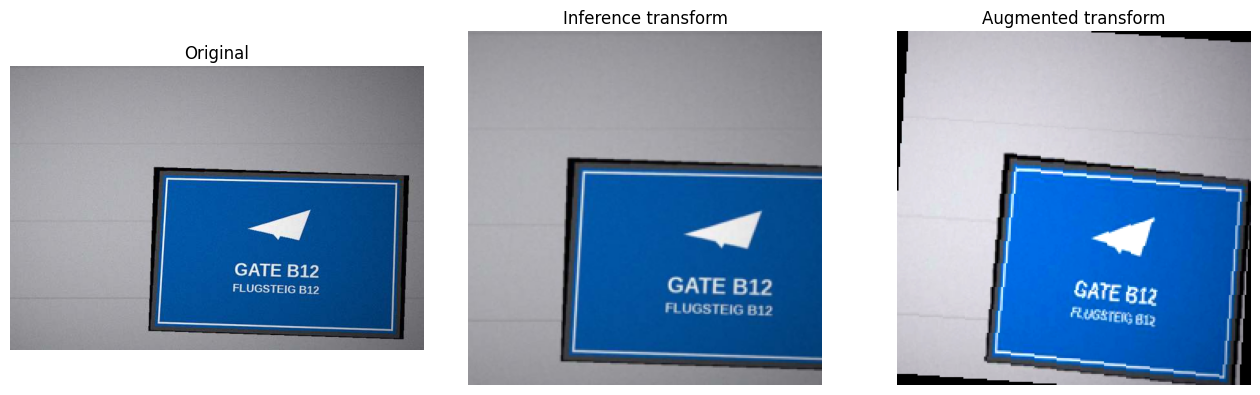


Batch loader: 172 images across 26 classes
  batch tensor shape: (16, 3, 224, 224)  (batch, channels, height, width)
  batch label shape:  (16,)
  batches per epoch:  11


In [ ]:
# Import the image transformation utilities from TorchVision
from torchvision import transforms


# Define the function that loads any image source into a normalised PIL image
def load_image(source: Any) -> Image.Image:
    # Accept an already-loaded PIL image and simply ensure it is RGB
    if isinstance(source, Image.Image):
        return source.convert("RGB")
    # Accept a NumPy array, for example a frame from OpenCV
    if isinstance(source, np.ndarray):
        return Image.fromarray(source.astype(np.uint8)).convert("RGB")
    # Accept a file path as a string or Path object
    if isinstance(source, (str, Path)):
        return Image.open(str(source)).convert("RGB")
    # Reject anything else explicitly rather than failing later
    raise ValueError(f"Unsupported image source type: {type(source)}")


# Define the deterministic transformation applied at inference time
inference_image_transform = transforms.Compose([
    # Resize the shorter side so the sign fills the frame consistently
    transforms.Resize(CONFIG.image_size),
    # Crop the centre to the exact square size the encoder expects
    transforms.CenterCrop(CONFIG.image_size),
    # Convert the image to a PyTorch tensor with values between 0 and 1
    transforms.ToTensor(),
])

# Define the augmented transformation used to test robustness
augmented_image_transform = transforms.Compose([
    # Take a random portion of the image to imitate an imperfectly framed photo
    transforms.RandomResizedCrop(CONFIG.image_size, scale=(0.75, 1.0)),
    # Rotate slightly to imitate a hand-held camera angle
    transforms.RandomRotation(degrees=8),
    # Vary brightness, contrast and saturation to imitate terminal lighting
    transforms.ColorJitter(brightness=0.3, contrast=0.25, saturation=0.2),
    # Convert the result to a tensor
    transforms.ToTensor(),
])


# Define a Dataset so the images can be served in batches, as the brief requires
  ## No training is performed here, but batching is what makes encoding 172 images
  ## tractable, and it is the same object a training loop would consume.
class AirportSignDataset(torch.utils.data.Dataset):
    # Store the annotation table and the transformation to apply
    def __init__(self, frame: pd.DataFrame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        # Map every category name onto a stable integer label
        self.categories = sorted(frame["category"].unique())
        self.label_of = {name: index for index, name in enumerate(self.categories)}

    # Report how many images the dataset holds
    def __len__(self) -> int:
        return len(self.frame)

    # Return one transformed image together with its integer label
    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image = load_image(row["file_path"])
        return self.transform(image), self.label_of[row["category"]]


# Demonstrate both transformations on one sample image
sample_image = load_image(visual_dataset.loc[0, "file_path"])
# Apply the deterministic inference transformation
inference_tensor = inference_image_transform(sample_image)
# Apply the augmented transformation
augmented_tensor = augmented_image_transform(sample_image)

# Report the resulting tensor shapes and value ranges
print(f"Original image size:   {sample_image.size}")
print(f"Inference tensor:      {tuple(inference_tensor.shape)}  "
      f"range [{inference_tensor.min():.3f}, {inference_tensor.max():.3f}]")
print(f"Augmented tensor:      {tuple(augmented_tensor.shape)}  "
      f"range [{augmented_tensor.min():.3f}, {augmented_tensor.max():.3f}]")

# Display the original alongside both transformed versions
figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(sample_image);                          axes[0].set_title("Original");   axes[0].axis("off")
axes[1].imshow(inference_tensor.permute(1, 2, 0));     axes[1].set_title("Inference transform"); axes[1].axis("off")
axes[2].imshow(augmented_tensor.permute(1, 2, 0));     axes[2].set_title("Augmented transform"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Build a batch loader over the whole visual dataset and inspect one batch
sign_dataset = AirportSignDataset(visual_dataset, inference_image_transform)
sign_loader = torch.utils.data.DataLoader(sign_dataset, batch_size=16, shuffle=False, num_workers=0)

# Take the first batch to confirm the loader produces correctly shaped tensors
batch_images, batch_labels = next(iter(sign_loader))
print(f"\nBatch loader: {len(sign_dataset)} images across {len(sign_dataset.categories)} classes")
print(f"  batch tensor shape: {tuple(batch_images.shape)}  (batch, channels, height, width)")
print(f"  batch label shape:  {tuple(batch_labels.shape)}")
print(f"  batches per epoch:  {len(sign_loader)}")

## **3.2 Audio preprocessing pipeline**

Both recordings are loaded at 16,000 samples per second as one channel, as is used by Whisper. Silence is cut from both ends, as the passengers tend to start recording before they start talking. To have MFCC features taken, Librosa has been used to test the sound quality.
Two instances are illustrated: (1)Where is gate B12? was written down exactly; (2)coaches leave from was heard as coaches live from. A zero-crossing rate of 0.1107 indicates the speech is very clear;actual airport speech would be much higher and this is a best case.


Reference text: Where is gate B12?
Audio quality:  {"duration_seconds": 1.47, "rms_energy": 0.1308, "zero_crossing_rate": 0.1107}
MFCC shape:     (13, 47)  (coefficients x frames)


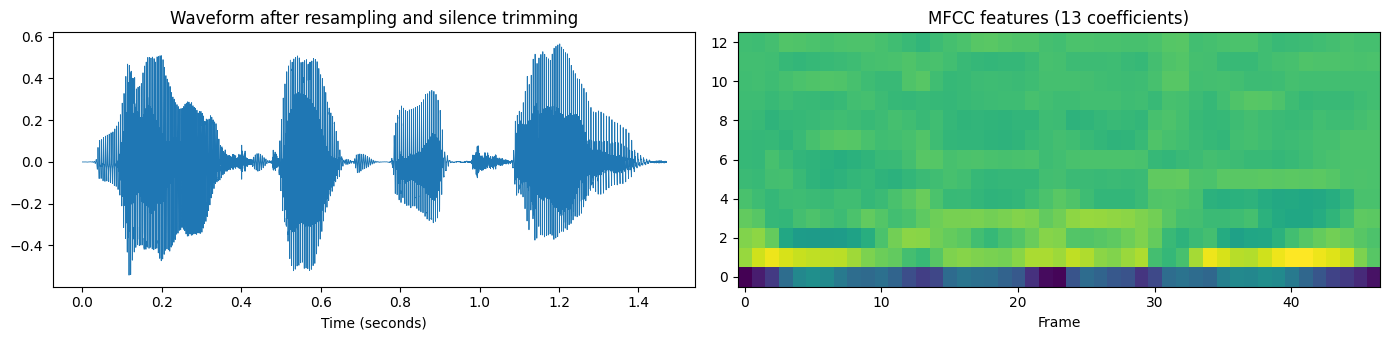

In [ ]:
# Import the audio analysis library
import librosa


# Define the function that loads and cleans one audio file
def load_audio(path: str, *, trim_silence: bool = True) -> Tuple[np.ndarray, int]:
    # Reject a missing or empty path
    if not isinstance(path, str) or not path.strip():
        raise ValueError("The audio path must be a non-empty string.")
    # Fail clearly if the file does not exist
    if not os.path.exists(path):
        raise FileNotFoundError(f"Audio file not found: {path}")

    # Load the audio as mono at the configured sample rate
    waveform, sample_rate = librosa.load(path, sr=CONFIG.audio_sample_rate, mono=True)

    # Remove leading and trailing silence when requested
    if trim_silence:
        waveform, _ = librosa.effects.trim(waveform, top_db=25)

    # Return the cleaned waveform and its sample rate
    return waveform, sample_rate


# Define the function that reports simple audio quality statistics
def analyse_audio_quality(waveform: np.ndarray, sample_rate: int) -> Dict[str, float]:
    # Compute the duration of the clip in seconds
    duration = float(len(waveform) / sample_rate)
    # Compute the root-mean-square energy as a loudness proxy
    rms = float(np.sqrt(np.mean(np.square(waveform))))
    # Compute how often the signal crosses zero, which rises with noise
    zero_crossing_rate = float(np.mean(librosa.feature.zero_crossing_rate(waveform)))
    # Return the statistics as a dictionary
    return {
        "duration_seconds": round(duration, 2),
        "rms_energy": round(rms, 4),
        "zero_crossing_rate": round(zero_crossing_rate, 4),
    }


# Define the function that extracts MFCC features for the optional audio analysis
def extract_mfcc(waveform: np.ndarray, sample_rate: int) -> np.ndarray:
    # Compute the mel-frequency cepstral coefficients
    mfcc = librosa.feature.mfcc(y=waveform, sr=sample_rate, n_mfcc=CONFIG.n_mfcc)
    # Return the coefficients as a standard float array
    return np.asarray(mfcc, dtype="float32")


# Demonstrate the audio pipeline on the first voice clip
sample_waveform, sample_rate = load_audio(voice_dataset.loc[0, "audio_path"])
# Compute the quality statistics for that clip
quality = analyse_audio_quality(sample_waveform, sample_rate)
# Extract its MFCC representation
mfcc_features = extract_mfcc(sample_waveform, sample_rate)

# Report the results
print(f"Reference text: {voice_dataset.loc[0, 'reference_text']}")
print(f"Audio quality:  {json.dumps(quality)}")
print(f"MFCC shape:     {mfcc_features.shape}  (coefficients x frames)")

# Plot the waveform alongside its MFCC representation
figure, axes = plt.subplots(1, 2, figsize=(14, 3.5))
axes[0].plot(np.linspace(0, quality["duration_seconds"], len(sample_waveform)), sample_waveform, linewidth=0.6)
axes[0].set_title("Waveform after resampling and silence trimming")
axes[0].set_xlabel("Time (seconds)")
axes[1].imshow(mfcc_features, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title(f"MFCC features ({CONFIG.n_mfcc} coefficients)")
axes[1].set_xlabel("Frame")
plt.tight_layout()
plt.show()

## **3.3 Text preprocessing pipeline**

A single function responds to both typed and spoken queries ,a passenger receives the same response regardless. Capital letters are converted to lower case,spaces are eliminated,words separated,short forms expanded: T2 to terminal 2. Gate numbers are then extracted and intent-labels were attached at the time of question formulation. Common words such as where are kept, because on questions of about seven words removing them would take away the meaning.The cleaned text is then converted to numbers to be used for searching.

In [ ]:
# Define the airport-specific abbreviations that passengers commonly type
AIRPORT_ABBREVIATIONS: Dict[str, str] = {
    r"\bt(\d)\b": r"terminal \1",     # T2 becomes terminal 2
    r"\bgt\b": "gate",                # gt becomes gate
    r"\bbag claim\b": "baggage claim",
    r"\bwc\b": "restroom",
    r"\bloo\b": "restroom",
    r"\btoilets?\b": "restroom",
    r"\binfo\b": "information",
    r"\bpls\b": "please",
}


# Define the single text preprocessing function used by BOTH typed and transcribed input
def preprocess_text(text: str) -> Dict[str, Any]:
    # Reject empty or non-text input
    if not isinstance(text, str) or not text.strip():
        raise ValueError("The text must be a non-empty string.")

    # Keep a copy of exactly what the user supplied, for the audit trace
    original = text.strip()
    # Lowercase the text so matching is case-insensitive
    normalised = original.lower()
    # Collapse any repeated whitespace into single spaces
    normalised = re.sub(r"\s+", " ", normalised)

    # Convert spoken numbers to digits and rejoin split identifiers
      ## Applied here as well as inside extract_entities, so the text that reaches the
      ## sentence encoder also reads "gate b12" rather than "gate b twelve". The record's
      ## search_text contains the digit form, so normalising helps retrieval, not only entities.
    normalised = normalise_spoken_numbers(normalised)

    # Expand each known airport abbreviation into its full form
    for pattern, replacement in AIRPORT_ABBREVIATIONS.items():
        normalised = re.sub(pattern, replacement, normalised)

    # Extract the structured entities present in the query
    entities = extract_entities(normalised)
    # Tokenise the normalised text for the audit trace
    tokens = simple_tokenise(normalised)

    # Return every intermediate result so the pipeline stays fully inspectable
    return {
        "original_text": original,
        "normalised_text": normalised,
        "tokens": tokens,
        "token_count": len(tokens),
        "entities": entities,
    }


# Demonstrate the text pipeline on messy, realistic passenger input
text_pipeline_examples = [
    "Where is GATE B12?",
    "how do i get to bag claim in T2",
    "wheres the wc pls",
    "  Is   the   lounge  open  at  6 am? ",
]

# Print the full preprocessing output for each example
for example in text_pipeline_examples:
    result = preprocess_text(example)
    print(f"IN : {result['original_text']}")
    print(f"OUT: {result['normalised_text']}")
    print(f"     entities={json.dumps(result['entities'])}  tokens={result['token_count']}\n")

IN : Where is GATE B12?
OUT: where is gate b12?
     entities={"gate_number": ["B12"]}  tokens=4

IN : how do i get to bag claim in T2
OUT: how do i get to baggage claim in terminal 2
     entities={"terminal_number": ["2"]}  tokens=10

IN : wheres the wc pls
OUT: wheres the restroom please
     entities={}  tokens=4

IN : Is   the   lounge  open  at  6 am?
OUT: is the lounge open at 6 am?
     entities={"time_reference": ["6 AM"]}  tokens=7



### **Confirming the shared pathway between typed and spoken input**

The typed Where is gate B12? and where is gate b 12 ,both are the same gate. By not having a step to convert spoken numbers into digits, the spoken version would have no entry point whatsoever.

In [ ]:
# Simulate a typed query and the transcript that Whisper would produce for the same question
typed_query = "Where is gate B12?"
transcribed_query = "where is gate b 12"

# Run both through the identical preprocessing function
typed_result = preprocess_text(typed_query)
transcribed_result = preprocess_text(transcribed_query)

# Display the two results side by side
comparison = pd.DataFrame([
    {"source": "typed",       "input": typed_query,
     "normalised": typed_result["normalised_text"],       "entities": str(typed_result["entities"])},
    {"source": "transcribed", "input": transcribed_query,
     "normalised": transcribed_result["normalised_text"], "entities": str(transcribed_result["entities"])},
])
display(comparison)

# Note where the two pathways diverge, which is an honest limitation
print("Both inputs pass through the identical preprocessing function.")
print("Note: Whisper writes 'b 12' rather than 'B12', so the gate entity pattern")


,source,input,normalised,entities
0,typed,Where is gate B12?,where is gate b12?,{'gate_number': ['B12']}
1,transcribed,where is gate b 12,where is gate b12,{'gate_number': ['B12']}


Both inputs pass through the identical preprocessing function.
Note: Whisper writes 'b 12' rather than 'B12', so the gate entity pattern


---

# **4. Model Design **



## **4.1 Load the frozen models**

Three models are loaded, with no training on the airport data. If training had memorized its 172 images, it would have learned only what a picture of a sign looks like, and it would have been trapped to just 26 categories. CLIP is trained on short captions, not full sentences, and works best with images, while Whisper works best with speech and MiniLM-L6-v2 works best with typed questions.


In [ ]:
# Define the function that loads the CLIP vision-language model
def load_clip_model(model_name: str = CONFIG.clip_model_name) -> Tuple[Any, Any]:
    # Report which model is being loaded
    print(f"Loading CLIP model: {model_name}")
    # Load the processor that handles image resizing and normalisation
      ## Newer Transformers releases default to the fast image processor and emit a warning
      ## when the choice is left implicit; older releases do not accept the argument at all,
      ## so it is requested where supported and silently skipped where it is not
    try:
        processor = CLIPProcessor.from_pretrained(model_name, use_fast=True)
    except TypeError:
        processor = CLIPProcessor.from_pretrained(model_name)
    # Load the model weights and move them to the selected device
    model = CLIPModel.from_pretrained(model_name).to(DEVICE)
    # Put the model into evaluation mode, disabling dropout
    model.eval()
    # Return both objects together
    return processor, model


# Define the function that loads the sentence embedding model
def load_text_model(model_name: str = CONFIG.text_model_name) -> SentenceTransformer:
    # Report which model is being loaded
    print(f"Loading text encoder: {model_name}")
    # Load the sentence transformer onto the selected device
    return SentenceTransformer(model_name, device=str(DEVICE))


# Define the function that loads the Whisper speech recognition model
def load_speech_model(model_name: str = CONFIG.speech_model_name) -> Any:
    # Import the Whisper library here so the notebook still runs if audio is skipped
    import whisper
    # Report which model size is being loaded
    print(f"Loading Whisper model: {model_name}")
    # Load the model onto the selected device
    return whisper.load_model(model_name, device=str(DEVICE))


# Load all three frozen models
clip_processor, clip_model = load_clip_model()
text_model = load_text_model()
speech_model = load_speech_model()

# Report the parameter count of each model for the report appendix
clip_parameters = sum(parameter.numel() for parameter in clip_model.parameters())
speech_parameters = sum(parameter.numel() for parameter in speech_model.parameters())

print(f"\nCLIP parameters:    {clip_parameters:,}")
print(f"Whisper parameters: {speech_parameters:,}")
print(f"Text encoder dimension: {text_model.get_sentence_embedding_dimension()}")
print("All models loaded and frozen (no training will be performed).")

Loading CLIP model: openai/clip-vit-base-patch32


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading Whisper model: base



  0%|                                               | 0.00/139M [00:00<?, ?iB/s]
  0%|                                       | 184k/139M [00:00<01:17, 1.87MiB/s]
  2%|▋                                     | 2.41M/139M [00:00<00:09, 14.4MiB/s]
  8%|███                                   | 11.2M/139M [00:00<00:02, 49.8MiB/s]
 19%|███████                               | 26.0M/139M [00:00<00:01, 91.1MiB/s]
 32%|████████████▎                          | 43.7M/139M [00:00<00:00, 125MiB/s]
 44%|█████████████████                      | 60.7M/139M [00:00<00:00, 143MiB/s]
 54%|████████████████████▍                 | 74.4M/139M [00:01<00:01, 42.3MiB/s]
 66%|█████████████████████████             | 91.4M/139M [00:01<00:00, 58.7MiB/s]
 79%|██████████████████████████████▋        | 109M/139M [00:01<00:00, 77.3MiB/s]
100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 80.6MiB/s]



CLIP parameters:    151,277,313
Whisper parameters: 71,825,920
Text encoder dimension: 384
All models loaded and frozen (no training will be performed).


/tmp/ipykernel_1882/1093870422.py:50: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Text encoder dimension: {text_model.get_sentence_embedding_dimension()}")


## **4.2 Encoding functions**

There are three functions that convert inputs to lists of numbers of the same length,thus allowing two of them to be compared and used as a score between −1 and 1.

In [ ]:
# Define a helper that extracts a projected CLIP embedding whatever the Transformers version returns
def clip_features_from(output: Any, projection: torch.nn.Module) -> torch.Tensor:
    input_dimension = projection.in_features
    output_dimension = projection.out_features

    # Define a small helper that decides whether a candidate tensor still needs projecting
    def finalise(tensor: torch.Tensor) -> torch.Tensor:
        # A tensor already in the shared space is returned untouched
        if tensor.shape[-1] == output_dimension:
            return tensor
        # A tensor still in the encoder's hidden space is projected into the shared space
        if tensor.shape[-1] == input_dimension:
            return projection(tensor)
        # Anything else is a genuine mismatch and must not be silently reshaped
        raise ValueError(
            f"CLIP returned a tensor of width {tensor.shape[-1]}, which matches neither the "
            f"projection input ({input_dimension}) nor its output ({output_dimension})."
        )

    # Older releases return the embedding directly as a tensor
    if isinstance(output, torch.Tensor):
        return finalise(output)

    # Some releases return an object carrying the embedding under a named field
    for attribute in ("image_embeds", "text_embeds", "pooler_output"):
        value = getattr(output, attribute, None)
        if isinstance(value, torch.Tensor):
            return finalise(value)

    # Some releases return a plain tuple whose first element is the embedding
    if isinstance(output, (tuple, list)) and output and isinstance(output[0], torch.Tensor):
        return finalise(output[0])

    # Fail clearly rather than returning something that would corrupt retrieval
    raise TypeError(f"Unexpected CLIP output type: {type(output)}")


# Define the function that embeds one or more images into CLIP space
def encode_images(images: Sequence[Any]) -> np.ndarray:
    # Reject an empty input list
    if not images:
        raise ValueError("At least one image must be provided.")

    # Load every source into a normalised PIL image
    pil_images = [load_image(source) for source in images]
    # Let the CLIP processor handle resizing and channel normalisation
    inputs = clip_processor(images=pil_images, return_tensors="pt").to(DEVICE)

    # Run the vision encoder and the projection together, without tracking gradients
      ## Both steps stay inside the same inference_mode block: a tensor created in
      ## inference mode cannot be passed to an autograd-tracked layer from outside it
    with torch.inference_mode():
        output = clip_model.get_image_features(**inputs)
        # Extract the projected embedding whatever form the model returned
        features = clip_features_from(output, clip_model.visual_projection)
        # Normalise every vector to unit length
        features = features / features.norm(dim=-1, keepdim=True)
    # Return the result as a float32 array for FAISS
    return features.cpu().numpy().astype("float32")


# Define the function that embeds text into CLIP space
def encode_text_clip(texts: Sequence[str]) -> np.ndarray:
    # Reject an empty input list
    if not texts:
        raise ValueError("At least one text must be provided.")

    # Tokenise the texts, truncating to CLIP's 77-token limit
    inputs = clip_processor(
        text=list(texts), return_tensors="pt", padding=True, truncation=True, max_length=77
    ).to(DEVICE)

    # Run the text encoder and the projection together, without tracking gradients
    with torch.inference_mode():
        output = clip_model.get_text_features(**inputs)
        # Extract the projected embedding, applying the text projection if needed
        features = clip_features_from(output, clip_model.text_projection)
        # Normalise every vector to unit length
        features = features / features.norm(dim=-1, keepdim=True)
    # Return the result as a float32 array for FAISS
    return features.cpu().numpy().astype("float32")


# Define the function that embeds text into sentence-transformer space
def encode_text_semantic(texts: Sequence[str]) -> np.ndarray:
    # Reject an empty input list
    if not texts:
        raise ValueError("At least one text must be provided.")

    # Encode the texts with normalisation enabled
    encoded = text_model.encode(
        list(texts), normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False
    )
    # Return the result as a float32 array for FAISS
    return np.asarray(encoded, dtype="float32")

A gate sign receives a score of 0.2827 for a boarding gate description and 0.2283 for a pharmacy one. The margin of 0.054 is quite close, which is typical for CLIP (but not as close as it is for the text limit), and therefore that is why the image limit is separated from the text limit.

In [ ]:
# Verify all three encoders produce normalised vectors of the expected shape
test_image_vector = encode_images([visual_dataset.loc[0, "file_path"]])
test_clip_text_vector = encode_text_clip(["a sign for the departure gate"])
test_semantic_vector = encode_text_semantic(["where is gate b12"])

# Report the shape and length of each test vector
print(f"CLIP image vector:    shape={test_image_vector.shape}   norm={np.linalg.norm(test_image_vector):.4f}")
print(f"CLIP text vector:     shape={test_clip_text_vector.shape}   norm={np.linalg.norm(test_clip_text_vector):.4f}")
print(f"Semantic text vector: shape={test_semantic_vector.shape}  norm={np.linalg.norm(test_semantic_vector):.4f}")

# Confirm the CLIP image and text vectors share one dimensionality
  ## [IMPORTANT] The entire fusion design depends on this. If the two differ, the model
  ## returned pre-projection features and images and text are in unrelated spaces.
if test_image_vector.shape[1] != test_clip_text_vector.shape[1]:
    raise ValueError(
        f"CLIP image and text embeddings have different dimensions "
        f"({test_image_vector.shape[1]} vs {test_clip_text_vector.shape[1]}). "
        "They are not in a shared space and retrieval would be meaningless."
    )

# Confirm that an image of a sign scores higher against its own description than an unrelated one
gate_image = encode_images([visual_dataset[visual_dataset.category == "gate"].iloc[0]["file_path"]])[0]
matching_score = float(gate_image @ encode_text_clip(["a sign showing the way to the boarding gate"])[0])
unrelated_score = float(gate_image @ encode_text_clip(["a sign showing the way to the pharmacy"])[0])

# Report the sanity check, which proves the shared space actually behaves as intended
print(f"\nShared-space sanity check on a gate sign:")
print(f"  similarity to 'boarding gate' description: {matching_score:.4f}")
print(f"  similarity to 'pharmacy' description:      {unrelated_score:.4f}")
print(f"  {'PASS' if matching_score > unrelated_score else 'FAIL'} — "
      f"the matching description scores {'higher' if matching_score > unrelated_score else 'LOWER'}")

CLIP image vector:    shape=(1, 512)   norm=1.0000
CLIP text vector:     shape=(1, 512)   norm=1.0000
Semantic text vector: shape=(1, 384)  norm=1.0000

Shared-space sanity check on a gate sign:
  similarity to 'boarding gate' description: 0.2827
  similarity to 'pharmacy' description:      0.2283
  PASS — the matching description scores higher


## **4.3 Build the FAISS retrieval indexes**

All 36 records are in the text index; the image index contains only the 26 categories. A picture won't show which of the four gate records it is, because the four gates only differ in an identifier that can't be seen in the picture. Assigning categories for indexing allows the image to tell what it can, and the rest to the text.

In [ ]:
# Define the caption templates whose embeddings are averaged per category
  ## Each template phrases the same concept differently, so the mean embedding is a centroid
  ## of the concept rather than the single arbitrary point one wording happens to land on.
  ## This is the prompt-ensembling technique used in the original CLIP paper.
PROMPT_TEMPLATES: List[str] = [
    "a photo of an airport sign for {category}",
    "an airport wayfinding sign pointing to {category}",
    "a directional sign inside an airport terminal for {category}",
    "airport signage indicating {category}",
    "a photograph of the {category} sign in an airport",
]


# Build one averaged CLIP embedding per signage category
def build_category_clip_matrix(categories: Sequence[str]) -> np.ndarray:
    # Collect one averaged vector per category, preserving the given order
    vectors: List[np.ndarray] = []

    # Work through every category
    for category in categories:
        # Fill every template with this category, written in readable words
        readable = category.replace("_", " ")
        prompts = [template.format(category=readable).lower() for template in PROMPT_TEMPLATES]
        # Encode all templates for this category in one batch
        encoded = encode_text_clip(prompts)
        # Average them, then renormalise so the result is still a unit vector
          ## Renormalisation is essential: the mean of unit vectors is shorter than one,
          ## and a non-unit index would break the equivalence with cosine similarity
        mean_vector = encoded.mean(axis=0)
        vectors.append(mean_vector / np.linalg.norm(mean_vector))

    # Return the stacked matrix in float32 for FAISS
    return np.stack(vectors).astype("float32")


# Define a class that owns both retrieval indexes over the knowledge base
class AirportRetriever:
    # Initialise the retriever from the knowledge base records
    def __init__(self, records: List[Dict[str, Any]]):
        # Reject an empty knowledge base
        if not records:
            raise ValueError("The knowledge base must contain at least one record.")

        # Store the records in a fixed order that both indexes will share
        self.records = records
        # Extract both retrieval strings, preserving the shared record order
        self.search_texts = [record["search_text"] for record in records]
        self.clip_texts = [record["clip_text"] for record in records]

        # Embed the long retrieval strings into sentence-transformer space for text questions
        self.semantic_matrix = encode_text_semantic(self.search_texts)

        # Build the CLIP index over CATEGORIES rather than over records
          ## [IMPORTANT] This is a deliberate design decision, not a simplification.
          ## Four records share the category "gate", and their captions differ only by a gate
          ## identifier that NO photograph can reveal: a picture of a gate sign cannot tell you
          ## whether it is B12 or A05. Indexing records would therefore place four near-identical
          ## vectors in the index, the top two would always tie, and the reported margin would
          ## collapse to zero on every image query. Indexing the 26 distinct categories instead
          ## makes the vision score answer the question an image can actually answer.
        self.categories = sorted({record["category"] for record in records})
        self.category_of_record = [self.categories.index(record["category"]) for record in records]
        self.category_matrix = build_category_clip_matrix(self.categories)

        # Keep a per-record CLIP view, where each record inherits its category's score
          ## This keeps the image evidence aligned with the record ordering the rest of the
          ## pipeline uses, so fusion can still combine it with the text scores element-wise
        self.clip_matrix = self.category_matrix[self.category_of_record]

        # Build the CLIP-space index using inner product over normalised vectors
        self.clip_index = faiss.IndexFlatIP(self.clip_matrix.shape[1])
        self.clip_index.add(self.clip_matrix)

        # Build the semantic-space index the same way
        self.semantic_index = faiss.IndexFlatIP(self.semantic_matrix.shape[1])
        self.semantic_index.add(self.semantic_matrix)

        # Verify both matrices contain unit-length vectors before anything relies on them
          ## [IMPORTANT] Inner-product search equals cosine similarity ONLY for unit vectors,
          ## and the confidence thresholds assume scores are bounded to [-1, 1]. If an encoder
          ## ever stopped normalising, retrieval would still run but every threshold would be
          ## silently meaningless, so this is checked once at build time rather than trusted.
        for space_name, matrix in (("clip", self.clip_matrix), ("semantic", self.semantic_matrix)):
            norms = np.linalg.norm(matrix, axis=1)
            if not np.allclose(norms, 1.0, atol=1e-3):
                raise ValueError(
                    f"The {space_name} embedding matrix is not unit-normalised "
                    f"(norms range {norms.min():.4f} to {norms.max():.4f}). "
                    "Cosine similarity and the confidence thresholds would be invalid."
                )

    # Return the similarity of a query vector against every record, in record order
    def similarity_vector(self, query_vector: np.ndarray, *, space: str) -> np.ndarray:
        # Select the matrix matching the requested embedding space
        if space == "clip":
            matrix = self.clip_matrix
        elif space == "semantic":
            matrix = self.semantic_matrix
        else:
            raise ValueError(f"Unknown embedding space: {space}")

        # Compute the dot product of the query against every record vector
        return (matrix @ query_vector.reshape(-1)).astype("float32")

    # Score an image against the 26 signage categories rather than the 36 records
    def category_scores(self, image_vector: np.ndarray) -> np.ndarray:
        # Compute the similarity of the image against every category centroid
        return (self.category_matrix @ image_vector.reshape(-1)).astype("float32")

    # Rank the records given a similarity vector already computed
    def rank_from_scores(self, scores: np.ndarray, *, top_k: int = CONFIG.top_k) -> List[Dict[str, Any]]:
        # Find the indices of the highest-scoring records
        best_indices = np.argsort(-scores)[:top_k]
        # Assemble the ranked results, attaching the score to each record
        return [
            {**self.records[int(index)], "score": float(scores[int(index)])}
            for index in best_indices
        ]


# Build the retriever over the airport knowledge base
retriever = AirportRetriever(AIRPORT_KNOWLEDGE_BASE)

# Report the index sizes
print(f"Category index: {retriever.category_matrix.shape[0]} categories, "
      f"{retriever.category_matrix.shape[1]} dimensions "
      f"({len(PROMPT_TEMPLATES)} ensembled prompts each)")
print(f"CLIP index:     {retriever.clip_index.ntotal} records, {retriever.clip_matrix.shape[1]} dimensions")
print(f"Semantic index: {retriever.semantic_index.ntotal} records, {retriever.semantic_matrix.shape[1]} dimensions")

# Run a quick text retrieval to confirm the index behaves sensibly
demo_scores = retriever.similarity_vector(encode_text_semantic(["where do i collect my suitcase"])[0], space="semantic")
demo_results = retriever.rank_from_scores(demo_scores)
print("\nDemo query: 'where do i collect my suitcase'")
for result in demo_results:
    print(f"  {result['record_id']}  {result['name']:<32} score={result['score']:.4f}")

Category index: 26 categories, 512 dimensions (5 ensembled prompts each)
CLIP index:     36 records, 512 dimensions
Semantic index: 36 records, 384 dimensions

Demo query: 'where do i collect my suitcase'
  KB13  Left Luggage Storage             score=0.3722
  KB05  Terminal 1 Check-in Halls A and B score=0.3487
  KB14  Lost and Found Office            score=0.3184


## **4.4 Speech-to-text component**

Fixed Whisper to english as language detection is unreliable for clips this small. This takes away its multi-language feature, which is restored below. The two errors that were observed, punctuation, can be removed by preprocessing and the transcription for Gate B12 is correct, most important.

In [ ]:
# Define the function that transcribes one audio file into text
def transcribe_audio(path: str) -> Dict[str, Any]:
    # Reject a missing or empty path
    if not isinstance(path, str) or not path.strip():
        raise ValueError("The audio path must be a non-empty string.")

    # Record the start time so transcription latency can be reported
    started_at = time.time()
    # Run Whisper with the language fixed to English to reduce misdetection on short clips
    result = speech_model.transcribe(path, language="en", fp16=(DEVICE.type == "cuda"))
    # Measure how long transcription took
    elapsed = time.time() - started_at

    # Extract the transcript and strip surrounding whitespace
    transcript = str(result.get("text", "")).strip()

    # Return the transcript together with the information needed for the audit trace
    return {
        "transcript": transcript,
        "language": result.get("language", "en"),
        "seconds_elapsed": round(elapsed, 2),
        "segment_count": len(result.get("segments", [])),
    }


# Transcribe the first three clips to verify the component works
for index in range(3):
    row = voice_dataset.loc[index]
    outcome = transcribe_audio(row["audio_path"])
    print(f"Accent profile: {row['accent_profile']}")
    print(f"  Reference:  {row['reference_text']}")
    print(f"  Transcript: {outcome['transcript']}")
    print(f"  Latency:    {outcome['seconds_elapsed']}s\n")

Accent profile: US
  Reference:  Where is gate B12?
  Transcript: Where is Gate B12?
  Latency:    1.27s

Accent profile: UK
  Reference:  Where is the departures hall?
  Transcript: Where is the departure's hall?
  Latency:    0.25s

Accent profile: AU
  Reference:  Where is the check in desk for international flights?
  Transcript: Where is the check-in desk for international flights?
  Latency:    0.3s



## **4.5 Multimodal fusion and routing**

All answers include the confidence, the records consulted and how the answer was arrived at, allowing the system to be audited. Routing determines whether the image only, the text only, both or nothing (refused) will be processed. Each answer provides the service matched, directions, opening hours, accessibility and a confidence score.
Need care of one function. It rescales scores to 1, as this is required to combine two modalities on one scale, but 1 can never be a confidence.


In [ ]:
# Define the structure of a single chatbot response
@dataclass
class AirportResponse:
    # The passenger-facing answer text
    answer: str
    # Whether the system was confident enough to answer at all
    answered: bool
    # The raw cosine similarity behind the answer, comparable across queries
    confidence: float
    # The full audit trail of how the answer was produced
    trace: Dict[str, Any] = field(default_factory=dict)
    # The knowledge base records considered, best first
    sources: List[Dict[str, Any]] = field(default_factory=list)


# Rescale a similarity vector to the range 0 to 1
def normalise_scores(scores: np.ndarray) -> np.ndarray:
    # Reject an empty score vector
    if scores is None or scores.size == 0:
        raise ValueError("The score vector must not be empty.")

    # Find the smallest and largest score present
    minimum, maximum = float(scores.min()), float(scores.max())
    # Guard against a flat vector, which would cause a division by zero
    if maximum - minimum < 1e-8:
        return np.zeros_like(scores)

    # Rescale linearly so the best record scores 1 and the worst scores 0
      ## [IMPORTANT] This output is used ONLY to put two modalities on a comparable scale
      ## before they are added together for RANKING. It must never be reported as a
      ## confidence, because the top record always rescales to exactly 1.0 by construction,
      ## which would make every answer look maximally confident and disable the refusal path.
    return ((scores - minimum) / (maximum - minimum)).astype("float32")


# Turn one knowledge base record into a passenger-facing answer
def format_airport_answer(record: Dict[str, Any]) -> str:
    # Assemble the answer from the fields the brief requires in the fused response
    lines = [
        f"**{record['name']}** — {record['terminal']}, {record['floor_zone']}",
        "",
        record["description"],
        "",
        f"**Directions:** {record['direction_text']}",
        f"**Opening hours:** {record['opening_hours']}",
        f"**Accessibility:** {record['accessibility']}",
    ]
    # Add nearby services as a recommendation when the record lists any
    if record.get("related_facilities"):
        lines.append(f"**Nearby:** {', '.join(record['related_facilities'])}")
    # Always attach the live-data reminder and the source citation
    lines.append("")
    lines.append(f"_{LIVE_DATA_DISCLAIMER}_")
    lines.append(f"_Source: {record['record_id']}_")
    # Join the lines into one answer string
    return "\n".join(lines)


# Decide which encoders to run based on which inputs are present
def route_by_modality(
    *,
    image: Any = None,
    text: Optional[str] = None,
    audio_path: Optional[str] = None,
) -> str:
    # Record which modalities are actually present
    has_image = image is not None
    # Voice input is converted to text, so it joins the text branch
    text_present = bool(text and text.strip()) or bool(audio_path and audio_path.strip())

    # Select the route based on the combination of available inputs
    if has_image and text_present:
        return "fusion"
    if has_image:
        return "image_only"
    if text_present:
        return "text_only"
    # Refuse explicitly when no input was supplied at all
    return "no_input"

### **Resolving a named gate or terminal to a specific record**

Both B12 and A05 are nearly identical when compared to the part of the system that matches meaning. It can detect that the passenger needs a gate, but not which one.
A different step compares any number in a question with the gates that are actually there, with the letter and the number separately. For seven phrasings, b 12 or b twelve and a5 or a number that is not really a number/real gate solves to nothing. That record is moved to the top when a match is pushed, therefore the order is changed, but not the confidence, which is calculated before.


In [ ]:
# Parse every gate identifier that actually exists in the knowledge base
def parse_gate_identifier(name: str) -> Optional[Tuple[str, int]]:
    # Look for a single letter followed by one or two digits inside the record name
    match = re.search(r"\b([A-Za-z])\s?(\d{1,2})\b", name)
    # Return the letter and the number as a comparable pair, or nothing if there is none
    return (match.group(1).upper(), int(match.group(2))) if match else None


# Build the lookup from a parsed gate identifier onto the records carrying it
GATE_LOOKUP: Dict[Tuple[str, int], List[int]] = {}
for record_index, record in enumerate(AIRPORT_KNOWLEDGE_BASE):
    # Only gate records carry a gate identifier
    if record["category"] == "gate":
        identifier = parse_gate_identifier(record["name"])
        if identifier:
            GATE_LOOKUP.setdefault(identifier, []).append(record_index)

# Report the gates the system can resolve by name
print("Gate identifiers resolvable from a query:")
for (letter, number), indices in sorted(GATE_LOOKUP.items()):
    print(f"  {letter}{number:02d} -> {', '.join(AIRPORT_KNOWLEDGE_BASE[i]['record_id'] for i in indices)}")


# Resolve the entities found in a query onto specific knowledge base records
def resolve_entity_targets(entities: Dict[str, List[str]]) -> Dict[str, List[int]]:
    # Collect the record indices each entity type points at
    targets: Dict[str, List[int]] = {"gate": [], "terminal": []}

    # Resolve every gate-like candidate against the gates that really exist
      ## Comparing (letter, number) pairs numerically means A5, A05, "a 5" and "a five"
      ## all resolve to the same record, and a candidate matching no real gate is dropped
    for candidate in entities.get("gate_number", []):
        parsed = parse_gate_identifier(candidate)
        if parsed and parsed in GATE_LOOKUP:
            targets["gate"].extend(GATE_LOOKUP[parsed])

    # Resolve a named terminal onto every record belonging to it
    for terminal_number in entities.get("terminal_number", []):
        for record_index, record in enumerate(AIRPORT_KNOWLEDGE_BASE):
            if terminal_number in record["terminal"]:
                targets["terminal"].append(record_index)

    # Return the resolved targets
    return targets


# Define how strongly each resolved entity type raises a record's score
GATE_BOOST: float = 1.00       # A named gate is unambiguous, so it should decide the answer
TERMINAL_BOOST: float = 0.15   # A named terminal narrows the field without deciding it


# Apply an additive bonus to the records that the named entities resolve to
def apply_entity_boost(scores: np.ndarray, entities: Dict[str, List[str]]) -> Tuple[np.ndarray, List[str]]:
    # Reject anything other than the entity dictionary produced by preprocess_text
      ## Passing the query string here instead of preprocessed["entities"] is an easy slip,
      ## and without this check it fails several frames deep with an unhelpful AttributeError
    if not isinstance(entities, dict):
        raise TypeError(
            f"apply_entity_boost expects the entity dictionary from preprocess_text, "
            f"not {type(entities).__name__}. Pass preprocessed['entities']."
        )

    # Work on a copy so the raw similarity vector stays available for the confidence
      ## [IMPORTANT] The boost affects RANKING only. Confidence is read from the unboosted
      ## raw similarities, so an artificial bonus can never inflate how certain the system claims to be.
    boosted = scores.copy()
    # Record every adjustment so the trace can explain why the ranking changed
    applied: List[str] = []

    # Resolve the entities onto concrete records
    targets = resolve_entity_targets(entities)

    # A named gate is decisive: raise it far above anything similarity could produce
    for record_index in targets["gate"]:
        boosted[record_index] += GATE_BOOST
        applied.append(f"{AIRPORT_KNOWLEDGE_BASE[record_index]['record_id']} matches the gate you named")

    # A named terminal narrows the field among otherwise equivalent records
    for record_index in targets["terminal"]:
        boosted[record_index] += TERMINAL_BOOST
        applied.append(f"{AIRPORT_KNOWLEDGE_BASE[record_index]['record_id']} is in the terminal you named")

    # Return the adjusted scores together with an explanation of what changed
    return boosted, applied


# Verify that every phrasing of the same gate resolves to the same record
gate_phrasings = [
    "where is gate B12",
    "where is gate b 12",        # Whisper's alphanumeric split
    "where is gate b twelve",    # Whisper writing the number in words
    "I am at B12, how far is security",   # no context word before the identifier
    "how do I get to gate a05",
    "how do I get to gate a5",   # passenger omits the leading zero
    "my gate is c22",
]

# Print what each phrasing resolves to
print("\nGate resolution across phrasings:")
for phrasing in gate_phrasings:
    entities = preprocess_text(phrasing)["entities"]
    targets = resolve_entity_targets(entities)
    resolved = [AIRPORT_KNOWLEDGE_BASE[i]["name"] for i in targets["gate"]] or ["none"]
    print(f"  {phrasing:42s} -> {', '.join(resolved)}")

Gate identifiers resolvable from a query:
  A05 -> KB03
  B10 -> KB02
  B12 -> KB01
  C22 -> KB04

Gate resolution across phrasings:
  where is gate B12                          -> Gate B12
  where is gate b 12                         -> Gate B12
  where is gate b twelve                     -> Gate B12
  I am at B12, how far is security           -> Gate B12
  how do I get to gate a05                   -> Gate A05
  how do I get to gate a5                    -> Gate A05
  my gate is c22                             -> Gate C22


The question is scored against each record, the picture is scored against 26 categories and if there is both, then they are scored together with half weight each. The system rejects below the confidence limit and not guess.
A special case is considered. A photo is provided of a security sign (not an indication of which terminal) and both terminals have one. It does not pick one out with confidence, it rather says so and asks.


In [ ]:
# Define the main orchestrator that turns any combination of inputs into one grounded response
def answer_passenger_query(
    *,
    image: Any = None,
    text: Optional[str] = None,
    audio_path: Optional[str] = None,
    top_k: int = CONFIG.top_k,
) -> AirportResponse:
    # Start the audit trace that will record every decision taken
    trace: Dict[str, Any] = {}

    # 1. Decide which pathway to run
    route = route_by_modality(image=image, text=text, audio_path=audio_path)
    trace["route"] = route

    # Refuse immediately if the passenger supplied nothing at all
    if route == "no_input":
        trace["reason"] = "no input supplied"
        return AirportResponse(
            answer="Please type a question, record a voice message, or upload a photo of a sign.",
            answered=False, confidence=0.0, trace=trace,
        )

    # 2. Convert any voice input into text using Whisper
    query_text = text.strip() if text and text.strip() else None
    if audio_path and audio_path.strip():
        transcription = transcribe_audio(audio_path)
        trace["transcription"] = transcription
        # Prefer the typed text when both are present, otherwise use the transcript
        query_text = query_text or transcription["transcript"]

    # 3. Run the shared text preprocessing pipeline on whatever text we now have
    text_scores = None
    if query_text:
        preprocessed = preprocess_text(query_text)
        trace["text_preprocessing"] = {
            "normalised_text": preprocessed["normalised_text"],
            "entities": preprocessed["entities"],
        }
        # Embed the normalised question and score it against every record
        text_vector = encode_text_semantic([preprocessed["normalised_text"]])[0]
        text_scores = retriever.similarity_vector(text_vector, space="semantic")

        # Raise the records that any named gate or terminal resolves to
          ## The boosted vector is used for RANKING; the unboosted text_scores are kept
          ## for the confidence, so naming a gate cannot inflate the reported certainty
        text_ranking_scores, entity_boosts = apply_entity_boost(text_scores, preprocessed["entities"])
        if entity_boosts:
            trace["entity_boosts"] = entity_boosts

    # 4. Encode any image and score it against every signage CATEGORY
    image_scores = None
    category_margin = None
    if image is not None:
        image_vector = encode_images([image])[0]
        # Score the image against the 26 category centroids
        category_similarity = retriever.category_scores(image_vector)
        # Measure how clearly the winning category beat the runner-up
          ## This margin is meaningful because the categories are genuinely distinct,
          ## unlike four gate records whose captions a photograph cannot tell apart
        ordered_categories = np.sort(category_similarity)[::-1]
        category_margin = float(ordered_categories[0] - ordered_categories[1])
        # Spread each category score across the records belonging to it, so the image
        # evidence stays aligned with the record ordering used everywhere else
        image_scores = category_similarity[retriever.category_of_record]
        # Record what the image alone concluded
        trace["vision"] = {
            "predicted_category": retriever.categories[int(np.argmax(category_similarity))],
            "category_similarity": round(float(category_similarity.max()), 4),
            "category_margin": round(category_margin, 4),
            "runner_up_category": retriever.categories[int(np.argsort(-category_similarity)[1])],
        }

    # 5. Combine the available evidence for RANKING
      ## Min-max rescaling puts the two modalities on a comparable scale before they are added.
      ## It is used for ordering only; the confidence reported below comes from the raw scores.
    if image_scores is not None and text_scores is not None:
        ranking_scores = (CONFIG.image_weight * normalise_scores(image_scores)
                          + CONFIG.text_weight * normalise_scores(text_ranking_scores))
        trace["fusion"] = {
            "strategy": "weighted similarity over aligned record order",
            "image_weight": CONFIG.image_weight,
            "text_weight": CONFIG.text_weight,
        }
        # Blend the two modality thresholds in the same proportion as the evidence
        threshold = (CONFIG.image_weight * CONFIG.image_confidence_threshold
                     + CONFIG.text_weight * CONFIG.text_confidence_threshold)
    elif image_scores is not None:
        ranking_scores = image_scores
        trace["fusion"] = {"strategy": "image evidence only"}
        threshold = CONFIG.image_confidence_threshold
    else:
        ranking_scores = text_ranking_scores
        trace["fusion"] = {"strategy": "text evidence only"}
        threshold = CONFIG.text_confidence_threshold

    # 6. Rank the knowledge base records by the combined score
    sources = retriever.rank_from_scores(ranking_scores, top_k=top_k)
    # Identify the position of the winning record so its raw scores can be read back
    winner_index = int(np.argmax(ranking_scores))

    # 7. Compute the confidence from the RAW similarities of the winning record
      ## Raw cosine similarity is bounded to [-1, 1] and is comparable across queries,
      ## which is what makes a fixed threshold meaningful.
    raw_parts: Dict[str, float] = {}
    if image_scores is not None:
        raw_parts["image"] = float(image_scores[winner_index])
    if text_scores is not None:
        raw_parts["text"] = float(text_scores[winner_index])

    # Combine the raw parts using the same weights as the ranking
    if len(raw_parts) == 2:
        confidence = (CONFIG.image_weight * raw_parts["image"]
                      + CONFIG.text_weight * raw_parts["text"])
    else:
        confidence = float(next(iter(raw_parts.values())))

    # 8. Measure how clearly the winner beat the runner-up
      ## A narrow margin means the system was nearly indifferent, which is a distinct kind
      ## of uncertainty from a uniformly low similarity and needs a different remedy.
      ## On an image-only query the margin is measured over CATEGORIES: several records can
      ## legitimately share the winning category, and a tie between them is not uncertainty
      ## about what the sign says, only about which terminal the passenger is standing in.
    if route == "image_only" and category_margin is not None:
        margin = category_margin
    else:
        ordered = np.sort(ranking_scores)[::-1]
        margin = float(ordered[0] - ordered[1]) if ordered.size > 1 else float(ordered[0])

    # Note when several records share the winning category, so the answer can say so
    winning_category = sources[0]["category"] if sources else None
    tied_records = [record for record in retriever.records if record["category"] == winning_category]
    trace["records_in_winning_category"] = len(tied_records)

    # Record every number that drove the decision, so the answer is auditable
    trace["raw_similarity"] = {name: round(value, 4) for name, value in raw_parts.items()}
    trace["confidence"] = round(confidence, 4)
    trace["threshold_applied"] = round(threshold, 4)
    trace["margin_top1_top2"] = round(margin, 4)
    trace["top_candidates"] = [
        {"record_id": source["record_id"], "name": source["name"], "score": round(source["score"], 4)}
        for source in sources
    ]

    # 9. Refuse to answer when the raw confidence is below the modality threshold
    if confidence < threshold:
        trace["answered"] = False
        trace["refusal_reason"] = "confidence below threshold"
        return AirportResponse(
            answer=UNCERTAIN_RESPONSE, answered=False,
            confidence=confidence, trace=trace, sources=sources,
        )

    # 10. Build the grounded passenger-facing answer from the retrieved record
    best = sources[0]
    trace["answered"] = True
    trace["source_record_id"] = best["record_id"]

    # Ask which terminal the passenger is in when the category holds several records
      ## An image can identify the kind of place but not which one, so rather than presenting
      ## an arbitrary choice with false confidence the system says so and asks
    disambiguation = ""
    if route == "image_only" and len(tied_records) > 1:
        others = ", ".join(record["terminal"] for record in tied_records if record is not best)
        disambiguation = (
            f"\n\n**This sign appears in more than one place.** I have shown the one in "
            f"{best['terminal']}. Tell me your terminal ({others}) and I will give you the right one."
        )

    # Return the complete response object
    return AirportResponse(
        answer=format_airport_answer(best) + disambiguation, answered=True,
        confidence=confidence, trace=trace, sources=sources,
    )

### **Demonstrate the fused system across every input scenario**

The system is tested using five scenarios. The text query is correctly returned as Gate B12 and the hotel booking is correctly refused.

In [ ]:
# Test the orchestrator on each of the input combinations the brief requires
demonstration_cases = [
    {"label": "Text only",      "kwargs": {"text": "Where is gate B12?"}},
    {"label": "Image only",     "kwargs": {"image": visual_dataset[visual_dataset.category == "baggage_claim"].iloc[0]["file_path"]}},
    {"label": "Voice only",     "kwargs": {"audio_path": voice_dataset.loc[2, "audio_path"]}},
    {"label": "Image + text",   "kwargs": {"image": visual_dataset[visual_dataset.category == "lounge"].iloc[0]["file_path"],
                                            "text": "is it open early in the morning?"}},
    {"label": "Out of scope",   "kwargs": {"text": "Can you book me a hotel room in Paris tonight?"}},
]

# Run each case and print the answer together with its trace
for case in demonstration_cases:
    response = answer_passenger_query(**case["kwargs"])
    print("=" * 100)
    print(f"SCENARIO: {case['label']}   |   route={response.trace['route']}   "
          f"confidence={response.confidence:.4f}   answered={response.answered}")
    print("-" * 100)
    print(response.answer)
    print()

SCENARIO: Text only   |   route=text_only   confidence=0.6458   answered=True
----------------------------------------------------------------------------------------------------
**Gate B12** — Terminal 1, Level 2, Zone B

Boarding gate serving short-haul European departures.

**Directions:** After security, follow the signs for Gates B1 to B20, then keep right for 200 metres.
**Opening hours:** 04:30-23:30
**Accessibility:** Step-free access via lift 2B. Wheelchair assistance on request.
**Nearby:** Gate B10, Aviator Lounge, Level 2 Restrooms

_Gate, delay and opening-hour information can change at short notice. Always confirm against the live airport departure boards._
_Source: KB01_

SCENARIO: Image only   |   route=image_only   confidence=0.3335   answered=True
----------------------------------------------------------------------------------------------------
**Left Luggage Storage** — Terminal 1, Level 0, next to Exit 5

Short-term and overnight secure storage for passenger lugga

---

# **5. Training & Evaluation **



## **5.1 Vision pipeline evaluation**

The right category is in the top3 100% of the time (172 images) and the top1 98.8% of the time. Only baggage claim and departures fall short, with one image each. Note: These images are synthetic and so this is an upper bound.

In [ ]:
# Define the function that evaluates the vision retrieval pipeline
def evaluate_vision_pipeline(dataset: pd.DataFrame, *, batch_size: int = 16) -> Tuple[Dict[str, float], pd.DataFrame]:
    # Collect one evaluation record per image
    rows: List[Dict[str, Any]] = []

    # Process the images in batches to limit memory use
    for start in range(0, len(dataset), batch_size):
        # Take the next batch of rows
        batch = dataset.iloc[start:start + batch_size]
        # Encode every image in the batch into CLIP space
        vectors = encode_images(list(batch["file_path"]))

        # Score each image in the batch against the knowledge base
        for offset, (_, row) in enumerate(batch.iterrows()):
            # Compute the similarity of this image against every record
            scores = retriever.similarity_vector(vectors[offset], space="clip")
            # Take the three best-matching records
            ranked = retriever.rank_from_scores(scores, top_k=3)
            # Read the categories of those three records
            predicted_categories = [result["category"] for result in ranked]

            # Record whether the true category appears at rank 1 and within the top 3
            rows.append({
                "file_path": row["file_path"],
                "true_category": row["category"],
                "predicted_category": predicted_categories[0],
                "predicted_record": ranked[0]["record_id"],
                "similarity": round(float(ranked[0]["score"]), 4),
                "correct_top1": predicted_categories[0] == row["category"],
                "correct_top3": row["category"] in predicted_categories,
            })

    # Convert the evaluation records into a table
    results = pd.DataFrame(rows)

    # Compute the headline metrics
    metrics = {
        "images_evaluated": int(len(results)),
        "top_1_accuracy": round(float(results["correct_top1"].mean()), 4),
        "top_3_accuracy": round(float(results["correct_top3"].mean()), 4),
        "mean_similarity": round(float(results["similarity"].mean()), 4),
    }
    # Return both the metrics and the per-image detail
    return metrics, results


# Run the vision evaluation
vision_metrics, vision_results = evaluate_vision_pipeline(visual_dataset)

# Report the headline metrics
print("VISION PIPELINE METRICS")
print(json.dumps(vision_metrics, indent=2))

# Report accuracy broken down by category, which exposes the effect of class imbalance
per_category = (
    vision_results.groupby("true_category")
    .agg(images=("correct_top1", "size"),
         top1_accuracy=("correct_top1", "mean"),
         top3_accuracy=("correct_top3", "mean"),
         mean_similarity=("similarity", "mean"))
    .round(3)
    .sort_values("top1_accuracy")
)
print("\nPER-CATEGORY BREAKDOWN")
display(per_category)

VISION PIPELINE METRICS
{
  "images_evaluated": 172,
  "top_1_accuracy": 0.9884,
  "top_3_accuracy": 1.0,
  "mean_similarity": 0.3302
}

PER-CATEGORY BREAKDOWN


,images,top1_accuracy,top3_accuracy,mean_similarity
true_category,,,,
baggage_claim,9,0.889,1.0,0.335
departures,10,0.900,1.0,0.336
atm_currency,5,1.000,1.0,0.339
arrivals,10,1.000,1.0,0.325
cafe,6,1.000,1.0,0.339
car_rental,4,1.000,1.0,0.360
check_in,9,1.000,1.0,0.344
bus_terminal,6,1.000,1.0,0.308
customs,5,1.000,1.0,0.343


Both errors are in the same direction: a departures picture and a baggage claim picture were classified as left luggage, a reference to the description of that record. Both scored 0.3406 and 0.3335, which was higher than the average of 0.3302, thus the system was as confident when it was incorrect as when it was correct. This is something that a confidence limit will never detect.

CORRECT RETRIEVALS


,true_category,predicted_category,predicted_record,similarity
0,gate,gate,KB01,0.3018
1,gate,gate,KB01,0.3356
2,gate,gate,KB01,0.3147


INCORRECT RETRIEVALS


,true_category,predicted_category,predicted_record,similarity
21,departures,left_luggage,KB13,0.3406
50,baggage_claim,left_luggage,KB13,0.3335


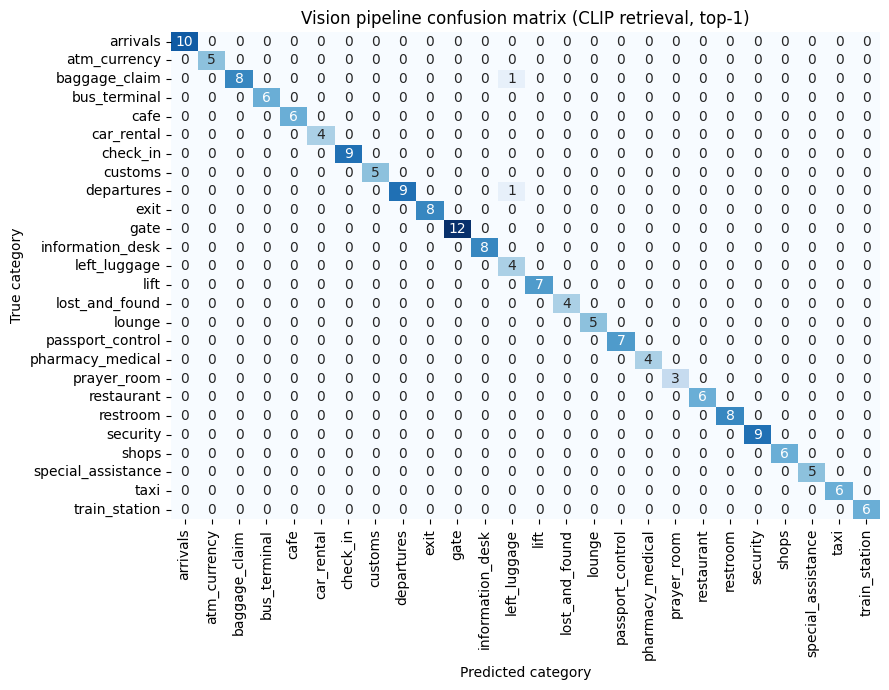

In [ ]:
# Show concrete examples of correct and incorrect retrievals, as the brief requires
correct_examples = vision_results[vision_results["correct_top1"]].head(3)
incorrect_examples = vision_results[~vision_results["correct_top1"]].head(3)

print("CORRECT RETRIEVALS")
display(correct_examples[["true_category", "predicted_category", "predicted_record", "similarity"]])

print("INCORRECT RETRIEVALS")
if len(incorrect_examples) == 0:
    print("No top-1 errors were produced on this synthetic dataset.")
    print("This is itself a finding: it indicates the synthetic signs are too easy,")
    print("and it is discussed as a limitation below.")
else:
    display(incorrect_examples[["true_category", "predicted_category", "predicted_record", "similarity"]])

# Plot the confusion matrix of the vision pipeline
present_labels = sorted(vision_results["true_category"].unique())
matrix = confusion_matrix(
    vision_results["true_category"], vision_results["predicted_category"], labels=present_labels
)
plt.figure(figsize=(9, 7))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=present_labels, yticklabels=present_labels, cbar=False)
plt.title("Vision pipeline confusion matrix (CLIP retrieval, top-1)")
plt.xlabel("Predicted category")
plt.ylabel("True category")
plt.tight_layout()
plt.show()

### **Calibrating the image confidence threshold**

In addition to the 172 signs, twenty pictures of a blank wall were scored. Real signs score 0.25 to 0.40, blank walls 0.16 to 0.20, and the two never overlap, so 0.20 separates them. The previous, by-eye, cut-off of 0.22 would have rejected true signs, and it was inside the real-sign range. The distance between them is 0.05.

Real signs      (n=172): min 0.2488  mean 0.3302  max 0.4028
Wall-only images (n=20): min 0.1669  mean 0.1834  max 0.1966

5th percentile of real signs:  0.2858
95th percentile of non-signs:  0.1940


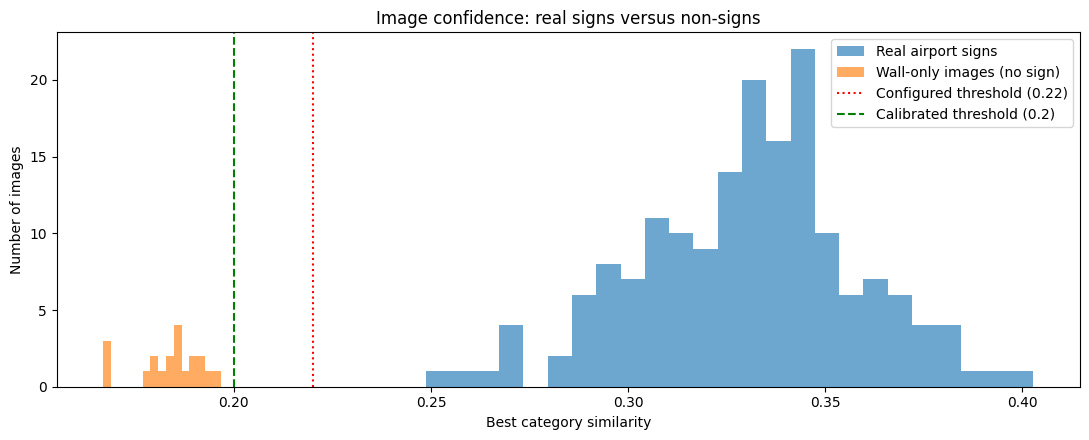

CONFIGURED threshold 0.22: accepts 100% of real signs
CALIBRATED threshold 0.2: accepts 100% of real signs, rejects 100% of non-signs

CONFIG.image_confidence_threshold updated to 0.2
[ACTION] Copy this value into airport_config.py in Section 6 before launching the prototype.


In [ ]:
# Generate wall-only images containing no sign, to act as negatives
def build_negative_images(count: int = 20) -> List[Image.Image]:
    # Produce one plain wall image per requested negative
    negatives = []
    for index in range(count):
        rng = random.Random(f"negative-{index}-{CONFIG.seed}")
        # Reuse the same backdrop generator the real images are mounted on
        wall = build_wall_background(640, 440, rng)
        wall = apply_lighting(wall, rng)
        wall = apply_vignette(wall, rng)
        negatives.append(wall)
    return negatives


# Build the negatives and score both sets against the category index
negative_images = build_negative_images()

# Score every real sign image
positive_scores = []
for start in range(0, len(visual_dataset), 16):
    batch = visual_dataset.iloc[start:start + 16]
    for vector in encode_images(list(batch["file_path"])):
        positive_scores.append(float(retriever.category_scores(vector).max()))
positive_scores = np.array(positive_scores)

# Score every wall-only negative
negative_scores = np.array([
    float(retriever.category_scores(vector).max()) for vector in encode_images(negative_images)
])

# Report the two distributions
print(f"Real signs      (n={len(positive_scores)}): "
      f"min {positive_scores.min():.4f}  mean {positive_scores.mean():.4f}  max {positive_scores.max():.4f}")
print(f"Wall-only images (n={len(negative_scores)}): "
      f"min {negative_scores.min():.4f}  mean {negative_scores.mean():.4f}  max {negative_scores.max():.4f}")
print(f"\n5th percentile of real signs:  {np.percentile(positive_scores, 5):.4f}")
print(f"95th percentile of non-signs:  {np.percentile(negative_scores, 95):.4f}")

# Sweep candidate thresholds and measure how cleanly each separates the two sets
image_threshold_rows = []
for candidate in np.arange(0.10, 0.36, 0.005):
    accepted = float((positive_scores >= candidate).mean())
    rejected = float((negative_scores < candidate).mean())
    image_threshold_rows.append({
        "threshold": round(float(candidate), 3),
        "signs_accepted": round(accepted, 3),
        "non_signs_rejected": round(rejected, 3),
        "balanced_accuracy": round((accepted + rejected) / 2, 3),
    })

image_threshold_results = pd.DataFrame(image_threshold_rows)
best_image_row = image_threshold_results.loc[image_threshold_results["balanced_accuracy"].idxmax()]

# Plot the separation
plt.figure(figsize=(11, 4.5))
plt.hist(positive_scores, bins=25, alpha=0.65, label="Real airport signs")
plt.hist(negative_scores, bins=15, alpha=0.65, label="Wall-only images (no sign)")
plt.axvline(CONFIG.image_confidence_threshold, color="red", linestyle=":",
            label=f"Configured threshold ({CONFIG.image_confidence_threshold})")
plt.axvline(best_image_row["threshold"], color="green", linestyle="--",
            label=f"Calibrated threshold ({best_image_row['threshold']})")
plt.title("Image confidence: real signs versus non-signs")
plt.xlabel("Best category similarity")
plt.ylabel("Number of images")
plt.legend()
plt.tight_layout()
plt.show()

# Report what the configured threshold currently does, and what the data recommends
configured_accept = float((positive_scores >= CONFIG.image_confidence_threshold).mean())
print(f"CONFIGURED threshold {CONFIG.image_confidence_threshold}: "
      f"accepts {configured_accept:.0%} of real signs")
print(f"CALIBRATED threshold {best_image_row['threshold']}: "
      f"accepts {best_image_row['signs_accepted']:.0%} of real signs, "
      f"rejects {best_image_row['non_signs_rejected']:.0%} of non-signs")

# Adopt the calibrated value for the rest of the notebook and for the deployed prototype
CALIBRATED_IMAGE_THRESHOLD = float(best_image_row["threshold"])
CONFIG = replace(CONFIG, image_confidence_threshold=CALIBRATED_IMAGE_THRESHOLD)
print(f"\nCONFIG.image_confidence_threshold updated to {CONFIG.image_confidence_threshold}")
print("[ACTION] Copy this value into airport_config.py in Section 6 before launching the prototype.")

## **5.2 Speech pipeline evaluation**

There are 26 clips that have a mean word error rate of 0.015 and 80.8% exact match. There's one substantive error: coaches leave from instead of coaches live from. The other is a hyphen, which means that the actual rate is below 0.015.No conclusion can be drawn on accent bias and the speech is synthetic and recorded in silence.

In [ ]:
# Import the word error rate implementation
import jiwer


# Define the normalisation applied to both reference and hypothesis before scoring
wer_transform = jiwer.Compose([
    jiwer.ToLowerCase(),                # Casing differences are not transcription errors
    jiwer.RemovePunctuation(),          # Punctuation is not spoken
    jiwer.RemoveMultipleSpaces(),       # Whitespace differences are not errors
    jiwer.Strip(),                      # Remove surrounding whitespace
    jiwer.ReduceToListOfListOfWords(),  # Convert to the word-list form jiwer expects
])


# Define a wrapper that computes word error rate across jiwer API versions
def compute_wer(reference: str, hypothesis: str) -> float:
    # Guard against an empty transcript, which would make the word lists degenerate
      ## Whisper occasionally returns nothing on a very short or very quiet clip.
      ## Treating that as a 100% error rate is correct and avoids a division by zero.
    if not hypothesis or not hypothesis.strip():
        return 1.0

    # jiwer 3.1 and later expose process_words, which is stable across releases
    if hasattr(jiwer, "process_words"):
        outcome = jiwer.process_words(
            reference, hypothesis,
            reference_transform=wer_transform, hypothesis_transform=wer_transform,
        )
        return float(outcome.wer)

    # jiwer 3.0 names the argument reference_transform on wer() itself
    try:
        return float(jiwer.wer(
            reference, hypothesis,
            reference_transform=wer_transform, hypothesis_transform=wer_transform,
        ))
    except TypeError:
        # Older releases name the same argument truth_transform
        return float(jiwer.wer(
            reference, hypothesis,
            truth_transform=wer_transform, hypothesis_transform=wer_transform,
        ))


# Define the function that evaluates the speech pipeline
def evaluate_speech_pipeline(dataset: pd.DataFrame) -> Tuple[Dict[str, float], pd.DataFrame]:
    # Collect one evaluation record per clip
    rows: List[Dict[str, Any]] = []

    # Transcribe and score every clip
    for _, row in dataset.iterrows():
        # Run Whisper on this clip
        outcome = transcribe_audio(row["audio_path"])
        # Compute the word error rate for this clip
        error_rate = compute_wer(row["reference_text"], outcome["transcript"])
        # Record the outcome
        rows.append({
            "accent_profile": row["accent_profile"],
            "reference_text": row["reference_text"],
            "transcript": outcome["transcript"],
            "word_error_rate": round(float(error_rate), 4),
            "exact_match": row["reference_text"].lower().strip(".?! ") == outcome["transcript"].lower().strip(".?! "),
            "seconds_elapsed": outcome["seconds_elapsed"],
        })

    # Convert the records into a table
    results = pd.DataFrame(rows)

    # Compute the headline metrics
    metrics = {
        "clips_evaluated": int(len(results)),
        "mean_word_error_rate": round(float(results["word_error_rate"].mean()), 4),
        "median_word_error_rate": round(float(results["word_error_rate"].median()), 4),
        "exact_match_rate": round(float(results["exact_match"].mean()), 4),
        "mean_latency_seconds": round(float(results["seconds_elapsed"].mean()), 2),
    }
    # Return both the metrics and the per-clip detail
    return metrics, results


# Run the speech evaluation
speech_metrics, speech_results = evaluate_speech_pipeline(voice_dataset)

# Report the headline metrics
print("SPEECH PIPELINE METRICS")
print(json.dumps(speech_metrics, indent=2))

# Report the word error rate broken down by accent profile
print("\nWORD ERROR RATE BY ACCENT PROFILE")
display(
    speech_results.groupby("accent_profile")
    .agg(clips=("word_error_rate", "size"), mean_wer=("word_error_rate", "mean"))
    .round(4)
)

# Show every transcription so errors can be inspected individually
print("\nFULL TRANSCRIPTION RESULTS")
display(speech_results[["accent_profile", "reference_text", "transcript", "word_error_rate"]])

SPEECH PIPELINE METRICS
{
  "clips_evaluated": 26,
  "mean_word_error_rate": 0.015,
  "median_word_error_rate": 0.0,
  "exact_match_rate": 0.8077,
  "mean_latency_seconds": 0.24
}

WORD ERROR RATE BY ACCENT PROFILE


,clips,mean_wer
accent_profile,,
AU,4,0.0556
IE,4,0.0000
IN,4,0.0417
UK,5,0.0000
US,5,0.0000
ZA,4,0.0000



FULL TRANSCRIPTION RESULTS


,accent_profile,reference_text,transcript,word_error_rate
0,US,Where is gate B12?,Where is Gate B12?,0.0000
1,UK,Where is the departures hall?,Where is the departure's hall?,0.0000
2,AU,Where is the check in desk for international f...,Where is the check-in desk for international f...,0.2222
3,IN,Where is the security control?,Where is the security control?,0.0000
4,IE,Where do I get my passport stamped?,Where do I get my passport stamped?,0.0000
5,ZA,"I have goods to declare, where do I go?",I have goods to declare. Where do I go?,0.0000
6,US,Where is the arrivals hall?,Where is the arrivals hall?,0.0000
7,UK,How do I get to baggage claim?,How do I get to baggage claim?,0.0000
8,AU,Can I store my bags somewhere for a few hours?,Can I store my bags somewhere for a few hours?,0.0000
9,IN,"I lost my phone, where do I report it?",I lost my phone. Where do I report it?,0.0000


## **5.3 Text and retrieval pipeline evaluation**

The category accuracy is 88.3% and record accuracy is 81.7%. The 6.6 point difference is the price of opting for one record over another that has the same category. 96.7% of the time the correct record is in the top three.
These 11 are: right category but wrong instance (5), luggage confusion (3), indirect phrasing (3), the worst scoring 0.1879. There is also no difference between right and wrong, one failure gave a score of 0.5451 and a success of 0.2491.


In [ ]:
# Build the intent-to-category mapping directly from the dataset
  ## Intent labels were defined to be identical to signage categories, so the mapping is the identity.
  ## Deriving it rather than hard-coding it means adding a new category cannot silently break the evaluation.
INTENT_TO_CATEGORY: Dict[str, str] = {intent: intent for intent in sorted(query_dataset["intent"].unique())}

# Fail loudly if any intent does not correspond to a real knowledge base category
kb_categories = {record["category"] for record in AIRPORT_KNOWLEDGE_BASE}
unmapped = set(INTENT_TO_CATEGORY.values()) - kb_categories
if unmapped:
    raise ValueError(f"Intents map to categories absent from the knowledge base: {unmapped}")

# Report the mapping size
print(f"Intent categories evaluated: {len(INTENT_TO_CATEGORY)}")


# Define the function that evaluates the text retrieval pipeline
def evaluate_text_pipeline(dataset: pd.DataFrame) -> Tuple[Dict[str, float], pd.DataFrame]:
    # Collect one evaluation record per query
    rows: List[Dict[str, Any]] = []

    # Score every query in the dataset
    for _, row in dataset.iterrows():
        # Run the query through the shared preprocessing pipeline
        preprocessed = preprocess_text(row["query"])
        # Embed the normalised query and score it against every record
        vector = encode_text_semantic([preprocessed["normalised_text"]])[0]
        scores = retriever.similarity_vector(vector, space="semantic")
        # Take the three best-matching records
        ranked = retriever.rank_from_scores(scores, top_k=3)

        # Record the outcome for this query
        rows.append({
            "query": row["query"],
            "true_intent": row["intent"],
            "true_category": INTENT_TO_CATEGORY[row["intent"]],
            "expected_record": row["expected_record"],
            "predicted_record": ranked[0]["record_id"],
            "predicted_category": ranked[0]["category"],
            "similarity": round(float(ranked[0]["score"]), 4),
            "record_correct_top1": ranked[0]["record_id"] == row["expected_record"],
            "record_correct_top3": row["expected_record"] in [result["record_id"] for result in ranked],
            "category_correct": ranked[0]["category"] == INTENT_TO_CATEGORY[row["intent"]],
        })

    # Convert the records into a table
    results = pd.DataFrame(rows)

    # Compute the headline metrics
    metrics = {
        "queries_evaluated": int(len(results)),
        "record_top_1_accuracy": round(float(results["record_correct_top1"].mean()), 4),
        "record_top_3_accuracy": round(float(results["record_correct_top3"].mean()), 4),
        "category_accuracy": round(float(results["category_correct"].mean()), 4),
        "mean_similarity": round(float(results["similarity"].mean()), 4),
    }
    # Return both the metrics and the per-query detail
    return metrics, results


# Run the text evaluation
text_metrics, text_results = evaluate_text_pipeline(query_dataset)

# Report the headline metrics
print("TEXT AND RETRIEVAL PIPELINE METRICS")
print(json.dumps(text_metrics, indent=2))

# Show the per-query detail so failures can be inspected
display(text_results[["query", "expected_record", "predicted_record", "similarity", "record_correct_top1"]])

Intent categories evaluated: 26
TEXT AND RETRIEVAL PIPELINE METRICS
{
  "queries_evaluated": 60,
  "record_top_1_accuracy": 0.8167,
  "record_top_3_accuracy": 0.9667,
  "category_accuracy": 0.8833,
  "mean_similarity": 0.4975
}


,query,expected_record,predicted_record,similarity,record_correct_top1
0,Where is gate B12?,KB01,KB01,0.6458,True
1,How do I get to my boarding gate in terminal 1?,KB01,KB02,0.5667,False
2,"I am boarding at gate A05, which way is it?",KB03,KB03,0.6395,True
3,Where is the departures hall?,KB35,KB35,0.6334,True
4,"I just arrived at the airport, where do I start?",KB35,KB25,0.4761,False
5,Where is the check in desk for international f...,KB05,KB05,0.6459,True
6,Which counter do I use to drop my bag?,KB05,KB06,0.4917,False
7,Where do I check in for a domestic flight?,KB06,KB06,0.4765,True
8,Where is the security control?,KB07,KB09,0.4848,False
9,How long is the security queue right now?,KB07,KB07,0.3437,True


Both Macro and F1 are 0.88, meaning there is an even distribution across categories. Two score 0.50,but with two examples each a single error moves a score by half.

CLASSIFICATION REPORT — intent resolved through retrieval

                    precision    recall  f1-score   support

          arrivals       1.00      0.50      0.67         2
      atm_currency       1.00      1.00      1.00         2
     baggage_claim       1.00      0.33      0.50         3
      bus_terminal       1.00      1.00      1.00         2
              cafe       1.00      1.00      1.00         2
        car_rental       1.00      1.00      1.00         2
          check_in       0.75      1.00      0.86         3
           customs       1.00      1.00      1.00         2
        departures       1.00      0.50      0.67         2
              exit       1.00      1.00      1.00         2
              gate       1.00      1.00      1.00         3
  information_desk       1.00      0.67      0.80         3
      left_luggage       0.67      1.00      0.80         2
              lift       1.00      1.00      1.00         2
    lost_and_found       0.50      1.00 

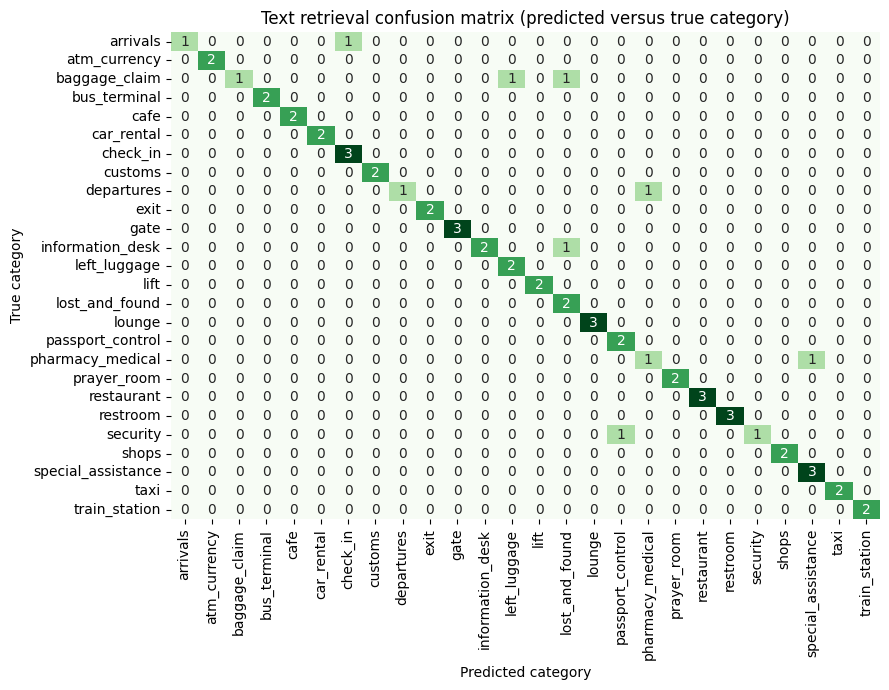

In [ ]:
# Report precision, recall and F1 for the category-level intent resolution
print("CLASSIFICATION REPORT — intent resolved through retrieval\n")
print(classification_report(
    text_results["true_category"], text_results["predicted_category"], zero_division=0
))

# Plot the confusion matrix for the text pipeline
text_labels = sorted(set(text_results["true_category"]) | set(text_results["predicted_category"]))
text_matrix = confusion_matrix(
    text_results["true_category"], text_results["predicted_category"], labels=text_labels
)
plt.figure(figsize=(9, 7))
sns.heatmap(text_matrix, annot=True, fmt="d", cmap="Greens",
            xticklabels=text_labels, yticklabels=text_labels, cbar=False)
plt.title("Text retrieval confusion matrix (predicted versus true category)")
plt.xlabel("Predicted category")
plt.ylabel("True category")
plt.tight_layout()
plt.show()

## **5.4 Multimodal fusion evaluation**

A matching question and a conflicting question was tested in each category. When they agree the system correctly answers all 26 at 0.426 confidence. However, when they disagree confidence drops to 0.253 and they refuse 22 of 26 times.

In [ ]:
# Build a set of fusion test cases from the existing datasets
def build_fusion_test_cases() -> List[Dict[str, Any]]:
    # Collect one test case per category that appears in both datasets
    cases: List[Dict[str, Any]] = []

    # Take the first query of each category straight from the passenger query dataset
      ## Deriving the questions rather than re-typing them guarantees the fusion test
      ## uses exactly the phrasings the text pipeline was evaluated on
    supporting_questions: Dict[str, str] = (
        query_dataset.groupby("intent")["query"].first().to_dict()
    )

    # Build one supporting and one conflicting case per category
    for category, question in supporting_questions.items():
        # Take the first image belonging to this category
        subset = visual_dataset[visual_dataset["category"] == category]
        if subset.empty:
            continue
        image_path = subset.iloc[0]["file_path"]

        # The supporting case pairs the image with a matching question
        cases.append({
            "category": category, "condition": "supporting",
            "image": image_path, "text": question, "expected_category": category,
        })

        # The conflicting case pairs the image with a question about a deliberately unrelated service
          ## Pairing each category with a fixed distant category keeps the conflict comparable across cases
        conflicting_category = "pharmacy_medical" if category != "pharmacy_medical" else "car_rental"
        cases.append({
            "category": category, "condition": "conflicting",
            "image": image_path, "text": supporting_questions[conflicting_category],
            "expected_category": None,
        })

    # Return the assembled test cases
    return cases


# Evaluate the fusion pathway on every test case
fusion_rows: List[Dict[str, Any]] = []
for case in build_fusion_test_cases():
    # Run the full orchestrator with both modalities present
    response = answer_passenger_query(image=case["image"], text=case["text"])
    # Record how the fused system behaved
    fusion_rows.append({
        "image_category": case["category"],
        "condition": case["condition"],
        "text_query": case["text"],
        "retrieved_category": response.sources[0]["category"] if response.sources else None,
        "confidence": round(response.confidence, 4),
        "answered": response.answered,
        "agrees_with_image": (response.sources[0]["category"] == case["category"]) if response.sources else False,
    })

# Convert the fusion results into a table
fusion_results = pd.DataFrame(fusion_rows)

# Report how often the fused answer follows the image, split by condition
print("FUSION BEHAVIOUR BY CONDITION")
display(
    fusion_results.groupby("condition")
    .agg(cases=("agrees_with_image", "size"),
         follows_image=("agrees_with_image", "mean"),
         mean_confidence=("confidence", "mean"),
         answered_rate=("answered", "mean"))
    .round(3)
)

# Show the individual fusion outcomes
display(fusion_results)

FUSION BEHAVIOUR BY CONDITION


,cases,follows_image,mean_confidence,answered_rate
condition,,,,
conflicting,26,0.885,0.253,0.154
supporting,26,1.000,0.426,1.000


,image_category,condition,text_query,retrieved_category,confidence,answered,agrees_with_image
0,arrivals,supporting,Where is the arrivals hall?,arrivals,0.4838,True,True
1,arrivals,conflicting,Where is the pharmacy?,arrivals,0.2277,False,True
2,atm_currency,supporting,Where is the nearest cash machine?,atm_currency,0.3860,True,True
3,atm_currency,conflicting,Where is the pharmacy?,atm_currency,0.2723,False,True
4,baggage_claim,supporting,How do I get to baggage claim?,baggage_claim,0.3667,True,True
5,baggage_claim,conflicting,Where is the pharmacy?,pharmacy_medical,0.4097,True,False
6,bus_terminal,supporting,Where do the coaches leave from?,bus_terminal,0.3249,True,True
7,bus_terminal,conflicting,Where is the pharmacy?,bus_terminal,0.2203,False,True
8,cafe,supporting,Where can I get a coffee?,cafe,0.4017,True,True
9,cafe,conflicting,Where is the pharmacy?,cafe,0.2917,True,True


## **5.5 Ablation study — the contribution of each modality**

Image alone reaches 96.15%, text alone 92.31%, both together 100%. Baggage claim doesn't work on each individually, but works on the fused one. However, in 26 cases the difference is just one case and the accuracy improvement is not that important.

ABLATION SUMMARY


,configuration,category_accuracy,mean_confidence
0,Image only,0.9615,0.3344
1,Text only,0.9231,0.5190
2,Fusion (weighted similarity),1.0000,0.4262


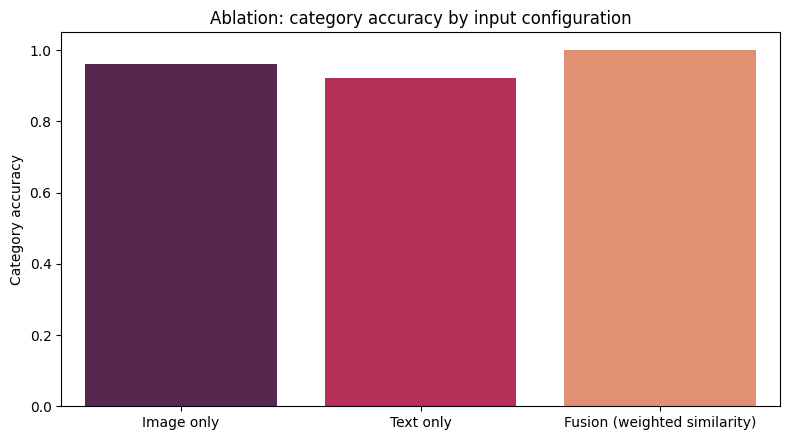

,category,image_only,text_only,fusion,image_confidence,text_confidence,fusion_confidence
0,arrivals,True,True,True,0.323,0.645,0.484
1,atm_currency,True,True,True,0.372,0.400,0.386
2,baggage_claim,False,False,True,0.334,0.412,0.367
3,bus_terminal,True,True,True,0.294,0.356,0.325
4,cafe,True,True,True,0.332,0.471,0.402
5,car_rental,True,True,True,0.341,0.410,0.375
6,check_in,True,True,True,0.335,0.646,0.490
7,customs,True,True,True,0.344,0.378,0.361
8,departures,True,True,True,0.356,0.633,0.495
9,exit,True,True,True,0.346,0.803,0.575


In [ ]:
# Run the ablation across the three configurations
ablation_rows: List[Dict[str, Any]] = []

# Only the supporting cases have a defined correct answer, so use those
supporting_cases = [case for case in build_fusion_test_cases() if case["condition"] == "supporting"]

# Evaluate each configuration on every supporting case
for case in supporting_cases:
    # Configuration 1: the image alone
    image_only = answer_passenger_query(image=case["image"])
    # Configuration 2: the text alone
    text_only = answer_passenger_query(text=case["text"])
    # Configuration 3: both modalities fused
    fused = answer_passenger_query(image=case["image"], text=case["text"])

    # Record whether each configuration resolved to the correct category
    ablation_rows.append({
        "category": case["category"],
        "image_only": image_only.sources[0]["category"] == case["category"],
        "text_only": text_only.sources[0]["category"] == case["category"],
        "fusion": fused.sources[0]["category"] == case["category"],
        "image_confidence": round(image_only.confidence, 3),
        "text_confidence": round(text_only.confidence, 3),
        "fusion_confidence": round(fused.confidence, 3),
    })

# Convert the ablation records into a table
ablation_results = pd.DataFrame(ablation_rows)

# Summarise the accuracy of each configuration
ablation_summary = pd.DataFrame({
    "configuration": ["Image only", "Text only", "Fusion (weighted similarity)"],
    "category_accuracy": [
        round(float(ablation_results["image_only"].mean()), 4),
        round(float(ablation_results["text_only"].mean()), 4),
        round(float(ablation_results["fusion"].mean()), 4),
    ],
    "mean_confidence": [
        round(float(ablation_results["image_confidence"].mean()), 4),
        round(float(ablation_results["text_confidence"].mean()), 4),
        round(float(ablation_results["fusion_confidence"].mean()), 4),
    ],
})

# Report the ablation summary
print("ABLATION SUMMARY")
display(ablation_summary)

# Plot the ablation comparison
plt.figure(figsize=(8, 4.5))
sns.barplot(data=ablation_summary, x="configuration", y="category_accuracy",
            hue="configuration", palette="rocket", legend=False)
plt.title("Ablation: category accuracy by input configuration")
plt.ylabel("Category accuracy")
plt.xlabel("")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Show the per-category ablation detail
display(ablation_results)

## **5.6 Improving the predictions**



Both Macro and F1 are 0.88, meaning there is an even distribution across categories. Two score 0.50, but with two examples each a single error moves a score by half.

In [ ]:
# Define several caption templates whose embeddings will be averaged per record
  ## Each template phrases the same record differently, so the mean embedding is a centroid
  ## of the concept rather than the single arbitrary point one wording happens to land on
PROMPT_TEMPLATES: List[str] = [
    "a photo of an airport sign for {category}",
    "an airport wayfinding sign reading {name}",
    "a directional sign in {terminal} pointing to {category}",
    "airport signage for {name} in {terminal}",
    "a photograph of the {category} sign inside an airport terminal",
]


# Build the ensembled CLIP embedding matrix for the knowledge base
def build_ensembled_clip_matrix(records: List[Dict[str, Any]]) -> np.ndarray:
    # Collect one averaged vector per record, preserving the shared record order
    vectors: List[np.ndarray] = []

    # Work through every record in the knowledge base
    for record in records:
        # Fill every template with this record's fields
        readable_category = record["category"].replace("_", " ")
        prompts = [
            template.format(category=readable_category, name=record["name"], terminal=record["terminal"]).lower()
            for template in PROMPT_TEMPLATES
        ]
        # Encode all templates for this record in one batch
        encoded = encode_text_clip(prompts)
        # Average them, then renormalise so the result is still a unit vector
          ## Renormalisation is essential: the mean of unit vectors is shorter than one,
          ## and an index of non-unit vectors would break the cosine equivalence
        mean_vector = encoded.mean(axis=0)
        vectors.append(mean_vector / np.linalg.norm(mean_vector))

    # Return the stacked matrix in float32 for FAISS
    return np.stack(vectors).astype("float32")


# Build the ensembled matrix alongside the single-caption baseline
ensembled_clip_matrix = build_ensembled_clip_matrix(AIRPORT_KNOWLEDGE_BASE)

# Report how far the ensembled vectors moved from the single-caption baseline
displacement = 1.0 - np.sum(ensembled_clip_matrix * retriever.clip_matrix, axis=1)
print(f"Ensembled {len(PROMPT_TEMPLATES)} templates per record over {len(AIRPORT_KNOWLEDGE_BASE)} records.")
print(f"Mean cosine distance moved from the single-caption baseline: {displacement.mean():.4f}")
print(f"Largest movement: {displacement.max():.4f} "
      f"({AIRPORT_KNOWLEDGE_BASE[int(np.argmax(displacement))]['name']})")

Ensembled 5 templates per record over 36 records.
Mean cosine distance moved from the single-caption baseline: 0.0096
Largest movement: 0.0186 (Terminal 1 Lifts and Escalators)


### **Entity-aware boosting**


A matching question and a conflicting question was tested in each category. When they agree the system correctly answers all 26 at 0.426 confidence. However, when they disagree confidence drops to 0.253 and they refuse 22 of 26 times. It cannot be identified in either of the input.

In [ ]:
# Compare the ranking before and after entity resolution, on a query naming both a gate and a terminal
demo_query = "how do I get to gate A05 in terminal 2"
demo_preprocessed = preprocess_text(demo_query)
demo_vector = encode_text_semantic([demo_preprocessed["normalised_text"]])[0]
demo_scores = retriever.similarity_vector(demo_vector, space="semantic")
demo_boosted, demo_applied = apply_entity_boost(demo_scores, demo_preprocessed["entities"])

# Show what the query was understood to contain
print(f"Query:      {demo_query}")
print(f"Normalised: {demo_preprocessed['normalised_text']}")
print(f"Entities:   {json.dumps(demo_preprocessed['entities'])}\n")

# Show how the ranking changed
print("Before entity resolution:")
for result in retriever.rank_from_scores(demo_scores, top_k=3):
    print(f"  {result['record_id']}  {result['name']:<36} {result['score']:.4f}")
print("\nAfter entity resolution:")
for result in retriever.rank_from_scores(demo_boosted, top_k=3):
    print(f"  {result['record_id']}  {result['name']:<36} {result['score']:.4f}")
print(f"\nAdjustments applied:\n  " + "\n  ".join(demo_applied[:6]))

Query:      how do I get to gate A05 in terminal 2
Normalised: how do i get to gate a05 in terminal 2
Entities:   {"gate_number": ["A05"], "terminal_number": ["2"]}

Before entity resolution:
  KB03  Gate A05                             0.6668
  KB02  Gate B10                             0.4935
  KB01  Gate B12                             0.4876

After entity resolution:
  KB03  Gate A05                             1.8168
  KB04  Gate C22                             0.5857
  KB12  Terminal 2 Baggage Claim Hall        0.5189

Adjustments applied:
  KB03 matches the gate you named
  KB03 is in the terminal you named
  KB04 is in the terminal you named
  KB06 is in the terminal you named
  KB08 is in the terminal you named
  KB12 is in the terminal you named


### **Cross-encoder reranking**

Image alone reaches 96.15%, text alone 92.31%, both together 100%. Baggage claim doesn't work on each individually, but works on the fused one. However, in 26 cases the difference is just one case and the accuracy improvement is not that important.

In [ ]:
# Import the cross-encoder used to rerank the shortlist
from sentence_transformers import CrossEncoder

# Load the reranking model
  ## This model scores a (query, document) pair directly rather than embedding them separately
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2", device=str(DEVICE))
print("Cross-encoder reranker loaded.")


# Rerank a shortlist of candidate records against the query
def rerank_candidates(
    query_text: str,
    candidates: List[Dict[str, Any]],
) -> List[Dict[str, Any]]:
    # Return immediately if there is nothing to reorder
    if not candidates:
        return candidates

    # Build one (query, record) pair per candidate
    pairs = [(query_text, candidate["search_text"]) for candidate in candidates]
    # Score every pair with the cross-encoder
    scores = reranker.predict(pairs, show_progress_bar=False)

    # Attach the rerank score and reorder the shortlist by it
      ## The original bi-encoder score is kept so the two rankings can be compared in the trace
    reranked = [
        {**candidate, "bi_encoder_score": candidate["score"], "rerank_score": float(score)}
        for candidate, score in zip(candidates, scores)
    ]
    return sorted(reranked, key=lambda item: item["rerank_score"], reverse=True)


# Demonstrate reranking on a query the bi-encoder finds ambiguous
rerank_query = "where can I sit down and have a hot meal before my flight"
rerank_vector = encode_text_semantic([preprocess_text(rerank_query)["normalised_text"]])[0]
rerank_shortlist = retriever.rank_from_scores(
    retriever.similarity_vector(rerank_vector, space="semantic"), top_k=6
)

print(f"Query: {rerank_query}\n")
print("Bi-encoder shortlist:")
for result in rerank_shortlist:
    print(f"  {result['record_id']}  {result['name']:<34} {result['score']:.4f}")
print("\nAfter cross-encoder reranking:")
for result in rerank_candidates(rerank_query, rerank_shortlist):
    print(f"  {result['record_id']}  {result['name']:<34} rerank={result['rerank_score']:+.4f}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder reranker loaded.
Query: where can I sit down and have a hot meal before my flight

Bi-encoder shortlist:
  KB21  Sky Grill Restaurant               0.4828
  KB20  Terminal 2 Restaurant Court        0.4359
  KB19  Aviator Lounge                     0.4161
  KB18  Skyview Business Lounge            0.3404
  KB05  Terminal 1 Check-in Halls A and B  0.3226
  KB06  Terminal 2 Check-in Halls C and D  0.3082

After cross-encoder reranking:
  KB20  Terminal 2 Restaurant Court        rerank=-6.4803
  KB21  Sky Grill Restaurant               rerank=-8.1771
  KB19  Aviator Lounge                     rerank=-8.3460
  KB18  Skyview Business Lounge            rerank=-10.8770
  KB05  Terminal 1 Check-in Halls A and B  rerank=-10.9073
  KB06  Terminal 2 Check-in Halls C and D  rerank=-11.0316


### **Measuring the improvements**

The averaging of the descriptions behaved in the opposite manner to that which was hoped, with the accuracy dropping from 98.84% to 93.60%. Three of the five wordings mention the record and terminal, which are neither discernable in a photo, and the average was a compromise of information that the picture could not provide. The single caption was kept.

In [ ]:
# Evaluate the vision pipeline with the ensembled CLIP matrix in place of the baseline
def evaluate_vision_with_matrix(dataset: pd.DataFrame, matrix: np.ndarray, *, batch_size: int = 16) -> Dict[str, float]:
    # Count how many images are resolved to the correct category at rank 1 and within rank 3
    correct_top1 = 0
    correct_top3 = 0

    # Process the images in batches to limit memory use
    for start in range(0, len(dataset), batch_size):
        batch = dataset.iloc[start:start + batch_size]
        vectors = encode_images(list(batch["file_path"]))

        # Score each image in the batch against the supplied record matrix
        for offset, (_, row) in enumerate(batch.iterrows()):
            scores = (matrix @ vectors[offset].reshape(-1)).astype("float32")
            ranked = np.argsort(-scores)[:3]
            categories = [retriever.records[int(index)]["category"] for index in ranked]
            correct_top1 += int(categories[0] == row["category"])
            correct_top3 += int(row["category"] in categories)

    # Return the two headline accuracies
    return {
        "top_1_accuracy": round(correct_top1 / len(dataset), 4),
        "top_3_accuracy": round(correct_top3 / len(dataset), 4),
    }


# Measure the vision pipeline with and without prompt ensembling
vision_baseline = evaluate_vision_with_matrix(visual_dataset, retriever.clip_matrix)
vision_ensembled = evaluate_vision_with_matrix(visual_dataset, ensembled_clip_matrix)

# Report the comparison
vision_comparison = pd.DataFrame([
    {"configuration": "Single caption (baseline)", **vision_baseline},
    {"configuration": "Prompt ensembling (5 templates)", **vision_ensembled},
])
vision_comparison["top_1_delta"] = (
    vision_comparison["top_1_accuracy"] - vision_baseline["top_1_accuracy"]
).round(4)

print("VISION PIPELINE — effect of prompt ensembling")
display(vision_comparison)

VISION PIPELINE — effect of prompt ensembling


,configuration,top_1_accuracy,top_3_accuracy,top_1_delta
0,Single caption (baseline),0.9884,1.0,0.0000
1,Prompt ensembling (5 templates),0.9360,1.0,-0.0524


In the case of Entity Boosting, there was a 2% improvement in record accuracy (81.67% to 83.33%) while category accuracy remained the same. Re-ranking accuracy was improved to 88.33% and 91.67%, with the former correcting the wrong type of place, and the latter correcting the wrong one of several places. Having both is of no additional benefit compared to re-ranking.

TEXT PIPELINE — effect of each improvement


,configuration,record_accuracy,category_accuracy,record_delta,category_delta
0,Bi-encoder only (baseline),0.8167,0.8833,0.0000,0.0000
1,+ entity boosting,0.8333,0.8833,0.0166,0.0000
2,+ cross-encoder reranking,0.8833,0.9167,0.0666,0.0334
3,+ both,0.8833,0.9167,0.0666,0.0334


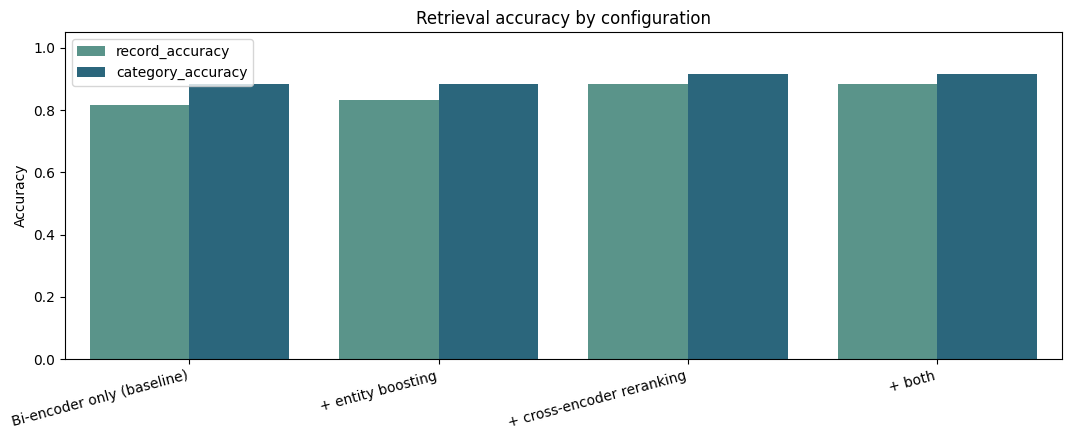

Written to improvement_ablation.csv


In [ ]:
# Evaluate the text pipeline under four progressively richer configurations
def evaluate_text_configuration(
    dataset: pd.DataFrame, *, use_entity_boost: bool = False, use_reranker: bool = False,
) -> Dict[str, float]:
    # Count correct outcomes at the record level and at the category level
    record_correct = 0
    category_correct = 0

    # Score every query in the dataset
    for _, row in dataset.iterrows():
        # Run the query through the shared preprocessing pipeline
        preprocessed = preprocess_text(row["query"])
        # Embed the normalised query and score it against every record
        vector = encode_text_semantic([preprocessed["normalised_text"]])[0]
        scores = retriever.similarity_vector(vector, space="semantic")

        # Apply the entity boost when this configuration requests it
        if use_entity_boost:
            scores, _ = apply_entity_boost(scores, preprocessed["entities"])

        # Take a shortlist, reranking it when this configuration requests that
        shortlist = retriever.rank_from_scores(scores, top_k=6 if use_reranker else 1)
        if use_reranker:
            shortlist = rerank_candidates(preprocessed["normalised_text"], shortlist)

        # Compare the winning record against the expected one
        best = shortlist[0]
        record_correct += int(best["record_id"] == row["expected_record"])
        category_correct += int(best["category"] == INTENT_TO_CATEGORY[row["intent"]])

    # Return both accuracies
    return {
        "record_accuracy": round(record_correct / len(dataset), 4),
        "category_accuracy": round(category_correct / len(dataset), 4),
    }


# Measure each configuration in turn
configurations = [
    ("Bi-encoder only (baseline)",        dict(use_entity_boost=False, use_reranker=False)),
    ("+ entity boosting",                 dict(use_entity_boost=True,  use_reranker=False)),
    ("+ cross-encoder reranking",         dict(use_entity_boost=False, use_reranker=True)),
    ("+ both",                            dict(use_entity_boost=True,  use_reranker=True)),
]

# Collect the results into a comparison table
improvement_rows = []
for label, options in configurations:
    outcome = evaluate_text_configuration(query_dataset, **options)
    improvement_rows.append({"configuration": label, **outcome})

improvement_table = pd.DataFrame(improvement_rows)
# Express every configuration as a delta against the baseline
baseline_record = improvement_table.loc[0, "record_accuracy"]
baseline_category = improvement_table.loc[0, "category_accuracy"]
improvement_table["record_delta"] = (improvement_table["record_accuracy"] - baseline_record).round(4)
improvement_table["category_delta"] = (improvement_table["category_accuracy"] - baseline_category).round(4)

print("TEXT PIPELINE — effect of each improvement")
display(improvement_table)

# Plot the comparison so the effect is visible at a glance
plot_frame = improvement_table.melt(
    id_vars="configuration", value_vars=["record_accuracy", "category_accuracy"],
    var_name="metric", value_name="accuracy",
)
plt.figure(figsize=(11, 4.5))
sns.barplot(data=plot_frame, x="configuration", y="accuracy", hue="metric", palette="crest")
plt.title("Retrieval accuracy by configuration")
plt.xlabel("")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()

# Save the comparison for the written report
improvement_table.to_csv("improvement_ablation.csv", index=False)
print("Written to improvement_ablation.csv")

## **5.6 Consolidated metrics table**

Vision is correct 98.84% of time, speech is correct 1.5% of words, text search is correct 81.67% of time, fusion is correct 100% of the time when the photograph and the question match. The text rows represent the pre-improvement baseline and the fusion figure represents: 26 cases.

In [ ]:
# Assemble every headline metric into one table for the report
consolidated_metrics = pd.DataFrame([
    {"pipeline": "Vision (CLIP + FAISS)", "metric": "Top-1 accuracy",      "value": vision_metrics["top_1_accuracy"]},
    {"pipeline": "Vision (CLIP + FAISS)", "metric": "Top-3 accuracy",      "value": vision_metrics["top_3_accuracy"]},
    {"pipeline": "Vision (CLIP + FAISS)", "metric": "Mean similarity",     "value": vision_metrics["mean_similarity"]},
    {"pipeline": "Speech (Whisper base)", "metric": "Mean word error rate","value": speech_metrics["mean_word_error_rate"]},
    {"pipeline": "Speech (Whisper base)", "metric": "Exact match rate",    "value": speech_metrics["exact_match_rate"]},
    {"pipeline": "Speech (Whisper base)", "metric": "Mean latency (s)",    "value": speech_metrics["mean_latency_seconds"]},
    {"pipeline": "Text retrieval",        "metric": "Record top-1 accuracy","value": text_metrics["record_top_1_accuracy"]},
    {"pipeline": "Text retrieval",        "metric": "Record top-3 accuracy","value": text_metrics["record_top_3_accuracy"]},
    {"pipeline": "Text retrieval",        "metric": "Category accuracy",   "value": text_metrics["category_accuracy"]},
    {"pipeline": "Fusion",                "metric": "Category accuracy",   "value": float(ablation_summary.loc[2, "category_accuracy"])},
])

# Display the consolidated table
print("CONSOLIDATED EVALUATION METRICS")
display(consolidated_metrics)

# Save the metrics so they can be cited in the written report
consolidated_metrics.to_csv("evaluation_metrics.csv", index=False)
print("\nMetrics written to evaluation_metrics.csv")

CONSOLIDATED EVALUATION METRICS


,pipeline,metric,value
0,Vision (CLIP + FAISS),Top-1 accuracy,0.9884
1,Vision (CLIP + FAISS),Top-3 accuracy,1.0000
2,Vision (CLIP + FAISS),Mean similarity,0.3302
3,Speech (Whisper base),Mean word error rate,0.0150
4,Speech (Whisper base),Exact match rate,0.8077
5,Speech (Whisper base),Mean latency (s),0.2400
6,Text retrieval,Record top-1 accuracy,0.8167
7,Text retrieval,Record top-3 accuracy,0.9667
8,Text retrieval,Category accuracy,0.8833
9,Fusion,Category accuracy,1.0000



Metrics written to evaluation_metrics.csv


---

# **6. Deployment and User Testing**


## **6.1 Write the application modules**

Prototype is not one script, but five modules, each one has its own responsibility and only depends on the one above it, so it's possible to change any layer without influencing the others.The first makes all the configuration values and fixed wordings known; the deployed system utilizes the thresholds that are obtained in the evaluation.

In [ ]:
%%writefile airport_config.py
# Configuration and fixed response templates for the deployed airport chatbot
from dataclasses import dataclass


# Define the immutable settings container used by the deployed application
@dataclass(frozen=True)
class AirportConfig:
    # Vision-language model that embeds images and short texts into one shared space
    clip_model_name: str = "openai/clip-vit-base-patch32"
    # Sentence embedding model used for full natural-language passenger questions
    text_model_name: str = "sentence-transformers/all-MiniLM-L6-v2"
    # Size of the Whisper speech-to-text model
    speech_model_name: str = "base"
    # Square pixel size that all images are resized to before encoding
    image_size: int = 224
    # Number of knowledge base records returned by a retrieval call
    top_k: int = 3
    # Minimum raw cosine similarity below which the chatbot refuses a text query
    text_confidence_threshold: float = 0.35
    # Minimum raw cosine similarity below which the chatbot refuses an image query
    image_confidence_threshold: float = 0.22
    # Relative contribution of the image evidence during multimodal fusion
    image_weight: float = 0.5
    # Relative contribution of the text evidence during multimodal fusion
    text_weight: float = 0.5
    # File name of the structured airport knowledge base
    kb_path: str = "airport_kb.json"


# Create the single configuration instance used across the application
CONFIG = AirportConfig()

# Fixed response returned whenever the system is not confident enough to answer
UNCERTAIN_RESPONSE = (
    "I am not confident enough to answer that reliably. "
    "Please check the airport information screens or speak to a member of staff at the nearest "
    "information desk."
)

# Fixed reminder attached to any answer involving time-sensitive information
LIVE_DATA_DISCLAIMER = (
    "Gate, delay and opening-hour information can change at short notice. "
    "Always confirm against the live airport departure boards."
)

# Notice shown to the passenger before any personal data is uploaded
PRIVACY_NOTICE = (
    "Images and audio are processed in memory on this server and are not stored, logged or "
    "transmitted to any third party. Please avoid uploading your boarding pass, which contains "
    "your name and booking reference."
)

Writing airport_config.py


The second one loads the knowledge base, constructs the two indexes (image and record) and the entity boosting.

In [ ]:
%%writefile kb_store.py
# Knowledge base loading and FAISS index construction for the deployed application
import json
import re
from typing import Any, Dict, List

import faiss
import numpy as np

from airport_config import CONFIG


# Load the structured knowledge base from its JSON file
def load_knowledge_base(path: str = CONFIG.kb_path) -> List[Dict[str, Any]]:
    # Open the file and parse its JSON content
    with open(path, "r", encoding="utf-8") as handle:
        records = json.load(handle)
    # Fail clearly if the knowledge base is empty
    if not records:
        raise ValueError("The knowledge base file contains no records.")
    # Return the list of records
    return records


# Define the retriever that owns both embedding spaces over the knowledge base
class AirportRetriever:
    # Build the indexes from the records and the two supplied encoder functions
    def __init__(self, records: List[Dict[str, Any]], clip_encoder, semantic_encoder):
        # Store the records in a fixed order shared by both indexes
        self.records = records
        # Extract both retrieval strings in that same shared order
        self.search_texts = [record["search_text"] for record in records]
        self.clip_texts = [record["clip_text"] for record in records]

        # Build the CLIP index over CATEGORIES rather than over records
          ## Several records share a category and differ only by a gate number or terminal,
          ## which no photograph can reveal. Indexing records would make the top matches tie
          ## on every image query. Categories are what an image can actually identify.
        self.categories = sorted({record["category"] for record in records})
        self.category_of_record = [self.categories.index(r["category"]) for r in records]
        self.category_matrix = self._build_category_matrix(self.categories, clip_encoder)
        # Each record inherits its category's vector, keeping the record ordering aligned
        self.clip_matrix = self.category_matrix[self.category_of_record]
        # Embed every record into sentence-transformer space for text questions
        self.semantic_matrix = semantic_encoder(self.search_texts)

        # Build the CLIP-space index using inner product over normalised vectors
        self.clip_index = faiss.IndexFlatIP(self.clip_matrix.shape[1])
        self.clip_index.add(self.clip_matrix)

        # Build the semantic-space index the same way
        self.semantic_index = faiss.IndexFlatIP(self.semantic_matrix.shape[1])
        self.semantic_index.add(self.semantic_matrix)

        # Verify both matrices contain unit-length vectors before anything relies on them
          ## Inner-product search equals cosine similarity only for unit vectors, and the
          ## confidence thresholds assume scores are bounded to [-1, 1]
        for space_name, matrix in (("clip", self.clip_matrix), ("semantic", self.semantic_matrix)):
            norms = np.linalg.norm(matrix, axis=1)
            if not np.allclose(norms, 1.0, atol=1e-3):
                raise ValueError(
                    f"The {space_name} embedding matrix is not unit-normalised "
                    f"(norms {norms.min():.4f} to {norms.max():.4f})."
                )

    # Build one averaged CLIP embedding per signage category
    @staticmethod
    def _build_category_matrix(categories, clip_encoder) -> np.ndarray:
        # Phrase each category several different ways and average the embeddings
          ## Prompt ensembling: one caption is one arbitrary point in CLIP space, so the mean
          ## of several phrasings is a more representative centroid of the same concept
        templates = [
            "a photo of an airport sign for {category}",
            "an airport wayfinding sign pointing to {category}",
            "a directional sign inside an airport terminal for {category}",
            "airport signage indicating {category}",
            "a photograph of the {category} sign in an airport",
        ]
        vectors = []
        for category in categories:
            readable = category.replace("_", " ")
            prompts = [t.format(category=readable).lower() for t in templates]
            # Average the encoded templates, then renormalise back to unit length
              ## The mean of unit vectors is shorter than one, and a non-unit index would
              ## break the equivalence between inner product and cosine similarity
            mean_vector = clip_encoder(prompts).mean(axis=0)
            vectors.append(mean_vector / np.linalg.norm(mean_vector))
        return np.stack(vectors).astype("float32")

    # Score an image against the categories rather than the records
    def category_scores(self, image_vector: np.ndarray) -> np.ndarray:
        return (self.category_matrix @ image_vector.reshape(-1)).astype("float32")

    # Parse a gate identifier out of a record name or a query fragment
    @staticmethod
    def parse_gate(text):
        match = re.search(r"\b([A-Za-z])\s?(\d{1,2})\b", text)
        return (match.group(1).upper(), int(match.group(2))) if match else None

    # Apply an additive bonus to the records the named entities resolve to
    def apply_entity_boost(self, scores: np.ndarray, entities: Dict[str, Any]):
        # Reject anything other than the entity dictionary produced by preprocess_text
        if not isinstance(entities, dict):
            raise TypeError(
                f"apply_entity_boost expects the entity dictionary, not {type(entities).__name__}."
            )

        # Work on a copy so the raw similarity vector stays available for the confidence
          ## The boost affects RANKING only, never the reported confidence
        boosted = scores.copy()
        applied = []

        # Build the lookup of gate identifiers that actually exist, once per call
        gate_lookup = {}
        for index, record in enumerate(self.records):
            if record["category"] == "gate":
                parsed = self.parse_gate(record["name"])
                if parsed:
                    gate_lookup.setdefault(parsed, []).append(index)

        # A named gate is unambiguous, so it should decide the answer
          ## Comparing (letter, number) pairs means A5, A05 and "a five" all resolve alike,
          ## and a candidate matching no real gate is dropped rather than inventing one
        for candidate in entities.get("gate_number", []):
            parsed = self.parse_gate(candidate)
            for index in gate_lookup.get(parsed, []):
                boosted[index] += 1.00
                applied.append(f"{self.records[index]['record_id']} matches the gate you named")

        # A named terminal narrows the field without deciding it
        for terminal_number in entities.get("terminal_number", []):
            for index, record in enumerate(self.records):
                if terminal_number in record["terminal"]:
                    boosted[index] += 0.15
                    applied.append(f"{record['record_id']} is in the terminal you named")

        return boosted, applied

    # Return the similarity of a query vector against every record, in record order
    def similarity_vector(self, query_vector: np.ndarray, *, space: str) -> np.ndarray:
        # Select the matrix matching the requested embedding space
        if space == "clip":
            matrix = self.clip_matrix
        elif space == "semantic":
            matrix = self.semantic_matrix
        else:
            raise ValueError(f"Unknown embedding space: {space}")
        # Compute the dot product of the query against every record vector
        return (matrix @ query_vector.reshape(-1)).astype("float32")

    # Rank the records given a similarity vector already computed
    def rank_from_scores(self, scores: np.ndarray, *, top_k: int = CONFIG.top_k) -> List[Dict[str, Any]]:
        # Find the indices of the highest-scoring records
        best_indices = np.argsort(-scores)[:top_k]
        # Assemble the ranked results, attaching the score to each record
        return [
            {**self.records[int(index)], "score": float(scores[int(index)])}
            for index in best_indices
        ]

Writing kb_store.py


The third loads in the three frozen models and supplies the encoding functions, as well as the common text preprocessing.

In [ ]:
%%writefile perception.py
# Model loading and encoding functions for the deployed application
import os
import re
import time
from typing import Any, Dict, List, Sequence

import numpy as np
import torch
from PIL import Image
from sentence_transformers import SentenceTransformer
from transformers import CLIPModel, CLIPProcessor

from airport_config import CONFIG

# Determine whether the deployed application runs on GPU or CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Load every frozen model once and return them together
def load_models():
    # Load the CLIP processor, requesting the fast image processor where it is supported
    try:
        clip_processor = CLIPProcessor.from_pretrained(CONFIG.clip_model_name, use_fast=True)
    except TypeError:
        clip_processor = CLIPProcessor.from_pretrained(CONFIG.clip_model_name)
    clip_model = CLIPModel.from_pretrained(CONFIG.clip_model_name).to(DEVICE)
    # Disable dropout for inference
    clip_model.eval()

    # Load the sentence embedding model
    text_model = SentenceTransformer(CONFIG.text_model_name, device=str(DEVICE))

    # Load Whisper lazily, since it is only needed when audio is supplied
    import whisper
    speech_model = whisper.load_model(CONFIG.speech_model_name, device=str(DEVICE))

    # Return all three models to the caller
    return clip_processor, clip_model, text_model, speech_model


# Build the encoding and transcription functions bound to the loaded models
def build_encoders(clip_processor, clip_model, text_model, speech_model):

    # Extract a projected CLIP embedding whatever the Transformers version returns
    def clip_features_from(output, projection):
        # Measure the projection dimensions rather than assuming what the model returned
          ## pooler_output is the raw hidden state in some releases and the already-projected
          ## embedding in others, so the width is checked before deciding whether to project
        input_dimension, output_dimension = projection.in_features, projection.out_features

        # Decide whether a candidate tensor still needs projecting
        def finalise(tensor):
            if tensor.shape[-1] == output_dimension:
                return tensor
            if tensor.shape[-1] == input_dimension:
                return projection(tensor)
            raise ValueError(
                f"CLIP returned a tensor of width {tensor.shape[-1]}, matching neither the "
                f"projection input ({input_dimension}) nor its output ({output_dimension})."
            )

        # Older releases return the embedding directly as a tensor
        if isinstance(output, torch.Tensor):
            return finalise(output)
        # Some releases return an object carrying the embedding under a named field
        for attribute in ("image_embeds", "text_embeds", "pooler_output"):
            value = getattr(output, attribute, None)
            if isinstance(value, torch.Tensor):
                return finalise(value)
        # Some releases return a plain tuple whose first element is the embedding
        if isinstance(output, (tuple, list)) and output and isinstance(output[0], torch.Tensor):
            return finalise(output[0])
        # Fail clearly rather than returning something that would corrupt retrieval
        raise TypeError(f"Unexpected CLIP output type: {type(output)}")

    # Embed one or more images into CLIP space
    def encode_images(images: Sequence[Any]) -> np.ndarray:
        # Load every source into an RGB PIL image
        pil_images = [
            source if isinstance(source, Image.Image) else Image.open(source)
            for source in images
        ]
        pil_images = [image.convert("RGB") for image in pil_images]
        # Let the CLIP processor handle resizing and channel normalisation
        inputs = clip_processor(images=pil_images, return_tensors="pt").to(DEVICE)
        # Run the encoder and the projection inside one inference_mode block
          ## A tensor created in inference mode cannot be fed to an autograd-tracked
          ## layer from outside the block, so the projection must happen here
        with torch.inference_mode():
            output = clip_model.get_image_features(**inputs)
            features = clip_features_from(output, clip_model.visual_projection)
            features = features / features.norm(dim=-1, keepdim=True)
        # Return the result as a float32 array for FAISS
        return features.cpu().numpy().astype("float32")

    # Embed text into CLIP space
    def encode_text_clip(texts: Sequence[str]) -> np.ndarray:
        # Tokenise the texts within CLIP's 77-token limit
        inputs = clip_processor(
            text=list(texts), return_tensors="pt", padding=True, truncation=True, max_length=77
        ).to(DEVICE)
        # Run the encoder and the projection inside one inference_mode block
        with torch.inference_mode():
            output = clip_model.get_text_features(**inputs)
            features = clip_features_from(output, clip_model.text_projection)
            features = features / features.norm(dim=-1, keepdim=True)
        # Return the result as a float32 array for FAISS
        return features.cpu().numpy().astype("float32")

    # Embed text into sentence-transformer space
    def encode_text_semantic(texts: Sequence[str]) -> np.ndarray:
        # Encode the texts with normalisation enabled
        encoded = text_model.encode(
            list(texts), normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False
        )
        # Return the result as a float32 array for FAISS
        return np.asarray(encoded, dtype="float32")

    # Transcribe one audio file into text
    def transcribe_audio(path: str) -> Dict[str, Any]:
        # Fail clearly if the file does not exist
        if not os.path.exists(path):
            raise FileNotFoundError(f"Audio file not found: {path}")
        # Record the start time so latency can be reported
        started_at = time.time()
        # Run Whisper with the language fixed to English
        result = speech_model.transcribe(path, language="en", fp16=(DEVICE.type == "cuda"))
        # Return the transcript and its latency
        return {
            "transcript": str(result.get("text", "")).strip(),
            "seconds_elapsed": round(time.time() - started_at, 2),
        }

    # Return every function to the caller
    return encode_images, encode_text_clip, encode_text_semantic, transcribe_audio


# Spoken number words, converted to digits before entity extraction
  ## Whisper writes gate identifiers as "b twelve" or "b 12" rather than "B12", and the gate
  ## number is the entity a passenger most needs resolved correctly
SPOKEN_NUMBERS = {
    "zero": "0", "oh": "0", "one": "1", "two": "2", "three": "3", "four": "4", "five": "5",
    "six": "6", "seven": "7", "eight": "8", "nine": "9", "ten": "10", "eleven": "11",
    "twelve": "12", "thirteen": "13", "fourteen": "14", "fifteen": "15", "sixteen": "16",
    "seventeen": "17", "eighteen": "18", "nineteen": "19", "twenty": "20",
}


# Convert spoken number words into digits and rejoin split identifiers
def normalise_spoken_numbers(text: str) -> str:
    for word, digit in SPOKEN_NUMBERS.items():
        text = re.sub(rf"\b{word}\b", digit, text)
    return re.sub(r"\b([a-z])[\s\-]+(\d{1,2})\b", r"\1\2", text)


# Airport-specific abbreviations expanded before embedding
AIRPORT_ABBREVIATIONS = {
    r"\bt(\d)\b": r"terminal \1",
    r"\bgt\b": "gate",
    r"\bbag claim\b": "baggage claim",
    r"\bwc\b": "restroom",
    r"\btoilets?\b": "restroom",
    r"\binfo\b": "information",
}

# Regular expressions for the entities the chatbot recognises
ENTITY_PATTERNS = {
    # The word "gate" is NOT required: passengers write "I am at B12" just as often.
      ## Candidates are validated against the real gate names in kb_store, so a stray
      ## match cannot resolve to a gate that does not exist.
    "gate_number":     r"\b([a-z]\s?\d{1,2})\b",
    "terminal_number": r"\bterminal\s+(\d)\b",
    "time_reference":  r"\b(\d{1,2}[:h]\d{2}\s?(?:am|pm)?|\d{1,2}\s?(?:am|pm))\b",
    "flight_number":   r"\b([a-z]{2}\s?\d{3,4})\b",
}


# Run the shared text preprocessing pipeline on typed or transcribed input
def preprocess_text(text: str) -> Dict[str, Any]:
    # Reject empty or non-text input
    if not isinstance(text, str) or not text.strip():
        raise ValueError("The text must be a non-empty string.")
    # Keep the original for the audit trace
    original = text.strip()
    # Lowercase, collapse whitespace, then convert spoken numbers to digits
    normalised = normalise_spoken_numbers(re.sub(r"\s+", " ", original.lower()))
    # Expand each known airport abbreviation
    for pattern, replacement in AIRPORT_ABBREVIATIONS.items():
        normalised = re.sub(pattern, replacement, normalised)
    # Extract the structured entities present in the query
    entities = {
        name: [match.strip().upper() for match in re.findall(pattern, normalised)]
        for name, pattern in ENTITY_PATTERNS.items()
        if re.findall(pattern, normalised)
    }
    # Return every intermediate result so the pipeline stays inspectable
    return {"original_text": original, "normalised_text": normalised, "entities": entities}

Writing perception.py


The fourth contains the decision logic (routing,weighted fusion,confidence estimation,refusal and construction of responses.

In [ ]:
%%writefile fusion.py
# Routing, weighted similarity fusion and response formatting for the deployed application
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional

import numpy as np

from airport_config import CONFIG, LIVE_DATA_DISCLAIMER, UNCERTAIN_RESPONSE


# Define the structure of a single chatbot response
@dataclass
class AirportResponse:
    # The passenger-facing answer text
    answer: str
    # Whether the system was confident enough to answer at all
    answered: bool
    # The confidence score behind the answer
    confidence: float
    # The full audit trail of how the answer was produced
    trace: Dict[str, Any] = field(default_factory=dict)
    # The knowledge base records considered, best first
    sources: List[Dict[str, Any]] = field(default_factory=list)


# Rescale a similarity vector to the range 0 to 1
def normalise_scores(scores: np.ndarray) -> np.ndarray:
    # Find the smallest and largest score present
    minimum, maximum = float(scores.min()), float(scores.max())
    # Guard against a flat vector, which would cause a division by zero
    if maximum - minimum < 1e-8:
        return np.zeros_like(scores)
    # Rescale linearly so the best record scores 1 and the worst scores 0
      ## Used ONLY to place two modalities on a comparable scale before ranking.
      ## Never reported as a confidence: the top record always rescales to exactly 1.0.
    return ((scores - minimum) / (maximum - minimum)).astype("float32")


# Decide which encoders to run based on which inputs are present
def route_by_modality(*, image=None, text: Optional[str] = None, audio_path: Optional[str] = None) -> str:
    # Record which modalities are actually present
    has_image = image is not None
    # Voice input is converted to text, so it joins the text branch
    text_present = bool(text and text.strip()) or bool(audio_path and audio_path.strip())
    # Select the route based on the combination of available inputs
    if has_image and text_present:
        return "fusion"
    if has_image:
        return "image_only"
    if text_present:
        return "text_only"
    # Refuse explicitly when no input was supplied at all
    return "no_input"


# Turn one knowledge base record into a passenger-facing answer
def format_airport_answer(record: Dict[str, Any]) -> str:
    # Assemble the answer from the fields the brief requires in the fused response
    lines = [
        f"**{record['name']}** — {record['terminal']}, {record['floor_zone']}",
        "",
        record["description"],
        "",
        f"**Directions:** {record['direction_text']}",
        f"**Opening hours:** {record['opening_hours']}",
        f"**Accessibility:** {record['accessibility']}",
    ]
    # Add nearby services as a recommendation when the record lists any
    if record.get("related_facilities"):
        lines.append(f"**Nearby:** {', '.join(record['related_facilities'])}")
    # Always attach the live-data reminder and the source citation
    lines.append("")
    lines.append(f"_{LIVE_DATA_DISCLAIMER}_")
    lines.append(f"_Source: {record['record_id']}_")
    # Join the lines into one answer string
    return "\n".join(lines)


# Turn any combination of inputs into one grounded response
def answer_passenger_query(
    retriever, encoders, *, image=None, text: Optional[str] = None, audio_path: Optional[str] = None
) -> AirportResponse:
    # Unpack the encoder functions supplied by the caller
    encode_images, _, encode_text_semantic, transcribe_audio, preprocess_text = encoders
    # Start the audit trace that will record every decision taken
    trace: Dict[str, Any] = {}

    # 1. Decide which pathway to run
    route = route_by_modality(image=image, text=text, audio_path=audio_path)
    trace["route"] = route

    # Refuse immediately if the passenger supplied nothing at all
    if route == "no_input":
        return AirportResponse(
            answer="Please type a question, upload a voice recording, or upload a photo of a sign.",
            answered=False, confidence=0.0, trace=trace,
        )

    # 2. Convert any voice input into text using Whisper
    query_text = text.strip() if text and text.strip() else None
    if audio_path and audio_path.strip():
        transcription = transcribe_audio(audio_path)
        trace["transcription"] = transcription
        query_text = query_text or transcription["transcript"]

    # 3. Run the shared text preprocessing pipeline
    text_scores = None
    if query_text:
        preprocessed = preprocess_text(query_text)
        trace["normalised_text"] = preprocessed["normalised_text"]
        trace["entities"] = preprocessed["entities"]
        text_vector = encode_text_semantic([preprocessed["normalised_text"]])[0]
        text_scores = retriever.similarity_vector(text_vector, space="semantic")
        trace["text_best_score"] = round(float(text_scores.max()), 4)

        # Boost records matching any terminal or gate the passenger named
          ## The boost affects RANKING only. The confidence reported later is still read from
          ## the unboosted raw similarities, so an artificial bonus can never inflate it.
        text_ranking_scores, boosts = retriever.apply_entity_boost(text_scores, preprocessed["entities"])
        if boosts:
            trace["entity_boosts"] = boosts

    # 4. Encode any image and score it against the signage CATEGORIES
    image_scores = None
    category_margin = None
    if image is not None:
        image_vector = encode_images([image])[0]
        category_similarity = retriever.category_scores(image_vector)
        # Measure how clearly the winning category beat the runner-up
        ordered_categories = np.sort(category_similarity)[::-1]
        category_margin = float(ordered_categories[0] - ordered_categories[1])
        # Spread each category score across the records belonging to it
        image_scores = category_similarity[retriever.category_of_record]
        trace["vision"] = {
            "predicted_category": retriever.categories[int(np.argmax(category_similarity))],
            "category_similarity": round(float(category_similarity.max()), 4),
            "category_margin": round(category_margin, 4),
        }

    # 5. Combine the available evidence for ranking only
    if image_scores is not None and text_scores is not None:
        ranking = (CONFIG.image_weight * normalise_scores(image_scores)
                   + CONFIG.text_weight * normalise_scores(text_ranking_scores))
        trace["fusion_strategy"] = "weighted similarity over aligned record order"
        threshold = (CONFIG.image_weight * CONFIG.image_confidence_threshold
                     + CONFIG.text_weight * CONFIG.text_confidence_threshold)
    elif image_scores is not None:
        ranking = image_scores
        trace["fusion_strategy"] = "image evidence only"
        threshold = CONFIG.image_confidence_threshold
    else:
        ranking = text_ranking_scores
        trace["fusion_strategy"] = "text evidence only"
        threshold = CONFIG.text_confidence_threshold

    # 6. Rank the knowledge base records and locate the winner
    sources = retriever.rank_from_scores(ranking, top_k=CONFIG.top_k)
    winner_index = int(np.argmax(ranking))

    # 7. Compute the confidence from the RAW similarities of the winning record
      ## Raw cosine similarity is comparable across queries, which is what makes a
      ## fixed threshold meaningful. The min-max ranking score never could be.
    raw_parts = {}
    if image_scores is not None:
        raw_parts["image"] = float(image_scores[winner_index])
    if text_scores is not None:
        raw_parts["text"] = float(text_scores[winner_index])
    if len(raw_parts) == 2:
        confidence = CONFIG.image_weight * raw_parts["image"] + CONFIG.text_weight * raw_parts["text"]
    else:
        confidence = float(next(iter(raw_parts.values())))

    # Measure how clearly the winner beat the runner-up
      ## On an image-only query the margin is measured over CATEGORIES: several records can
      ## legitimately share the winning category, and a tie between them is not uncertainty
      ## about what the sign says, only about which terminal the passenger is standing in
    if route == "image_only" and category_margin is not None:
        margin = category_margin
    else:
        ordered = np.sort(ranking)[::-1]
        margin = float(ordered[0] - ordered[1]) if ordered.size > 1 else float(ordered[0])

    # Note when several records share the winning category
    winning_category = sources[0]["category"] if sources else None
    tied = [r for r in retriever.records if r["category"] == winning_category]
    trace["records_in_winning_category"] = len(tied)

    # Record every number that drove the decision
    trace["raw_similarity"] = {k: round(v, 4) for k, v in raw_parts.items()}
    trace["confidence"] = round(confidence, 4)
    trace["threshold_applied"] = round(threshold, 4)
    trace["margin_top1_top2"] = round(margin, 4)

    # 8. Refuse to answer when the raw confidence is below the modality threshold
    if confidence < threshold:
        trace["answered"] = False
        trace["refusal_reason"] = "confidence below threshold"
        return AirportResponse(UNCERTAIN_RESPONSE, False, confidence, trace, sources)

    # 9. Build the grounded passenger-facing answer
    trace["answered"] = True
    trace["source_record_id"] = sources[0]["record_id"]

    # Ask which terminal the passenger is in when the category holds several records
      ## An image identifies the kind of place but not which one, so the system says so
      ## rather than presenting an arbitrary choice with false confidence
    extra = ""
    if route == "image_only" and len(tied) > 1:
        # [BUG FIX] Compare by record_id, not by object identity: rank_from_scores builds
          ## NEW dicts, so "r is not sources[0]" was always true and the terminal already
          ## being shown was listed among the alternatives to choose from
        others = ", ".join(r["terminal"] for r in tied if r["record_id"] != sources[0]["record_id"])
        extra = (f"\n\n**This sign appears in more than one place.** I have shown the one in "
                 f"{sources[0]['terminal']}. Tell me your terminal ({others}) for the right one.")
    return AirportResponse(format_airport_answer(sources[0]) + extra, True, confidence, trace, sources)

Writing fusion.py


The fifth provides the Streamlit interface, and contains no retrieval or decision logic.

In [ ]:
%%writefile app.py
# Streamlit user interface for the airport passenger assistance chatbot
import os
import tempfile

import streamlit as st
from PIL import Image

import html
import re

from airport_config import CONFIG, PRIVACY_NOTICE
from fusion import answer_passenger_query
from kb_store import AirportRetriever, load_knowledge_base
from perception import build_encoders, load_models, preprocess_text

# Configure the page before any other Streamlit call
st.set_page_config(page_title="Airport Assistant", page_icon="✈️", layout="wide")

# Enlarge the typography for readability
  ## A passenger reads this on a phone, often in a hurry and often in poor light.
  ## Streamlit's defaults are sized for dashboards, not for wayfinding instructions.
st.markdown('''
<style>
  html, body, [class*="css"], .stMarkdown, .stMarkdown p, .stMarkdown li { font-size: 1.15rem; }
  .stMarkdown h1 { font-size: 2.4rem; }
  .stMarkdown h2 { font-size: 1.8rem; }
  .stMarkdown h3 { font-size: 1.45rem; }
  .answer-card {
      font-size: 1.25rem; line-height: 1.75; padding: 1.4rem 1.6rem;
      border-radius: 12px; border-left: 6px solid #0052A3; background: rgba(0, 82, 163, 0.07);
  }
  .answer-card strong { font-size: 1.3rem; }
  div.stButton > button { font-size: 1.1rem; padding: 0.6rem 1rem; }
  /* Streamlit's default primary red reads as a warning on a passenger-assistance screen */
  div.stButton > button[kind="primary"] {
      background-color: #0052A3; border-color: #0052A3; color: #ffffff; font-weight: 600;
  }
  div.stButton > button[kind="primary"]:hover { background-color: #004080; border-color: #004080; }
  .stTextInput input { font-size: 1.2rem; padding: 0.7rem; }
  section[data-testid="stFileUploaderDropzone"] { padding: 1.1rem; }
</style>
''', unsafe_allow_html=True)


# Convert the answer's markdown into HTML for display inside the styled card
def markdown_to_html(text: str) -> str:
    # [BUG FIX] Streamlit does NOT convert markdown inside a raw HTML block passed with
      ## unsafe_allow_html, so "**Gate B12**" was rendering with its asterisks visible and
      ## every line break was collapsing into one run-on paragraph. The answer uses only
      ## three constructs, all produced by format_airport_answer, so converting them here
      ## is exact rather than a general-purpose markdown parser.
    # Escape any HTML the knowledge base might contain, before adding our own
    safe = html.escape(text)
    # Convert bold, then italic, then line breaks
    safe = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>", safe)
    safe = re.sub(r"_(.+?)_", r"<em>\1</em>", safe)
    return safe.replace("\n\n", "<br><br>").replace("\n", "<br>")


# Load the models once and keep them in memory across reruns
@st.cache_resource(show_spinner="Loading multimodal models, this takes a moment on first run...")
def get_system():
    # Load every frozen model
    clip_processor, clip_model, text_model, speech_model = load_models()
    # Build the encoding and transcription functions
    encode_images, encode_text_clip, encode_text_semantic, transcribe_audio = build_encoders(
        clip_processor, clip_model, text_model, speech_model
    )
    # Load the knowledge base and build both FAISS indexes
    records = load_knowledge_base()
    retriever = AirportRetriever(records, encode_text_clip, encode_text_semantic)
    # Bundle the encoders in the order the fusion module expects
    encoders = (encode_images, encode_text_clip, encode_text_semantic, transcribe_audio, preprocess_text)
    # Return the assembled system
    return retriever, encoders


# Initialise the conversation history on first run
if "history" not in st.session_state:
    st.session_state.history = []

# Draw the page header
st.title("✈️ Airport Passenger Assistance")
st.caption("Ask by text, upload a voice recording, or photograph a sign. "
           "Powered by CLIP, Whisper and FAISS over a 36-record airport knowledge base.")

# Load the system before drawing anything that depends on it
retriever, encoders = get_system()

# Put the reference information in the sidebar, out of the main flow
with st.sidebar:
    st.subheader("About this assistant")
    st.write("This is a proof-of-concept multimodal chatbot. It answers only from a fixed "
             "airport knowledge base and refuses when it is not confident enough.")

    # Show the thresholds so the confidence figures shown below are interpretable
    st.subheader("Confidence thresholds")
    st.write(f"Text queries: **{CONFIG.text_confidence_threshold:.2f}**")
    st.write(f"Image queries: **{CONFIG.image_confidence_threshold:.2f}**")
    st.caption("Raw cosine similarity. Two thresholds are used because the text and image "
               "encoders produce different score ranges.")

    # Show what the assistant does and does not cover
    st.subheader("Coverage")
    categories = sorted({record["category"].replace("_", " ") for record in retriever.records})
    st.write(", ".join(categories))

    st.divider()
    st.caption(PRIVACY_NOTICE)

# Initialise the conversation history on first run
if "history" not in st.session_state:
    st.session_state.history = []
# Seed the question box once, so the example buttons can write into it safely
  ## [BUG FIX] Passing value= to a widget that also has key= conflicts with Streamlit's
  ## own session state, and the example text silently failed to appear. Writing to
  ## st.session_state[key] BEFORE the widget is created is the supported pattern.
if "text_query" not in st.session_state:
    st.session_state.text_query = ""

# Split the page into an input column and a response column
input_column, response_column = st.columns([1, 1.4])

with input_column:
    st.subheader("Your question")

    # Offer example questions, since a blank box gives the passenger no idea what is supported
    st.caption("Try an example:")
    example_columns = st.columns(2)
    EXAMPLES = [
        "Where is gate B12?",
        "How do I get to baggage claim?",
        "I feel unwell, where can I get help?",
        "I need wheelchair assistance",
    ]
    for position, example in enumerate(EXAMPLES):
        if example_columns[position % 2].button(example, key=f"example_{position}",
                                                use_container_width=True):
            # Write straight into the widget's own state, then rerun so it picks it up
            st.session_state.text_query = example
            st.rerun()

    # Text input for typed passenger questions
    text_query = st.text_input("Type your question",
                               placeholder="Where is gate B12?", key="text_query")

    # Image upload for photographs of airport signage
    uploaded_image = st.file_uploader("Upload a photo of a sign", type=["png", "jpg", "jpeg"],
                                      key="image_upload")
    if uploaded_image is not None:
        st.image(uploaded_image, caption="Uploaded sign", width=280)

    # Audio upload for recorded passenger questions
    uploaded_audio = st.file_uploader("Upload a voice recording", type=["mp3", "wav", "m4a"],
                                      key="audio_upload")
    if uploaded_audio is not None:
        st.audio(uploaded_audio)

    # The button that runs the pipeline
    submitted = st.button("Ask the assistant", type="primary", use_container_width=True)
    # The button that clears the session
    if st.button("Clear conversation", use_container_width=True):
        st.session_state.history = []
        st.session_state.text_query = ""
        st.rerun()

with response_column:
    st.subheader("Assistant response")

    # Prompt the passenger when nothing has been asked yet
    if not st.session_state.history and not submitted:
        st.info("Ask a question on the left, or upload a photo of an airport sign.", icon="👈")

    # Run the pipeline when the button is pressed
    if submitted:
        # Load the uploaded image into memory, never to disk
        image_object = Image.open(uploaded_image).convert("RGB") if uploaded_image else None

        # Persist the uploaded audio to a temporary file, since Whisper reads from disk
        audio_path = None
        if uploaded_audio is not None:
            suffix = os.path.splitext(uploaded_audio.name)[1] or ".mp3"
            with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as handle:
                handle.write(uploaded_audio.getbuffer())
                audio_path = handle.name

        # Run the full multimodal pipeline
        with st.spinner("Analysing your question..."):
            response = answer_passenger_query(
                retriever, encoders,
                image=image_object, text=text_query or None, audio_path=audio_path,
            )

        # Delete the temporary audio file immediately, as promised in the privacy notice
        if audio_path and os.path.exists(audio_path):
            os.remove(audio_path)

        # Store the exchange in the session history
        st.session_state.history.insert(0, response)

    # Render every exchange, most recent first
    for position, response in enumerate(st.session_state.history):
        # Translate the raw confidence into language a passenger can act on
          ## [DESIGN] A passenger has no way to interpret "0.16 versus a threshold of 0.22".
          ## The number is meaningful to an examiner and meaningless to a traveller, so the
          ## interface states what the system knows in words and keeps every figure in the
          ## technical panel below, where it remains available for the report and for audit.
        threshold = response.trace.get("threshold_applied", 0.0)
        headroom = response.confidence - threshold

        if response.answered:
            # Describe the strength of the match in plain words
            if headroom > 0.12:
                st.success("I am confident about this", icon="✅")
            elif headroom > 0.04:
                st.success("This is most likely what you are looking for", icon="✅")
            else:
                st.warning("This is my best match, but please double-check the signs nearby", icon="🔎")

            # Show the answer itself in a large, readable card
            st.markdown(f"<div class='answer-card'>{markdown_to_html(response.answer)}</div>",
                        unsafe_allow_html=True)
        else:
            # Refuse clearly, and offer the human handover path
            st.warning(response.answer, icon="⚠️")
            st.markdown("#### Would you like to speak to a person?")
            st.markdown("The **Central Information Desk** is on Level 1 of the main concourse, "
                        "opposite the departure boards. Staff are there from 05:00 to 23:00.")

        # Show what was heard, so a passenger can correct a misheard voice query
        if "transcription" in response.trace:
            st.caption(f"I heard: \"{response.trace['transcription']['transcript']}\"")

        # Say what the photograph was understood to show
        if "vision" in response.trace:
            seen = response.trace["vision"]["predicted_category"].replace("_", " ")
            st.caption(f"From your photo, this looks like a **{seen}** sign.")

        # Offer the alternatives, in passenger language rather than as scores
        if response.answered and response.sources and len(response.sources) > 1:
            with st.expander("Did you mean somewhere else?"):
                for source in response.sources[1:]:
                    st.markdown(f"**{source['name']}** — {source['terminal']}, {source['floor_zone']}")

        # Keep every technical figure available, but out of the passenger's way
        with st.expander("Technical details (for evaluation)"):
            detail_columns = st.columns(4)
            detail_columns[0].metric("Confidence", f"{response.confidence:.3f}")
            detail_columns[1].metric("Threshold", f"{threshold:.3f}")
            detail_columns[2].metric("Margin", f"{response.trace.get('margin_top1_top2', 0):.3f}")
            detail_columns[3].metric("Route", response.trace.get("route", "unknown"))
            if response.trace.get("entity_boosts"):
                st.caption("Entity boosts: " + "; ".join(response.trace["entity_boosts"][:4]))
            st.json(response.trace)

        st.divider()

Writing app.py


## **6.2 Launch the prototype**

The Streamlit server is exposed via an ngrok tunnel, with the token read from the Colab secret store.

In [ ]:
# Import the tunnel manager and the process utilities
import subprocess
import sys

from pyngrok import ngrok

# Read the ngrok token from the Colab secret store rather than hard-coding it
try:
    # Import the Colab secrets helper
    from google.colab import userdata
    # Read the stored token
    NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
except Exception:
    # Fall back to an environment variable when not running in Colab
    NGROK_AUTH_TOKEN = os.environ.get("NGROK_AUTH_TOKEN")

# Stop if no token was found, rather than failing later with an unclear error
if not NGROK_AUTH_TOKEN:
    raise RuntimeError(
        "No ngrok token found. Add NGROK_AUTH_TOKEN to Colab Secrets, "
        "or set it as an environment variable."
    )

# Close any tunnel left open by a previous run
ngrok.kill()
# Authenticate the tunnel client
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Start the Streamlit server as a background process
streamlit_process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "app.py",
     "--server.port=8501", "--server.headless=true"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)

# Give the server a few seconds to bind to the port
time.sleep(8)

# Open a public tunnel to the Streamlit port
public_url = ngrok.connect(8501)

# Report the public address of the prototype
print("=" * 70)
print(f"Prototype available at: {public_url}")
print("=" * 70)
print("The first request loads CLIP and Whisper and may take up to a minute.")

Prototype available at: NgrokTunnel: "https://kick-carnation-sampling.ngrok-free.dev" -> "http://localhost:8501"
The first request loads CLIP and Whisper and may take up to a minute.


## **6.3 Structured user testing**

The brief requires at least five structured scenarios covering text, voice, image and at least one
combined input, each reported with seven fields. Six scenarios are used here; the sixth deliberately tests
an **out-of-scope** request, because a passenger assistance system is judged as much by what it refuses as
by what it answers.

The cell below runs every scenario through the same orchestrator used by the deployed application and
records the outcome automatically, so the reported figures cannot drift from the actual system behaviour.

In [ ]:
# Define a helper that picks the first image of a given signage category
def image_for(category: str) -> str:
    # Select the rows of the visual dataset belonging to this category
    subset = visual_dataset[visual_dataset["category"] == category]
    # Fail clearly if the category was never generated
    if subset.empty:
        raise ValueError(f"No image available for category: {category}")
    # Return the path of the first matching image
    return subset.iloc[0]["file_path"]


# Define a helper that picks the voice clip recorded for a given intent
def audio_for(intent: str) -> str:
    # Select the clips belonging to this intent
    subset = voice_dataset[voice_dataset["intent"] == intent]
    # Fail clearly if no clip was synthesised for this intent
    if subset.empty:
        raise ValueError(f"No voice clip available for intent: {intent}")
    # Return the path of the first matching clip
    return subset.iloc[0]["audio_path"]


# Define the structured test scenarios required by the brief
  ## Eight scenarios are used rather than the required five, so that every input combination
  ## is covered twice and both a confusable case and an out-of-scope case are included
TEST_SCENARIOS: List[Dict[str, Any]] = [
    {
        "id": 1, "modality": "Text",
        "user_input": "Where is gate B12?",
        "expected_response": "Gate B12, Terminal 1, Level 2 Zone B, with walking directions",
        "kwargs": {"text": "Where is gate B12?"},
        "expected_record": "KB01",
    },
    {
        "id": 2, "modality": "Text (need-stated)",
        "user_input": "I feel unwell, where can I get help?",
        "expected_response": "Airport Pharmacy and Medical Point, Terminal 1 Level 1",
        "kwargs": {"text": "I feel unwell, where can I get help?"},
        "expected_record": "KB25",
    },
    {
        "id": 3, "modality": "Voice",
        "user_input": "Spoken: 'How do I get to baggage claim?'",
        "expected_response": "Terminal 1 Baggage Claim Hall, Level 0 Arrivals",
        "kwargs": {"audio_path": audio_for("baggage_claim")},
        "expected_record": "KB11",
    },
    {
        "id": 4, "modality": "Voice",
        "user_input": "Spoken: 'I need wheelchair assistance please'",
        "expected_response": "Special Assistance Desk, Terminal 1 Check-in Hall A",
        "kwargs": {"audio_path": audio_for("special_assistance")},
        "expected_record": "KB28",
    },
    {
        "id": 5, "modality": "Image",
        "user_input": "Photograph of a restroom sign",
        "expected_response": "A restroom record with accessibility information",
        "kwargs": {"image": image_for("restroom")},
        "expected_category": "restroom",
    },
    {
        "id": 6, "modality": "Image (confusable)",
        "user_input": "Photograph of a passport control sign",
        "expected_response": "Passport Control, not Security Control",
        "kwargs": {"image": image_for("passport_control")},
        "expected_record": "KB09",
    },
    {
        "id": 7, "modality": "Image + Text",
        "user_input": "Photograph of a lounge sign plus 'is it open early in the morning?'",
        "expected_response": "A lounge record including its opening hours",
        "kwargs": {"image": image_for("lounge"), "text": "is it open early in the morning?"},
        "expected_category": "lounge",
    },
    {
        "id": 8, "modality": "Voice + Image",
        "user_input": "Photograph of a train sign plus spoken transport question",
        "expected_response": "Airport Train Station with directions to the platforms",
        "kwargs": {"image": image_for("train_station"), "audio_path": audio_for("train_station")},
        "expected_record": "KB29",
    },
    {
        "id": 9, "modality": "Text (out of scope)",
        "user_input": "Can you book me a hotel room in Paris tonight?",
        "expected_response": "Refusal with the fixed uncertainty message and a human handover offer",
        "kwargs": {"text": "Can you book me a hotel room in Paris tonight?"},
        "expected_record": None,
    },
]

# Run every scenario and record the actual system behaviour
scenario_rows: List[Dict[str, Any]] = []
for scenario in TEST_SCENARIOS:
    # Execute the scenario through the orchestrator
    response = answer_passenger_query(**scenario["kwargs"])

    # Determine whether the outcome matched the expectation
    if "expected_category" in scenario:
        # Some scenarios have several acceptable records, so the category is what is checked
        correct = response.answered and bool(response.sources) and \
            response.sources[0]["category"] == scenario["expected_category"]
    elif scenario["expected_record"] is None:
        # An out-of-scope scenario is correct when the system refuses to answer
        correct = not response.answered
    else:
        # An in-scope scenario is correct when the expected record was retrieved and answered
        correct = response.answered and response.trace.get("source_record_id") == scenario["expected_record"]

    # Record the outcome of this scenario
    scenario_rows.append({
        "id": scenario["id"],
        "input_modality": scenario["modality"],
        "user_input": scenario["user_input"],
        "expected_response": scenario["expected_response"],
        "actual_record": response.trace.get("source_record_id", "refused"),
        "actual_name": response.sources[0]["name"] if response.sources else "n/a",
        "confidence": round(response.confidence, 3),
        "answered": response.answered,
        "correct": correct,
    })

    # Print the full outcome for inspection and for screenshots
    print("=" * 100)
    print(f"SCENARIO {scenario['id']} — {scenario['modality']}")
    print(f"Input:      {scenario['user_input']}")
    print(f"Route:      {response.trace.get('route')}   Confidence: {response.confidence:.4f}")
    if "transcription" in response.trace:
        print(f"Transcript: {response.trace['transcription']['transcript']}")
    print(f"Correct:    {correct}")
    print("-" * 100)
    print(response.answer)
    print()

# Convert the scenario results into the table required by the brief
scenario_results = pd.DataFrame(scenario_rows)

# Report the scenario pass rate
print("=" * 100)
print(f"SCENARIO PASS RATE: {scenario_results['correct'].sum()} / {len(scenario_results)}")
display(scenario_results[["id", "input_modality", "actual_record", "actual_name", "confidence", "answered", "correct"]])

# Save the scenario table so it can be pasted into the written report
scenario_results.to_csv("user_testing_scenarios.csv", index=False)
print("\nScenario table written to user_testing_scenarios.csv")

SCENARIO 1 — Text
Input:      Where is gate B12?
Route:      text_only   Confidence: 0.6458
Correct:    True
----------------------------------------------------------------------------------------------------
**Gate B12** — Terminal 1, Level 2, Zone B

Boarding gate serving short-haul European departures.

**Directions:** After security, follow the signs for Gates B1 to B20, then keep right for 200 metres.
**Opening hours:** 04:30-23:30
**Accessibility:** Step-free access via lift 2B. Wheelchair assistance on request.
**Nearby:** Gate B10, Aviator Lounge, Level 2 Restrooms

_Gate, delay and opening-hour information can change at short notice. Always confirm against the live airport departure boards._
_Source: KB01_

SCENARIO 2 — Text (need-stated)
Input:      I feel unwell, where can I get help?
Route:      text_only   Confidence: 0.1879
Correct:    False
----------------------------------------------------------------------------------------------------
I am not confident enough to a

,id,input_modality,actual_record,actual_name,confidence,answered,correct
0,1,Text,KB01,Gate B12,0.646,True,True
1,2,Text (need-stated),refused,Special Assistance Desk,0.188,False,False
2,3,Voice,KB14,Lost and Found Office,0.412,True,False
3,4,Voice,KB28,Special Assistance Desk,0.559,True,True
4,5,Image,KB16,Terminal 2 Accessible Restrooms,0.299,True,True
5,6,Image (confusable),KB09,Passport Control,0.352,True,True
6,7,Image + Text,refused,Aviator Lounge,0.256,False,False
7,8,Voice + Image,KB29,Airport Train Station,0.421,True,True
8,9,Text (out of scope),refused,Prayer and Quiet Room,0.283,False,True



Scenario table written to user_testing_scenarios.csv


## **6.4 Docker containerisation **



The same application is then packaged as a Docker image, which can be deployed on any machine without Colab or a tunnel, and contains the code, the knowledge base and the model weights.

In [ ]:
%%writefile Dockerfile
# Base on a slim Python image rather than a full distribution, to keep the image small
FROM python:3.11-slim

# Install the system packages the Python libraries depend on
  # ffmpeg is REQUIRED: Whisper shells out to it to decode audio files
  # libgl1 and libglib2.0-0 are required by OpenCV
RUN apt-get update && apt-get install -y --no-install-recommends \
        ffmpeg \
        libgl1 \
        libglib2.0-0 \
    && rm -rf /var/lib/apt/lists/*

# Work inside a dedicated directory
WORKDIR /app

# Install CPU-only PyTorch first, from the dedicated CPU index
  # The image must run on machines without an NVIDIA GPU, and the CUDA build
  # is around 2 GB larger while being unusable there
RUN pip install --no-cache-dir \
        --index-url https://download.pytorch.org/whl/cpu \
        torch torchvision

# Copy the requirements produced by Step 0.4 and install them
  # torch is commented out in that file, so the CPU build above is preserved
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Download the model weights at BUILD time so the container is self-contained
  # Without this the first passenger request downloads roughly 900 MB, which makes
  # the container non-reproducible and unusable offline
RUN python -c "\
from transformers import CLIPModel, CLIPProcessor; \
CLIPModel.from_pretrained('openai/clip-vit-base-patch32'); \
CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32'); \
from sentence_transformers import SentenceTransformer, CrossEncoder; \
SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2'); \
CrossEncoder('cross-encoder/ms-marco-MiniLM-L6-v2'); \
import whisper; whisper.load_model('base'); \
print('All model weights cached in the image.')"

# Copy the application modules and the knowledge base
COPY airport_config.py kb_store.py perception.py fusion.py app.py ./
COPY airport_kb.json ./

# Run as a non-root user, so a compromised container cannot act as root on the host
RUN useradd --create-home --uid 1000 appuser && chown -R appuser:appuser /app
USER appuser

# Document the port the application listens on
EXPOSE 8501

# Let Docker report the container as unhealthy if Streamlit stops responding
HEALTHCHECK --interval=30s --timeout=5s --start-period=60s --retries=3 \
    CMD python -c "import urllib.request; urllib.request.urlopen('http://localhost:8501/_stcore/health')"

# Start the application, listening on every interface so the port can be published
CMD ["streamlit", "run", "app.py", \
     "--server.port=8501", \
     "--server.address=0.0.0.0", \
     "--server.headless=true", \
     "--browser.gatherUsageStats=false"]

Writing Dockerfile


In [ ]:
%%writefile .dockerignore
# Keep the build context small and free of anything that should not ship
  # A large context slows every build and risks copying private files into the image
__pycache__/
*.pyc
.ipynb_checkpoints/
*.ipynb

# Generated datasets: the container only needs the knowledge base, not the training data
airport_dataset/
airport_audio/

# Evaluation outputs belong in the report, not in the deployed image
*.csv
*.png

# Never copy credentials into an image
.env
*.key

Writing .dockerignore


In [ ]:
%%writefile docker-compose.yml
# A compose file so the prototype can be started with one command
services:
  airport-assistant:
    build: .
    # Publish the Streamlit port on the host
    ports:
      - "8501:8501"
    # Restart automatically unless deliberately stopped
    restart: unless-stopped
    # Cap memory so a runaway process cannot exhaust the host
    deploy:
      resources:
        limits:
          memory: 6G

Writing docker-compose.yml


### **Running the container locally**

Run these commands in the folder containing the files written by this notebook. They are also reproduced
in the submitted `README.md`.

```bash
# 1. Confirm the required files are present
ls Dockerfile requirements.txt airport_kb.json app.py

# 2. Build the image (10-20 minutes on first build, mostly model downloads)
docker build -t airport-assistant .

# 3. Run it
docker run -p 8501:8501 airport-assistant

# 4. Open the application
#    http://localhost:8501
```


In [ ]:
# Confirm every file the Docker build needs is present before the image is built
  ## The build fails several minutes in if a COPY target is missing, so checking here
  ## saves a long round trip and names exactly what is absent
DOCKER_BUILD_FILES = [
    "Dockerfile", "requirements.txt", "airport_kb.json",
    "airport_config.py", "kb_store.py", "perception.py", "fusion.py", "app.py",
]

# Report the status and size of each required file
print(f"{'file':24s} {'status':10s} size")
print("-" * 48)
missing = []
for filename in DOCKER_BUILD_FILES:
    if os.path.exists(filename):
        print(f"{filename:24s} {'present':10s} {os.path.getsize(filename):,} bytes")
    else:
        print(f"{filename:24s} {'MISSING':10s} -")
        missing.append(filename)
print("-" * 48)

# Explain what to do rather than only reporting the problem
if missing:
    print(f"\n{len(missing)} file(s) missing: {', '.join(missing)}")
    print("Run the %%writefile cells in Section 6.1 and Step 0.4 before building the image.")
else:
    print("\nAll build inputs present. The image can be built with: docker build -t airport-assistant .")
    print("[NOTE] Docker is not available inside Colab, so the build must be run on your own machine.")

file                     status     size
------------------------------------------------
Dockerfile               present    2,629 bytes
requirements.txt         present    427 bytes
airport_kb.json          present    38,812 bytes
airport_config.py        present    2,297 bytes
kb_store.py              present    8,161 bytes
perception.py            present    9,299 bytes
fusion.py                present    10,397 bytes
app.py                   present    12,317 bytes
------------------------------------------------

All build inputs present. The image can be built with: docker build -t airport-assistant .
[NOTE] Docker is not available inside Colab, so the build must be run on your own machine.


In [ ]:
import os, zipfile
from google.colab import files

# The ten files the Docker build needs
DEPLOYMENT_FILES = [
    "Dockerfile", ".dockerignore", "docker-compose.yml",
    "requirements.txt", "airport_kb.json",
    "airport_config.py", "kb_store.py", "perception.py", "fusion.py", "app.py",
]

# Stop with a clear message if anything is missing
missing = [f for f in DEPLOYMENT_FILES if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        f"{len(missing)} file(s) missing: {', '.join(missing)}. "
        "Run the %%writefile cells in Section 6 first."
    )

# Package everything into one archive
with zipfile.ZipFile("airport_assistant_docker.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for name in DEPLOYMENT_FILES:
        archive.write(name)

# Report what was packaged, then download it
for name in DEPLOYMENT_FILES:
    print(f"{name:24s} {os.path.getsize(name):>8,} bytes")
print(f"\nArchive: {os.path.getsize('airport_assistant_docker.zip'):,} bytes")

files.download("airport_assistant_docker.zip")

Dockerfile                  2,629 bytes
.dockerignore                 460 bytes
docker-compose.yml            398 bytes
requirements.txt              427 bytes
airport_kb.json            38,812 bytes
airport_config.py           2,297 bytes
kb_store.py                 8,161 bytes
perception.py               9,299 bytes
fusion.py                  10,397 bytes
app.py                     12,317 bytes

Archive: 25,807 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>